# Data Scientist Professional Practical Exam Submission


In [1]:
!pip install -qqq xgboost==2.0.3

In [2]:
import xgboost
print(f"Current XGBoost version: {xgboost.__version__}")

Current XGBoost version: 2.0.3


# Recipe Site Traffic - Predicting Popular Recipes

**Business Goal:**  
The product team wants to know which recipes will generate high traffic when displayed on the homepage.  
Correctly identifying popular recipes could increase website traffic by up to 40%, which in turn drives subscriptions.

**Objective:**  
- Predict whether a recipe will have **high traffic**.  
- Provide recommendations for the product team.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)

# Set global random seed 
GLOBAL_SEED=42
np.random.seed(GLOBAL_SEED)

# 0️⃣ Data Validation

In [4]:
df = pd.read_csv("recipe_site_traffic_2212.csv")
print("Shape:", df.shape)
df.head()


Shape: (947, 8)


,recipe,calories,carbohydrate,sugar,protein,category,servings,high_traffic
0,1,NaN,NaN,NaN,NaN,Pork,6,High
1,2,35.48,38.56,0.66,0.92,Potato,4,High
2,3,914.28,42.68,3.09,2.88,Breakfast,1,NaN
3,4,97.03,30.56,38.63,0.02,Beverages,4,High
4,5,27.05,1.85,0.80,0.53,Beverages,4,NaN


The original data is 947 rows and 8 columns.

In [5]:
dup_count = df.duplicated().sum()
print(f"Number of fully duplicated rows: {dup_count}")

unique_ids = df['recipe'].nunique()
total_rows = df.shape[0]
print(f"Unique recipe IDs: {unique_ids} / Total rows: {total_rows}")

Number of fully duplicated rows: 0
Unique recipe IDs: 947 / Total rows: 947


In [6]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
recipe            0
calories         52
carbohydrate     52
sugar            52
protein          52
category          0
servings          0
high_traffic    373
dtype: int64


| Column        | Missing Values |
|---------------|----------------|
| recipe        | 0              |
| calories      | 52             |
| carbohydrate  | 52             |
| sugar         | 52             |
| protein       | 52             |
| category      | 0              |
| servings      | 0              |
| high_traffic  | 373            |


Over one-third of the dataset has missing `high_traffic` labels. This needs a further investigation.

In [7]:
missing_cal = df['calories'].isna()
missing_carb = df['carbohydrate'].isna()
missing_sugar = df['sugar'].isna()
missing_protein = df['protein'].isna()

# Check if all these masks are equal
all_same = (missing_cal.equals(missing_carb) and
            missing_cal.equals(missing_sugar) and
            missing_cal.equals(missing_protein))

print("Are the missing rows identical across all four columns?", all_same)

Are the missing rows identical across all four columns? True


We found that 52 rows (~5.5% of the dataset) have missing values across all four nutritional features (`calories`, `carbohydrate`, `sugar`, `protein`). This indicates **systematic missingness**, likely due to incomplete records for certain recipes.  

Imputing all four values would effectively create unrealistic “average recipes,” since we would be fabricating the entire nutritional profile. With four out of six predictive features (excluding the ID and target) missing, these rows provide very little useful information and risk reducing model accuracy by introducing noise rather than signal.  

For this reason, we concluded that the best approach is to **drop these 52 rows**. To keep EDA aligned with the dataset that will be used for modeling, these rows will be removed prior to analysis.

In [8]:
missing_rows = df[df[['calories','carbohydrate','sugar','protein']].isna().all(axis=1)]
missing_rows['category'].value_counts()

Pork              11
Lunch/Snacks       7
Dessert            6
Meat               5
Potato             5
Chicken            5
Vegetable          5
Chicken Breast     4
One Dish Meal      4
Name: category, dtype: int64

In [9]:
# Share of missing rows per category
missing_share = (missing_rows['category'].value_counts(normalize=True) * 100)

# Share of categories in the whole dataset
overall_share = (df['category'].value_counts(normalize=True) * 100)

# Combine into one table
category_missingness = pd.DataFrame({
    'missing_%': missing_share,
    'overall_%': overall_share
}).fillna(0)

print(category_missingness)

                missing_%  overall_%
Beverages        0.000000   9.714889
Breakfast        0.000000  11.193242
Chicken          9.615385   7.814150
Chicken Breast   7.692308  10.348469
Dessert         11.538462   8.764520
Lunch/Snacks    13.461538   9.398099
Meat             9.615385   8.342133
One Dish Meal    7.692308   7.497360
Pork            21.153846   8.870116
Potato           9.615385   9.292503
Vegetable        9.615385   8.764520


We analyzed the 52 rows missing all nutritional features (calories, carbohydrate, sugar, protein). These missing values are concentrated in specific categories: most notably ‘Pork’ (21% of missing rows but only 9% overall), as well as Desserts and Lunch/Snacks. This indicates systematic missingness by recipe type, rather than random omissions. Interestingly, the categories that has the largest overall missing nutritional features such as Beverages (11% overall) and Breakfast (10% overall) contained no missing values. This suggests the missingness is linked to how data was recorded for certain categories.

In [10]:
print("\nData types:")
df.dtypes


Data types:


recipe            int64
calories        float64
carbohydrate    float64
sugar           float64
protein         float64
category         object
servings         object
high_traffic     object
dtype: object

## Categorical variables analysis

In [11]:
print("High Traffic:\n", df['high_traffic'].value_counts(dropna=False))

High Traffic:
 High    574
NaN     373
Name: high_traffic, dtype: int64


In [12]:
df['high_traffic'] = df['high_traffic'].fillna("Low")
print("High Traffic:\n", df['high_traffic'].value_counts(dropna=False))

High Traffic:
 High    574
Low     373
Name: high_traffic, dtype: int64


* **Initial observation:**
  The `high_traffic` column contained **574 rows labeled `"High"`** and **373 missing values (`NaN`)**. At first glance, this suggested that nearly 40% of the dataset lacked target labels.

* **Investigation:**
  According to the project brief, the `high_traffic` field is recorded as `"High"` if a recipe led to high traffic when featured. No value is recorded otherwise. This means that `NaN` does not represent “unknown” but actually indicates **“Not High”** traffic.

* **Cleaning decision:**

  * Replaced all missing values (`NaN`) with `"Low"`. 


* **Resulting distribution:**

  * **High (1): 574 rows (61%)**
  * **Low (0): 373 rows (39%)**

In [13]:
print("Categories:\n", df['category'].value_counts())

Categories:
 Breakfast         106
Chicken Breast     98
Beverages          92
Lunch/Snacks       89
Potato             88
Pork               84
Vegetable          83
Dessert            83
Meat               79
Chicken            74
One Dish Meal      71
Name: category, dtype: int64


According to the project data dictionary, the `category` column should only contain the following values:

- Lunch/Snacks  
- Beverages  
- Potato  
- Vegetable  
- Meat  
- Chicken  
- Pork  
- Dessert  
- Breakfast  
- One Dish Meal  

When checking the actual dataset, the following categories were found:

- Breakfast (106)  
- Chicken Breast (98)  
- Beverages (92)  
- Lunch/Snacks (89)  
- Potato (88)  
- Pork (84)  
- Vegetable (83)  
- Dessert (83)  
- Meat (79)  
- Chicken (74)  
- One Dish Meal (71)

**Issue Identified**  
- An **extra / invalid category** was present: **"Chicken Breast"**, which is not listed in the official data dictionary.

**Cleaning Decision**  
- `"Chicken Breast"` was mapped to `"Chicken"` to align with the valid categories.

In [14]:
# Fix category names
df['category'] = df['category'].replace({
    'Chicken Breast': 'Chicken'
})

# Double-check unique values
print(df['category'].value_counts())

Chicken          172
Breakfast        106
Beverages         92
Lunch/Snacks      89
Potato            88
Pork              84
Vegetable         83
Dessert           83
Meat              79
One Dish Meal     71
Name: category, dtype: int64


**Result After Cleaning**  
All categories now match the expected set:
- Lunch/Snacks  
- Beverages  
- Potato  
- Vegetable  
- Meat  
- Chicken  
- Pork  
- Dessert  
- Breakfast  
- One Dish Meal

In [15]:
print("Servings:\n", df['servings'].value_counts())

Servings:
 4               389
6               197
2               183
1               175
4 as a snack      2
6 as a snack      1
Name: servings, dtype: int64


We identified that the `servings` column was stored as `object` rather than numeric. Upon inspection, most values were valid integers (1, 2, 4, 6, etc.), but three entries were recorded as "4 as a snack" (2 rows) and "6 as a snack" (1 row).

In [16]:
# map the `4 as a snack ` to 4 and the `6 as a snack` to 6 and convert it to int

df['servings'] = df['servings'].replace({
    '4 as a snack': '4',
    '6 as a snack': '6'
})

df['servings'] = df['servings'].astype(int)

print("Servings:\n", df['servings'].value_counts())

Servings:
 4    391
6    198
2    183
1    175
Name: servings, dtype: int64


To ensure correct numeric representation, we mapped these entries to 4 and 6 respectively and converted the column to numeric type. We considered creating a separate categorical variable (`is_snack`) to capture this additional information, but since it applied to only 3 rows (<0.5% of the dataset), it would not meaningfully contribute to model performance. We therefore excluded it.

## Conclusion:

This dataset has 947 rows and 8 columns. I validated each column to ensure the data is analysis-ready.

### Duplicate Check

- **Fully duplicated rows:** 0  
- **Unique recipe IDs:** 947 / 947 (100% unique)  

This confirms there are no duplicate records in the dataset, and the `recipe` column serves as a valid unique identifier for each row. Therefore, no deduplication steps are required.


### Column-by-Column Validation 

* **recipe**

  * Numeric unique identifier. No missing values. Matches data description.
  * Action: Retained as ID only, not used as a predictive feature.

* **calories, carbohydrate, sugar, protein**

  * Numeric nutritional features. Each has **52 missing values**.
  * Investigation showed that **the same 52 rows are missing all four values simultaneously**.
  * Distribution of missing rows across categories is **systematic, not random**. For example, “Pork” accounts for **21% of missing rows** despite being only **9% overall**.
  * Action: Since all four nutritional fields are missing together, imputing them would create unrealistic “average” recipes and add noise rather than signal. Because these rows contain too little useful information for prediction, we decided to **drop the 52 rows (~5.5% of the dataset)** before EDA and modeling. This ensures the analysis and models are built on complete and reliable data and all summary stats, plots, and correlations reflect the actual training dataset.

* **category**

  * 11 unique categories were detected initially. All were valid except for an extra category: **"Chicken Breast"**.
  * According to the data dictionary, the correct list of categories is:  
    `Breakfast, Beverages, Chicken, Dessert, Lunch/Snacks, Meat, One Dish Meal, Pork, Potato, Vegetable`.
  * Action: `"Chicken Breast"` was mapped to `"Chicken"`, leaving 10 valid categories as specified.  
  * No missing values remain after cleaning.  
  * Will encode as categorical features for modeling.

* **servings**

  * Detected as `object` type instead of numeric.
  * Most values are integers (1, 2, 4, 6), but three entries were stored as text: `"4 as a snack"` (2 rows) and `"6 as a snack"` (1 row).
  * This caused the column to be recognized as text.
  * Action: Replaced `"4 as a snack"` with `4` and `"6 as a snack"` with `6`, then converted the column to numeric.
  * Considered creating a new binary feature (`is_snack`), but since this applied to only 3 rows (<0.5% of the dataset), it would not add meaningful predictive power.

* **high\_traffic**

  * Target variable. Recorded as `"High"` when recipe traffic was high.
  * Found **373 missing values (\~39% of dataset)**.
  * Investigation revealed that missing values correspond to **recipes that were not high traffic**, i.e., absence of `"High"` indicates low traffic.
  * **Action:** Replaced missing values (`NaN`) with `"Low"`

# 1️⃣ Initial Data Cleaning

In [17]:
# Drop rows where all four nutritional features are missing
df = df.dropna(subset=['calories','carbohydrate','sugar','protein'], how='all')

# Check shape after dropping
df.shape

(895, 8)

### Step 1: Dropping rows with missing nutritional information.
Done to ensures that only records with meaningful nutritional information are included in further analysis and modeling.

In [18]:
# Convert to binary: High = 1, Low = 0
df['high_traffic'] = (df['high_traffic'] == "High").astype(int)

# Check value counts
df['high_traffic'].value_counts()

1    535
0    360
Name: high_traffic, dtype: int64

### Step 2: Converting `high_traffic` into a binary variable

- The column was then converted into a binary numeric variable:  
  * `1` = High traffic  
  * `0` = Low traffic  

This ensures the target variable is formatted for classification and to be directly used in machine learning algorithms.

In [19]:
# Convert category and servings to categorical dtype
df['category'] = df['category'].astype('category')

# Check dtypes after conversion
df.dtypes

recipe             int64
calories         float64
carbohydrate     float64
sugar            float64
protein          float64
category        category
servings           int64
high_traffic       int64
dtype: object

### Step 3: Converting `category` to categorical 

The `category` column contains recipe types (10 unique groups), which is a categorical variable.  
We converted it to the `category` datatype to ensure efficient handling and encoding.

In [20]:
numeric_features = ['calories', 'carbohydrate', 'sugar', 'protein']

outlier_summary = {}

for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary[col] = len(outliers)

outlier_summary

{'calories': 47, 'carbohydrate': 58, 'sugar': 79, 'protein': 77}

### Outlier Analysis

Using the IQR method, we detected the following outliers:  
- Calories: 47  
- Carbohydrate: 58  
- Sugar: 79  
- Protein: 77  


This represents roughly 5–9% of the dataset in each nutritional feature.  
On inspection, these values appear to be valid extreme recipes (e.g., very high-sugar desserts, high-protein meat dishes) rather than data entry errors.  

**Decision:** We retained these records to preserve the natural diversity of the recipes. To limit their impact on modeling, we will apply transformations to nutritional variables during preprocessing. This approach reduces skewness and the influence of extreme values without discarding potentially important information. The specific transformation method (e.g., logarithmic, Box-Cox, Yeo-Johnson) will be evaluated during EDA to better understand the data distributions and select the most appropriate approach.

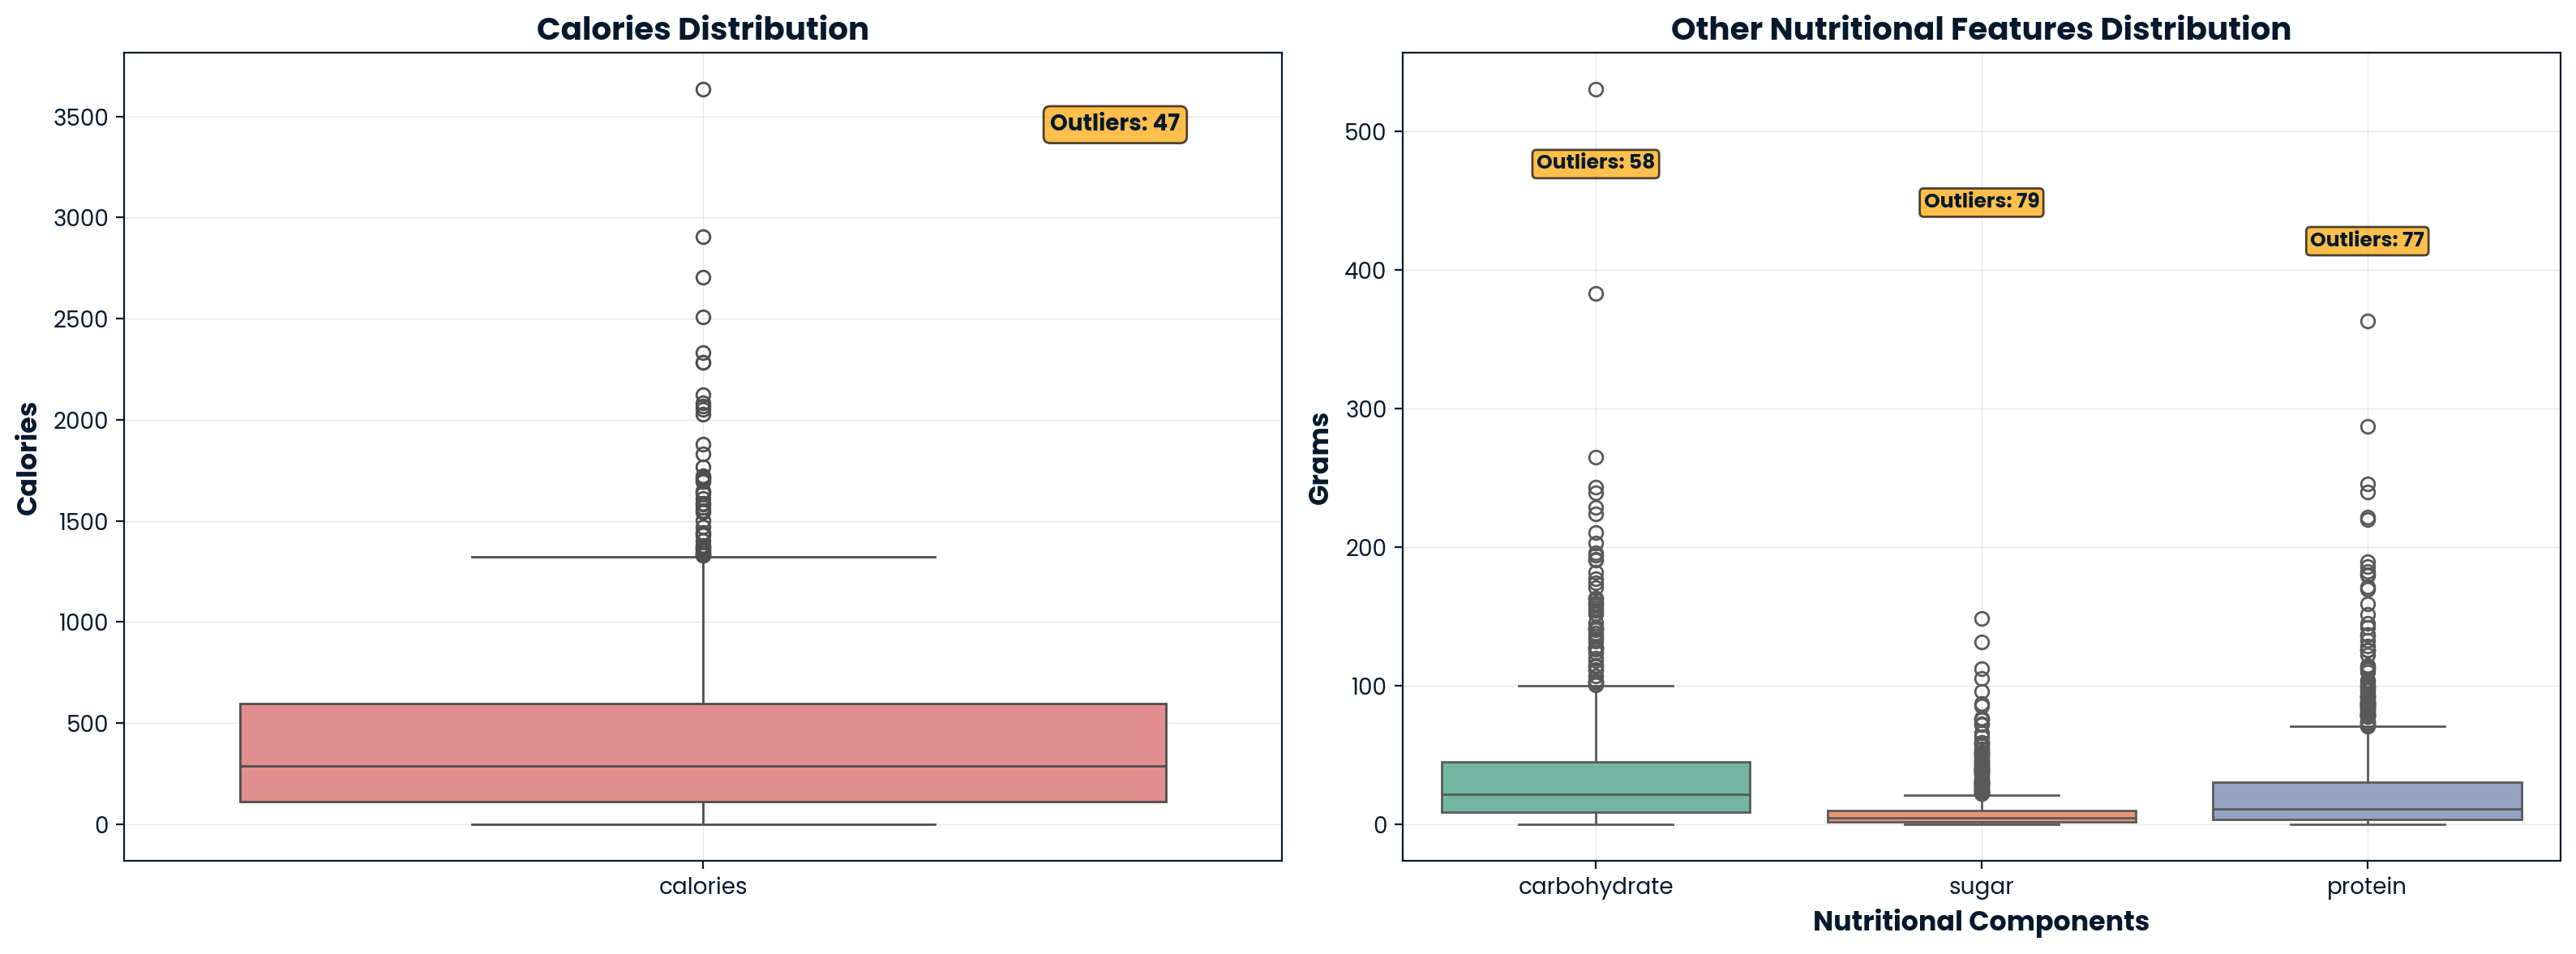

In [21]:
# Create subplots: separate plot for calories and combined for other features
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Calories 
sns.boxplot(data=df[['calories']], ax=ax1, color='lightcoral')
ax1.set_title('Calories Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('', fontsize=12)
ax1.set_ylabel('Calories', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

# Annotate outlier count 
outlier_count_cal = outlier_summary['calories']

ax1.text(0.3, ax1.get_ylim()[1]*0.9, f'Outliers: {outlier_count_cal}', 
         fontweight='bold', bbox=dict(boxstyle='round,pad=0.3', facecolor='orange', alpha=0.7))

# Plot 2: Other nutritional features
other_features = [col for col in numeric_features if col != 'calories']
sns.boxplot(data=df[other_features], ax=ax2, palette='Set2')
ax2.set_title('Other Nutritional Features Distribution', fontsize=14, fontweight='bold')
ax2.set_xlabel('Nutritional Components', fontsize=12, fontweight='bold')
ax2.set_ylabel('Grams', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

# Annotate outlier count 
for i, feature in enumerate(other_features):
    outlier_count = outlier_summary[feature]
    
    # Outlier count annotation
    y_pos = ax2.get_ylim()[1] * (0.85 - i*0.05)  # Stagger the outlier annotations
    ax2.text(i, y_pos, f'Outliers: {outlier_count}', 
             ha='center', fontweight='bold', fontsize=9,
             bbox=dict(boxstyle='round,pad=0.2', facecolor='orange', alpha=0.7))

plt.tight_layout()
plt.show()

In [22]:
outlier_details = {}

for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    low_outliers = df[df[col] < lower].shape[0]
    high_outliers = df[df[col] > upper].shape[0]
    
    outlier_details[col] = {
        'low_outliers': low_outliers,
        'high_outliers': high_outliers
    }

outlier_details

{'calories': {'low_outliers': 0, 'high_outliers': 47},
 'carbohydrate': {'low_outliers': 0, 'high_outliers': 58},
 'sugar': {'low_outliers': 0, 'high_outliers': 79},
 'protein': {'low_outliers': 0, 'high_outliers': 77}}

### Outlier Visualization and Analysis

We visualized nutritional features using boxplots, which highlight the interquartile range (IQR), whiskers, and outliers.  
The plots show that **all detected outliers occur above the upper whisker**, indicating unusually high values rather than unusually low ones.  

To confirm this, we counted outliers below and above the IQR thresholds:  
- Calories: 47 high outliers, 0 low  
- Carbohydrate: 58 high outliers, 0 low  
- Sugar: 79 high outliers, 0 low  
- Protein: 77 high outliers, 0 low  

This confirms that the extreme recipes are all **valid but exceptionally rich recipes** (e.g., desserts with very high sugar, meat dishes with very high protein), rather than data entry errors. 

We therefore decided to **retain these records** and plan to apply transformations (such as logarithmic scaling) to reduce their influence during modeling without discarding important information.

In [23]:
df.describe()

,recipe,calories,carbohydrate,sugar,protein,servings,high_traffic
count,895.000000,895.000000,895.000000,895.000000,895.000000,895.000000,895.000000
mean,473.652514,435.939196,35.069676,9.046547,24.149296,3.458101,0.597765
std,272.763283,453.020997,43.949032,14.679176,36.369739,1.735979,0.490623
min,2.000000,0.140000,0.030000,0.010000,0.000000,1.000000,0.000000
25%,237.500000,110.430000,8.375000,1.690000,3.195000,2.000000,0.000000
50%,475.000000,288.550000,21.480000,4.550000,10.800000,4.000000,1.000000
75%,708.500000,597.650000,44.965000,9.800000,30.200000,4.000000,1.000000
max,947.000000,3633.160000,530.420000,148.750000,363.360000,6.000000,1.000000


The `.describe()` summary shows that the `protein` column has a minimum value of **0**.  
Since most recipes are expected to contain at least some protein, this is a **questionable value** and requires further investigation.

In [24]:
df[df['protein'] == 0]

,recipe,calories,carbohydrate,sugar,protein,category,servings,high_traffic
468,469,27.11,22.63,4.93,0.0,Beverages,1,0
812,813,550.71,11.53,0.35,0.0,Potato,2,1


We identified 2 rows where `protein = 0`:

| Index | Recipe ID | Calories | Carbohydrate | Sugar | Protein | Category   | Servings | High Traffic |
|-------|-----------|----------|--------------|-------|---------|------------|----------|--------------|
| 468   | 469       | 27.11    | 22.63        | 4.93  | 0       | Beverages  | 1        | 0            |
| 812   | 813       | 550.71   | 11.53        | 0.35  | 0       | Potato     | 2        | 1            |

**Interpretation:**
- **Recipe 469 (Beverage):** Very low calories, high carbohydrates, and no protein — consistent with a drink recipe (e.g., juice), making `protein = 0` plausible.  
- **Recipe 813 (Potato dish):** High calories, moderate carbohydrates, and no sugar, but `protein = 0` is questionable since potatoes usually contain some protein. This may represent a data entry error.  

- I have done some research and a lot of reliable references such as **National Institutes of Health, Healthline and  Examine.com** confirm that potatoes contain protein.

In [25]:
# Look at potato recipes sorted by protein
df[df['category'] == 'Potato'][['recipe','calories','carbohydrate','sugar','protein']].sort_values('protein').head(10)

,recipe,calories,carbohydrate,sugar,protein
812,813,550.71,11.53,0.35,0.00
910,911,74.73,2.99,1.18,0.22
800,801,1054.40,25.96,0.43,0.24
244,245,160.43,11.37,0.60,0.24
243,244,653.90,111.80,5.04,0.36
870,871,1471.33,86.51,0.79,0.58
653,654,732.96,8.31,0.91,0.68
644,645,26.16,32.73,1.32,0.73
1,2,35.48,38.56,0.66,0.92
180,181,44.77,11.91,7.93,1.07


### Protein Levels in Potato Dishes

We investigated whether `protein = 0` in the `Potato` category was a data entry error.  
To do this, we examined the 10 potato recipes with the lowest protein values. These ranged from **0 g to 1.07 g**, indicating that very low protein levels are not unusual within this category.  

**Decision:**  
Since other potato recipes also have protein values close to 0, we consider `protein = 0` to be a **valid extreme value** rather than an error. The row is therefore **retained without modification** , as we do not have sufficient evidence to treat it as incorrect.  
Ideally, this point would be clarified with the data source, but since we cannot contact them, we retain the value as observed.

# 2️⃣ EDA

In [26]:
from scipy import stats
from scipy.stats import boxcox, shapiro, jarque_bera, chi2_contingency, mannwhitneyu
from sklearn.preprocessing import PowerTransformer

from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib import colormaps


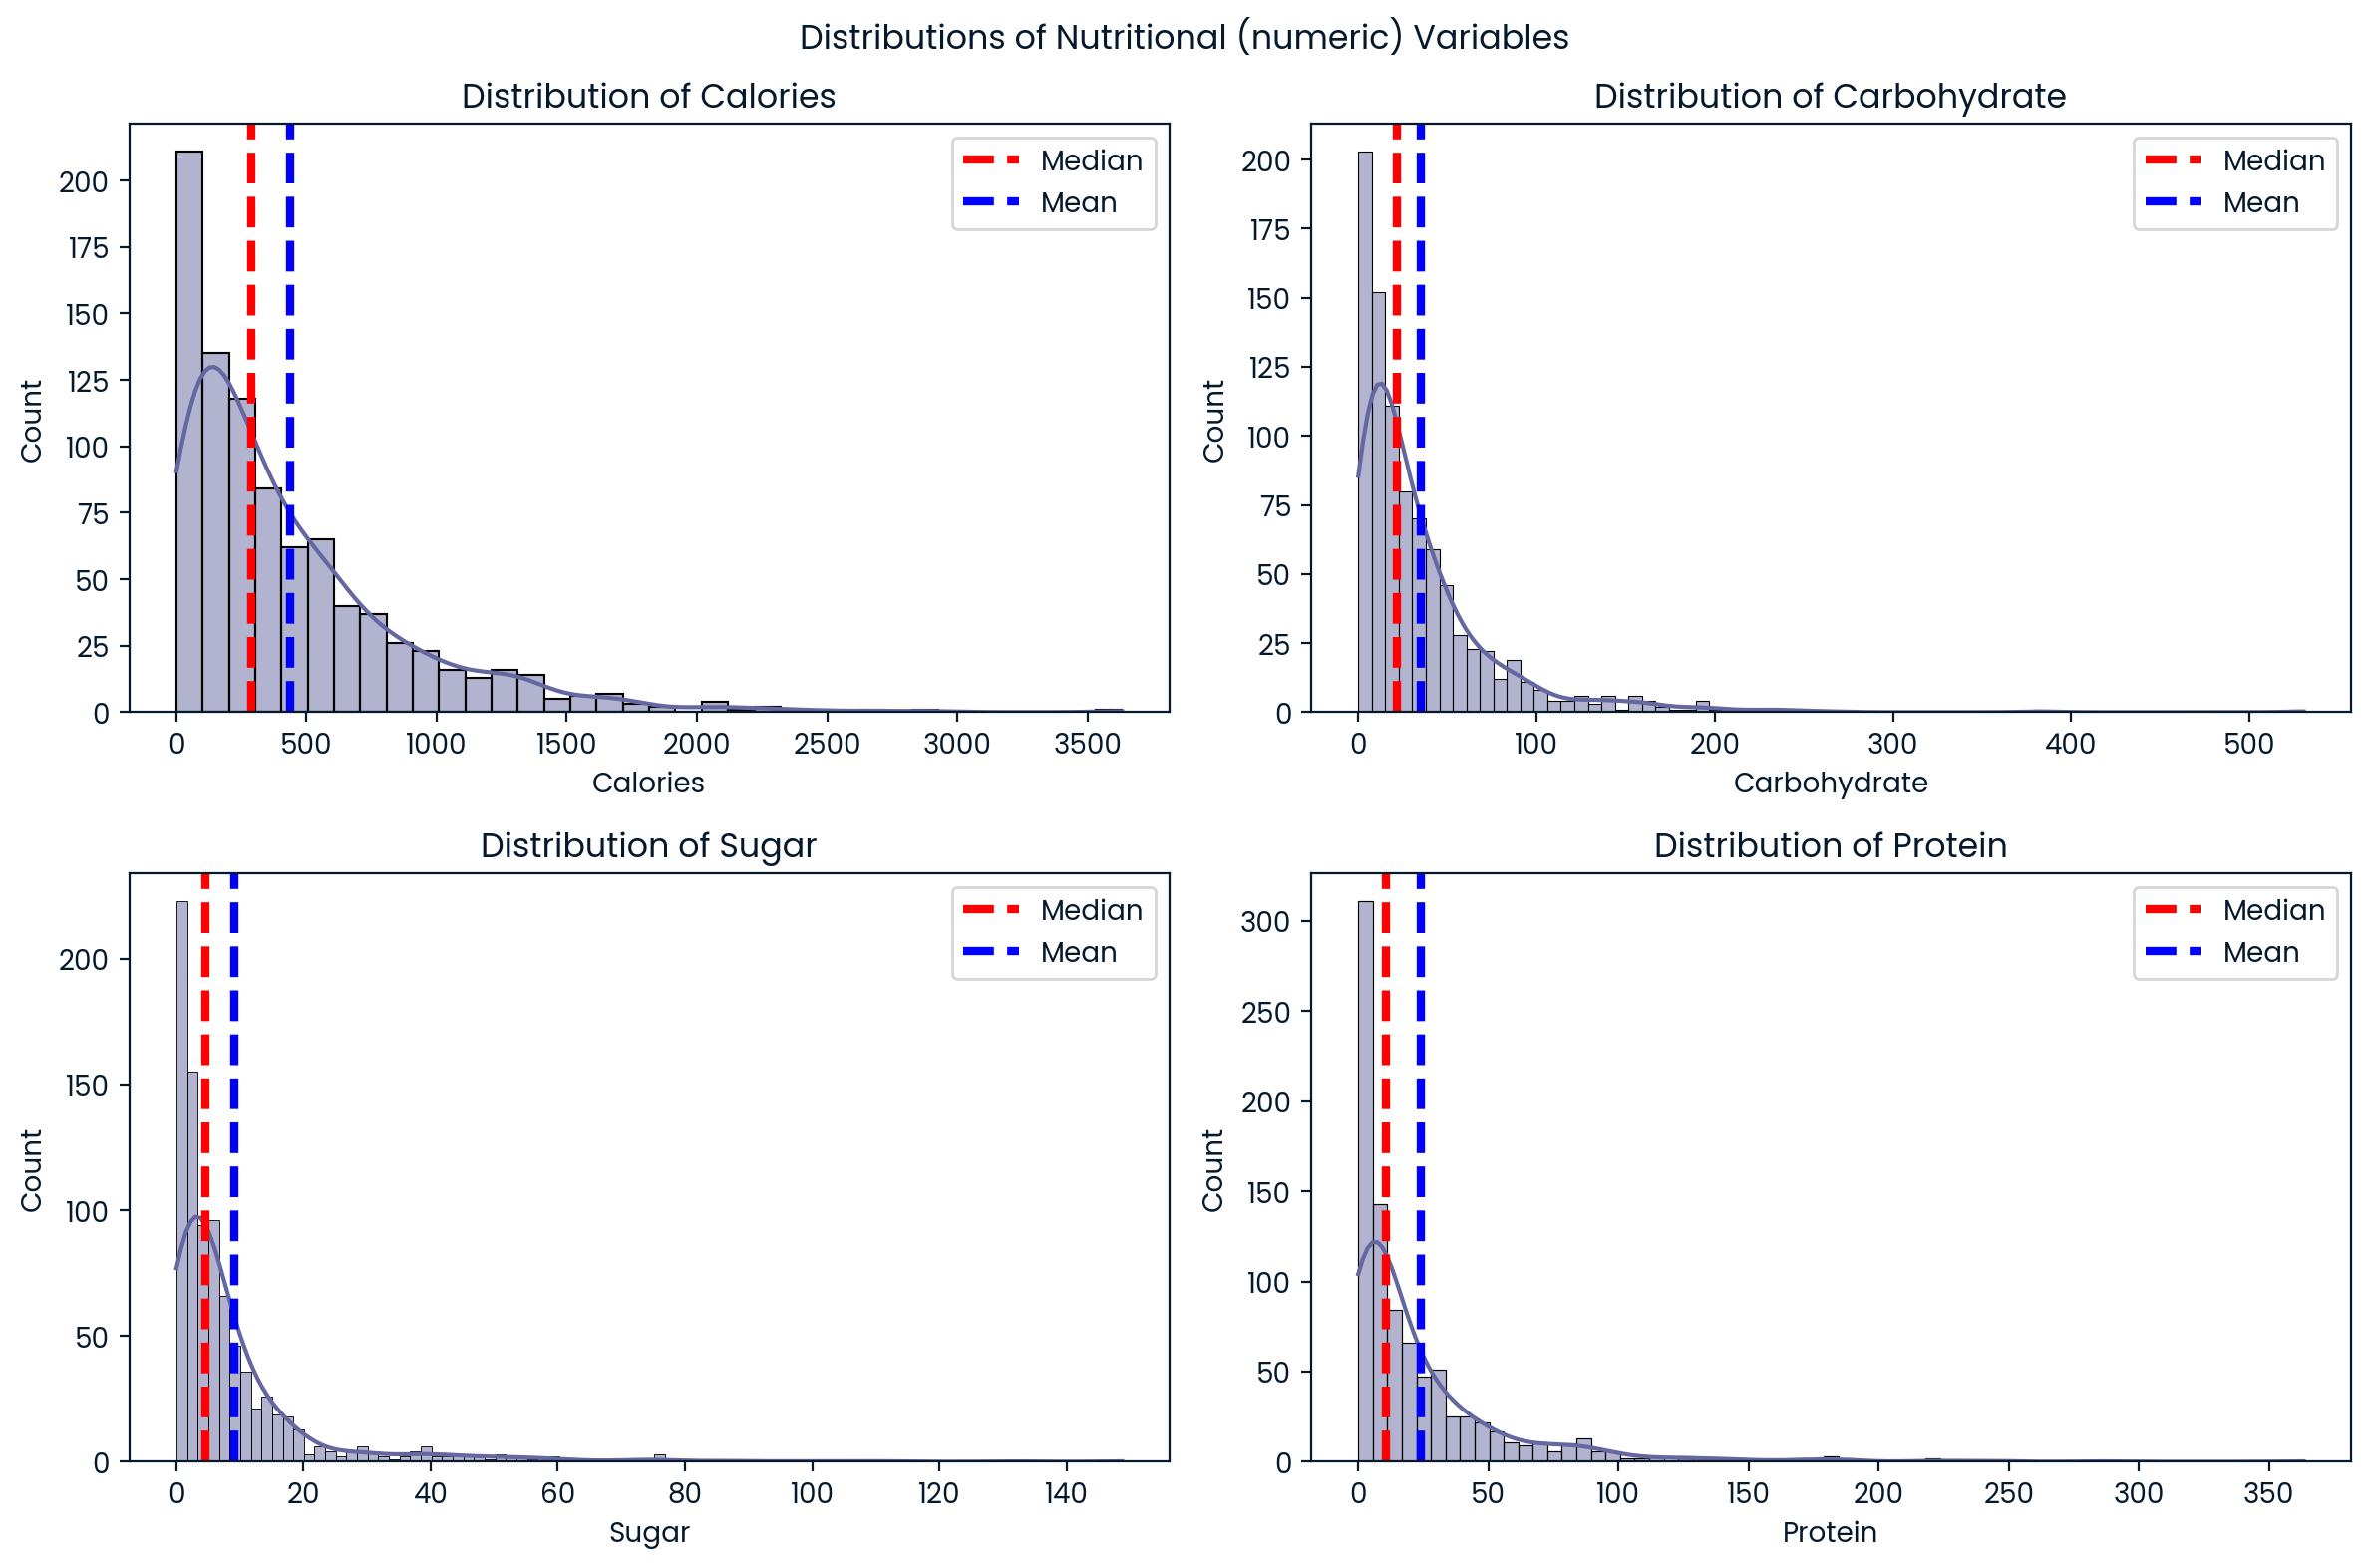

In [27]:
# Numeric distributions

numeric_cols = ['calories','carbohydrate','sugar','protein']

plt.figure(figsize=(12, 8))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    
    # Create histogram with KDE
    sns.histplot(df[col].dropna(), kde=True)
    
    # Calculate mean and median
    col_mean, col_median = df[col].mean(), df[col].median()
    
    # Vertical lines for mean and median
    plt.axvline(col_median, color='red', linestyle='dashed', linewidth=3, label='Median')
    plt.axvline(col_mean, color='blue', linestyle='dashed', linewidth=3, label='Mean')
    
    # Add labels
    plt.title(f'Distribution of {col.title()}')
    plt.xlabel(col.title())
    plt.ylabel('Count')
    plt.legend()

plt.suptitle("Distributions of Nutritional (numeric) Variables")
plt.tight_layout()
plt.show()

# Distribution Analysis of Nutritional Variables

## Key Observations
The histogram analysis reveals that all four nutritional variables (calories, carbohydrate, sugar, protein) exhibit **strong right-skewed distributions** with similar characteristics with **High Frequency at Low Values** and  **Exponential Decay Pattern**.


## Implications for Transformation
Given these strong right-skewed distributions, **we need transformation** before conducting statistical analyses or modeling. The current distributions violate normality assumptions required for many statistical tests and may cause issues in machine learning models.

In [28]:
# Transformation functions
def log_transform(x):
    return np.log1p(x)  # log(x+1) handles zeros of `protein`

def sqrt_transform(x):
    return np.sqrt(x)

def boxcox_transform(x):
    x_shifted = x + 1e-8 if (x == 0).any() else x
    transformed, lam = boxcox(x_shifted)
    return transformed, lam

def yeojohnson_transform(x):
    pt = PowerTransformer(method='yeo-johnson', standardize=False)
    transformed = pt.fit_transform(x.values.reshape(-1,1)).flatten()
    return transformed, pt.lambdas_[0]

In [29]:
def analyze_transformations(data, variable_name):
    transformations = {"Original": data}
    
    # Apply transformations
    transformations["Log"] = log_transform(data)
    transformations["Square Root"] = sqrt_transform(data)
        
    # Box-Cox transformation
    bc_data, bc_lam = boxcox_transform(data)
    transformations[f"Box-Cox (λ={bc_lam:.3f})"] = bc_data
    
    # Yeo-Johnson transformation
    yj_data, yj_lam = yeojohnson_transform(data)
    transformations[f"Yeo-Johnson (λ={yj_lam:.3f})"] = yj_data


    # Plot histograms + Q-Q plots
    n = len(transformations)
    fig, axes = plt.subplots(2, n, figsize=(4*n, 8))
    for i, (name, t_data) in enumerate(transformations.items()):
        # Histogram with KDE
        sns.histplot(t_data, bins=30, kde=True, color="steelblue", ax=axes[0,i])
        axes[0,i].set_title(f"{name}")
        # Q-Q plot
        stats.probplot(t_data, dist="norm", plot=axes[1,i])
        axes[1,i].set_title(f"Q-Q Plot - {name}")
    plt.suptitle(f"Transformations for {variable_name}", fontsize=14)
    plt.tight_layout()
    plt.show()

    # Collect stats 
    results = []
    for name, t_data in transformations.items():
        jb_stat, jb_p = jarque_bera(t_data)
        sh_stat, sh_p = shapiro(t_data)
        results.append({
            "name": name,
            "skewness": stats.skew(t_data),
            "kurtosis": stats.kurtosis(t_data),
            "shapiro_p": sh_p,
            "jb_p": jb_p
        })
    results_df = pd.DataFrame(results)

    # Report
    print(f"\n=== Analysis of {variable_name.upper()} ===")
    best_skew = results_df.iloc[results_df['skewness'].abs().idxmin()]
    print(f"Best by Skewness: {best_skew['name']} (skew={best_skew['skewness']:.4f})")
    best_kurt = results_df.iloc[results_df['kurtosis'].abs().idxmin()]
    print(f"Best by Kurtosis: {best_kurt['name']} (kurtosis={best_kurt['kurtosis']:.4f})")
    best_shapiro = results_df.iloc[results_df['shapiro_p'].idxmax()]
    print(f"Best by Shapiro-Wilk: {best_shapiro['name']} (p={best_shapiro['shapiro_p']:.4f})")
    best_jb = results_df.iloc[results_df['jb_p'].idxmax()]
    print(f"Best by Jarque-Bera: {best_jb['name']} (p={best_jb['jb_p']:.4f})")

    return results_df

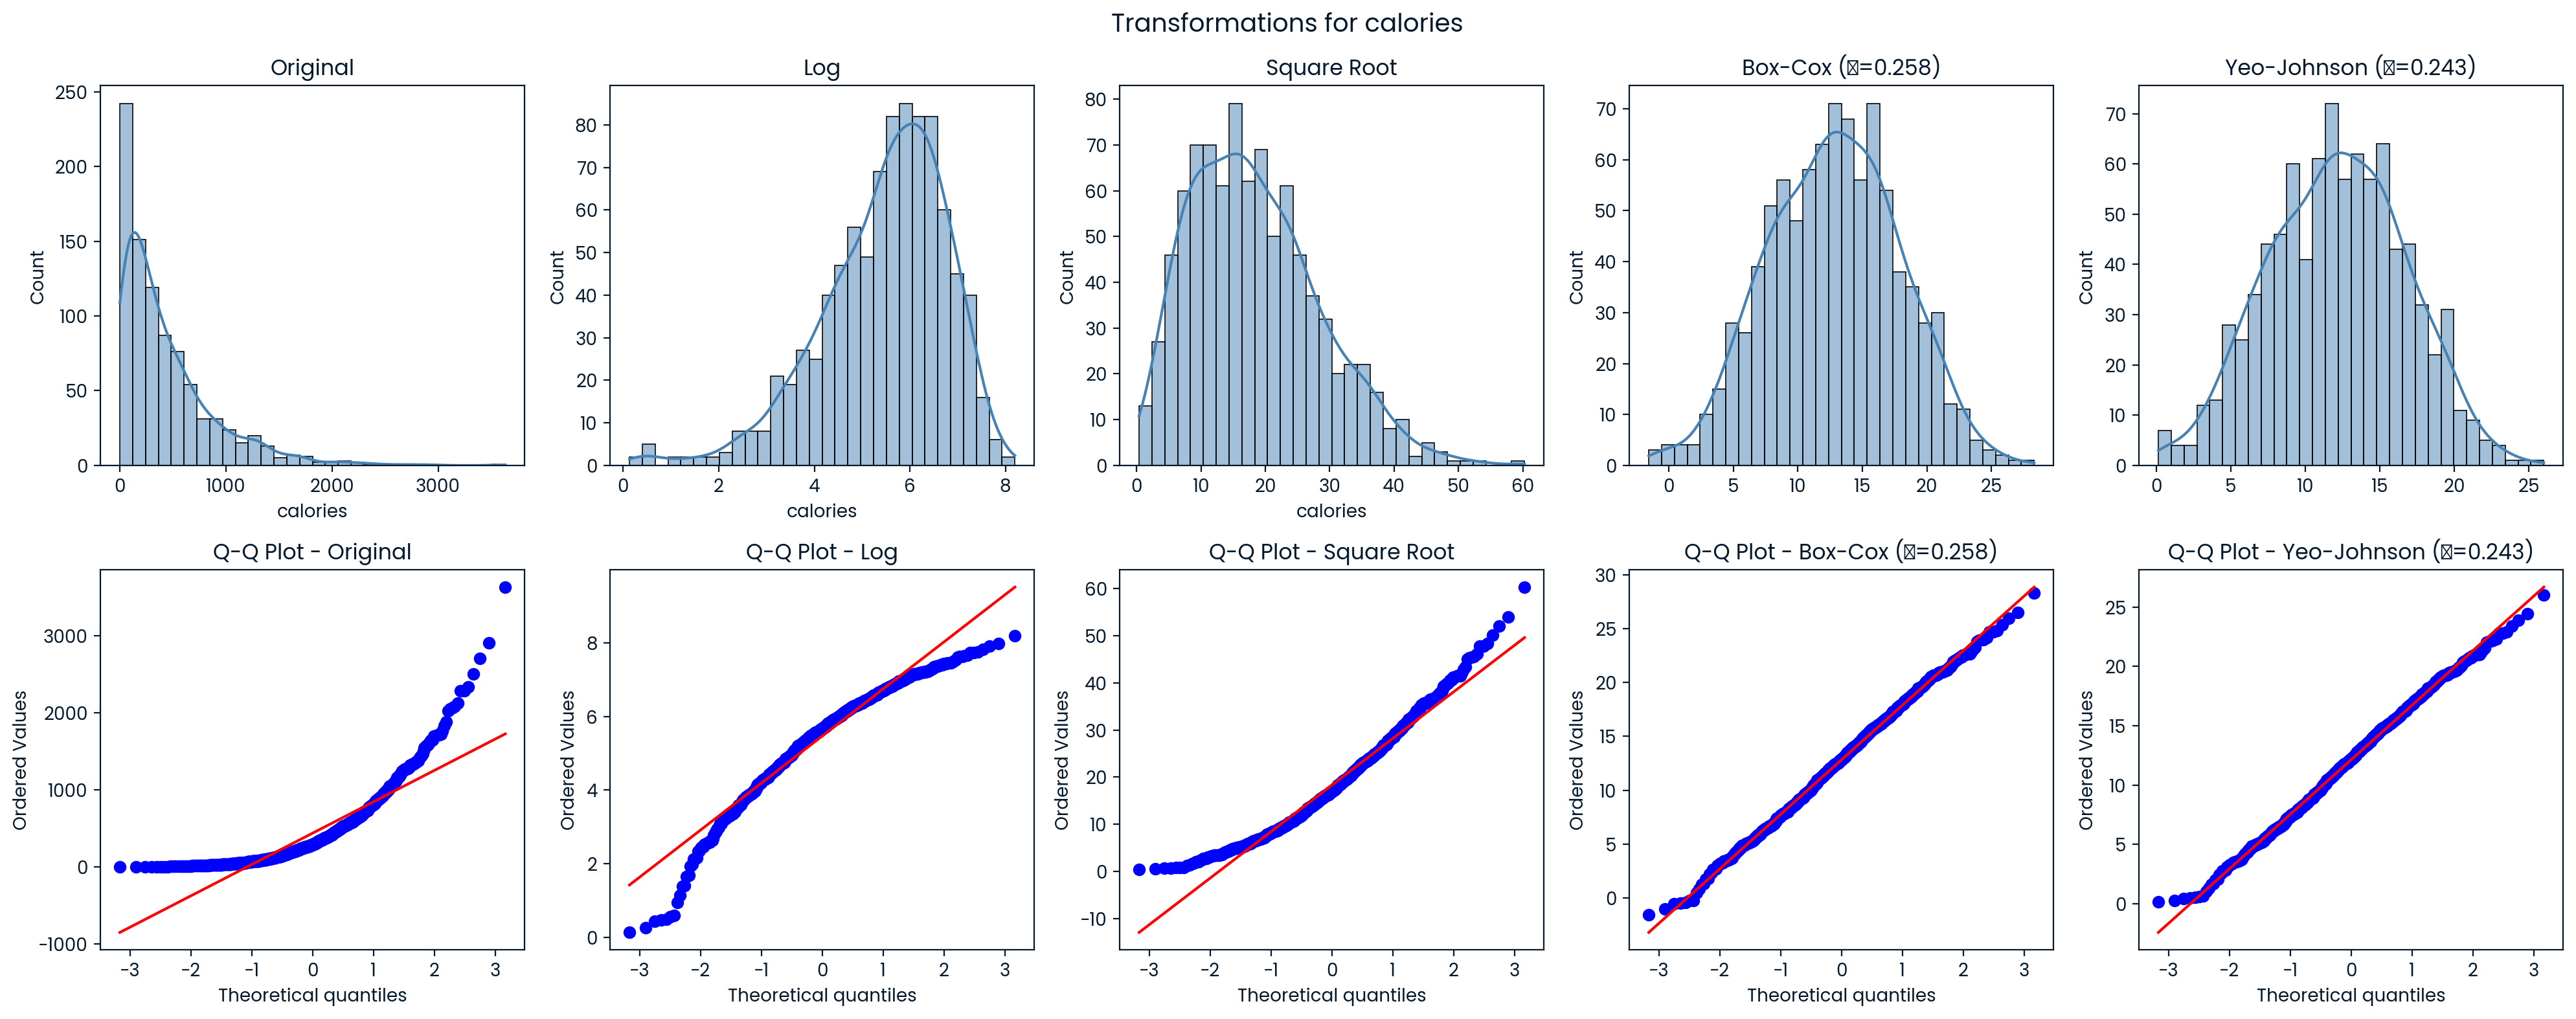


=== Analysis of CALORIES ===
Best by Skewness: Box-Cox (λ=0.258) (skew=-0.0402)
Best by Kurtosis: Square Root (kurtosis=0.2235)
Best by Shapiro-Wilk: Box-Cox (λ=0.258) (p=0.2978)
Best by Jarque-Bera: Box-Cox (λ=0.258) (p=0.1569)


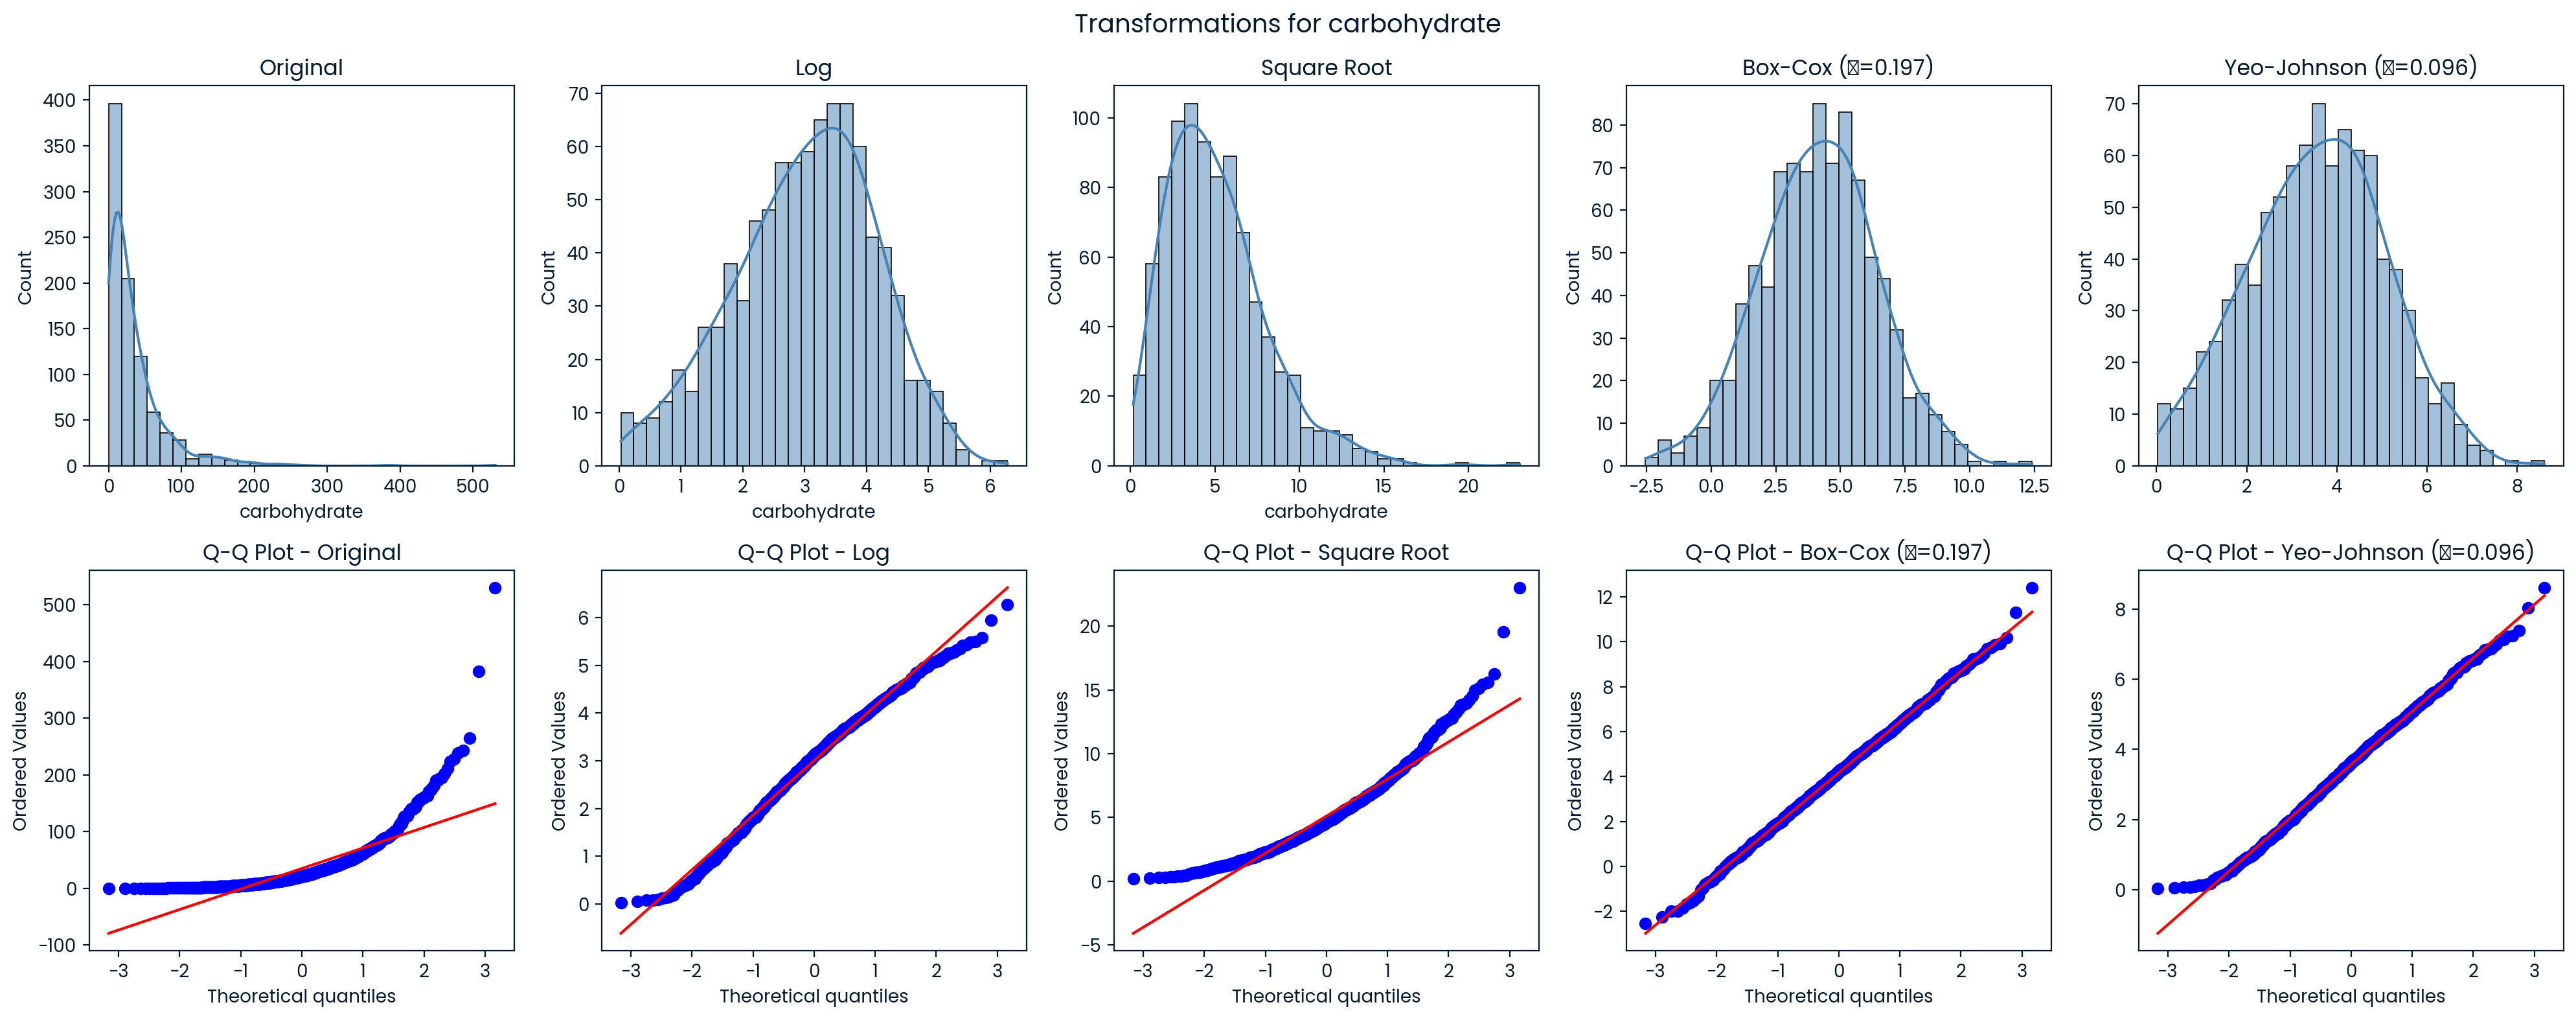


=== Analysis of CARBOHYDRATE ===
Best by Skewness: Box-Cox (λ=0.197) (skew=0.0009)
Best by Kurtosis: Box-Cox (λ=0.197) (kurtosis=0.0694)
Best by Shapiro-Wilk: Box-Cox (λ=0.197) (p=0.9577)
Best by Jarque-Bera: Box-Cox (λ=0.197) (p=0.9140)


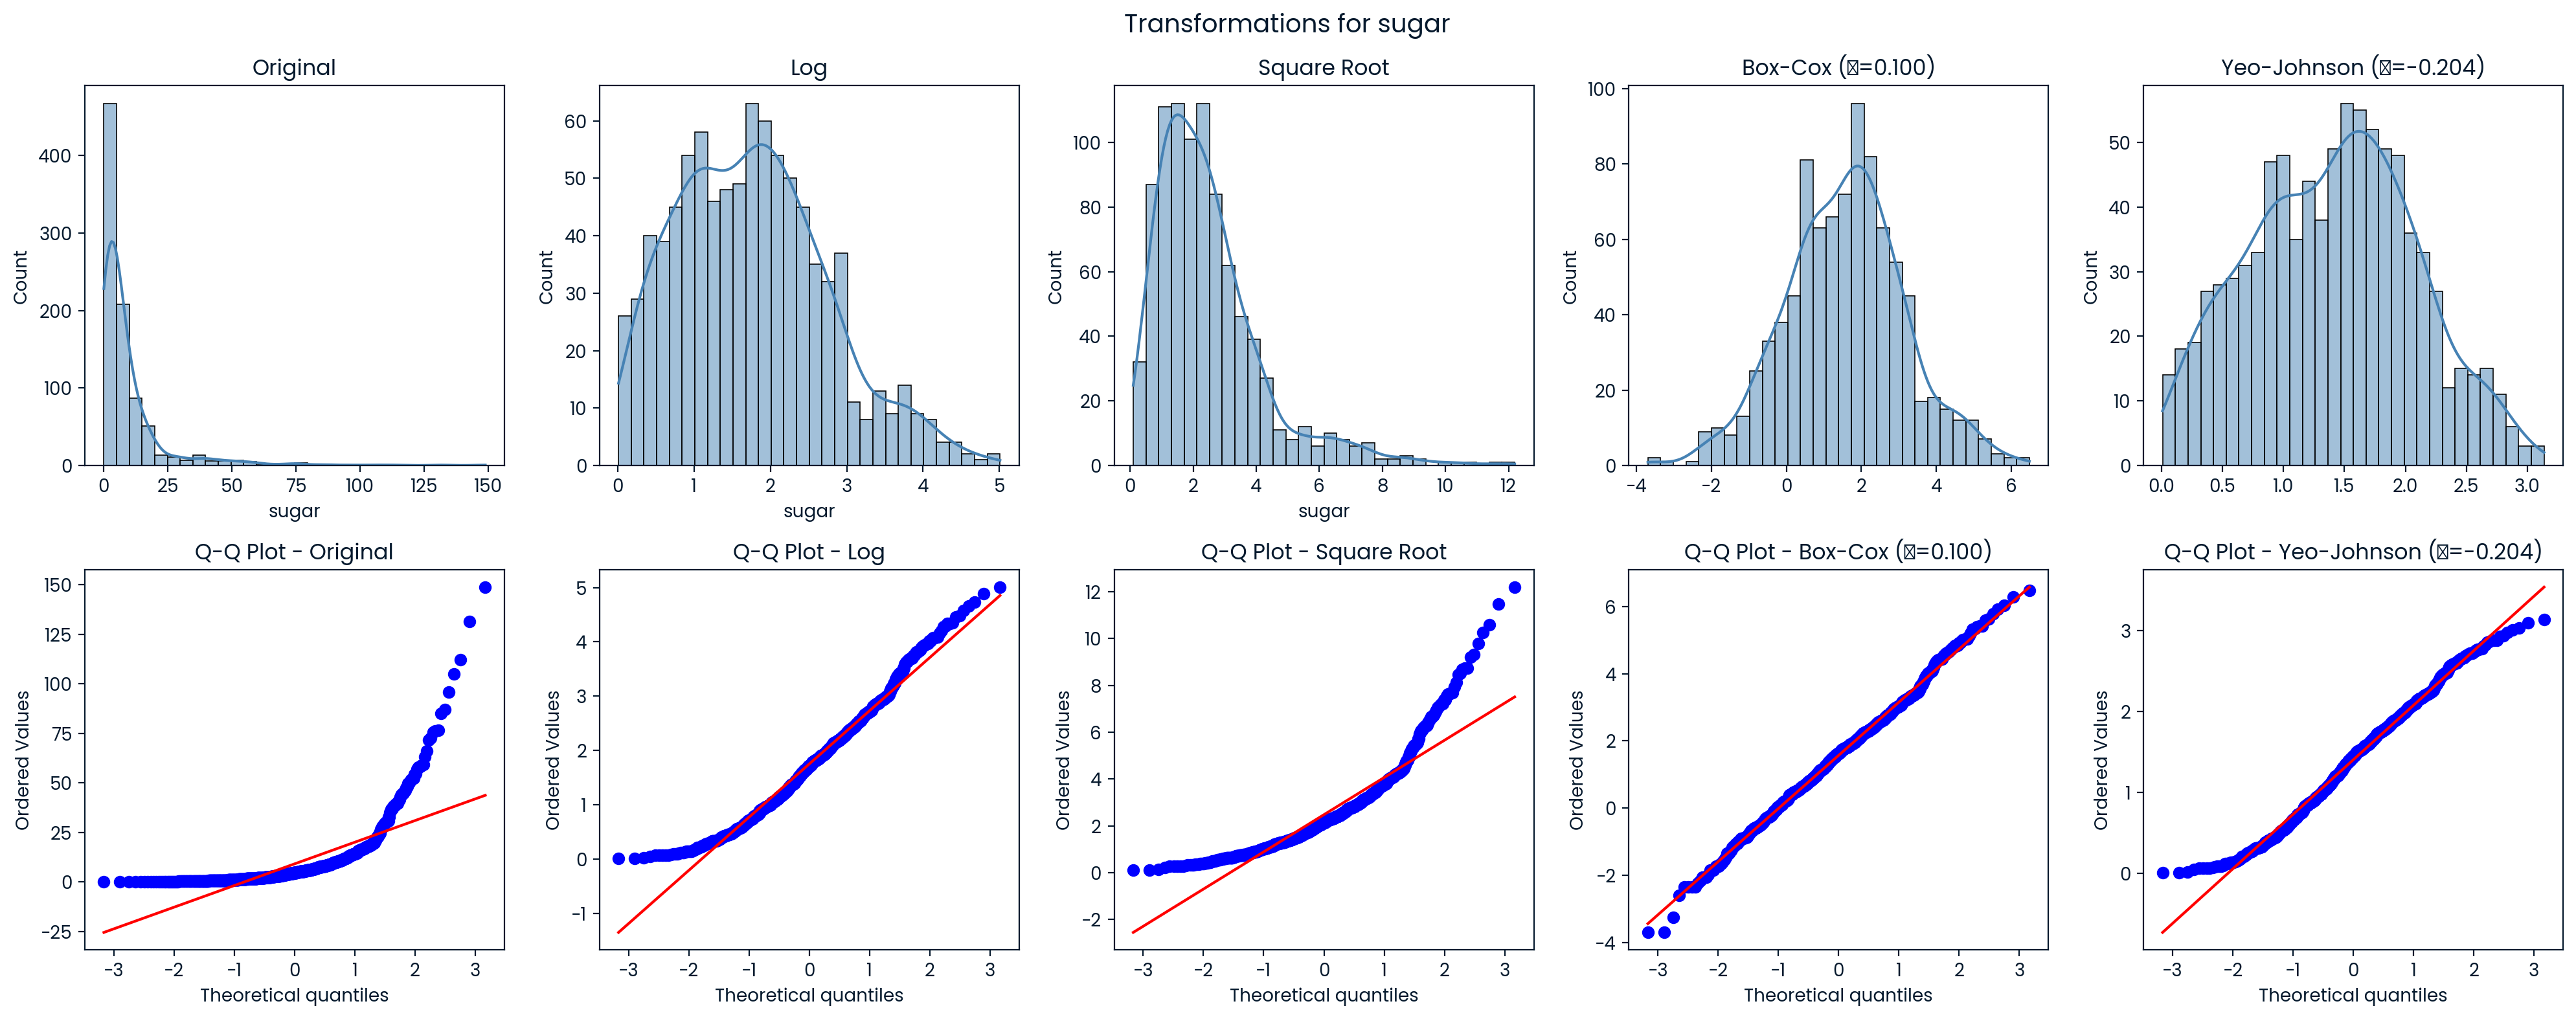


=== Analysis of SUGAR ===
Best by Skewness: Box-Cox (λ=0.100) (skew=0.0114)
Best by Kurtosis: Log (kurtosis=-0.1073)
Best by Shapiro-Wilk: Box-Cox (λ=0.100) (p=0.1293)
Best by Jarque-Bera: Box-Cox (λ=0.100) (p=0.3419)


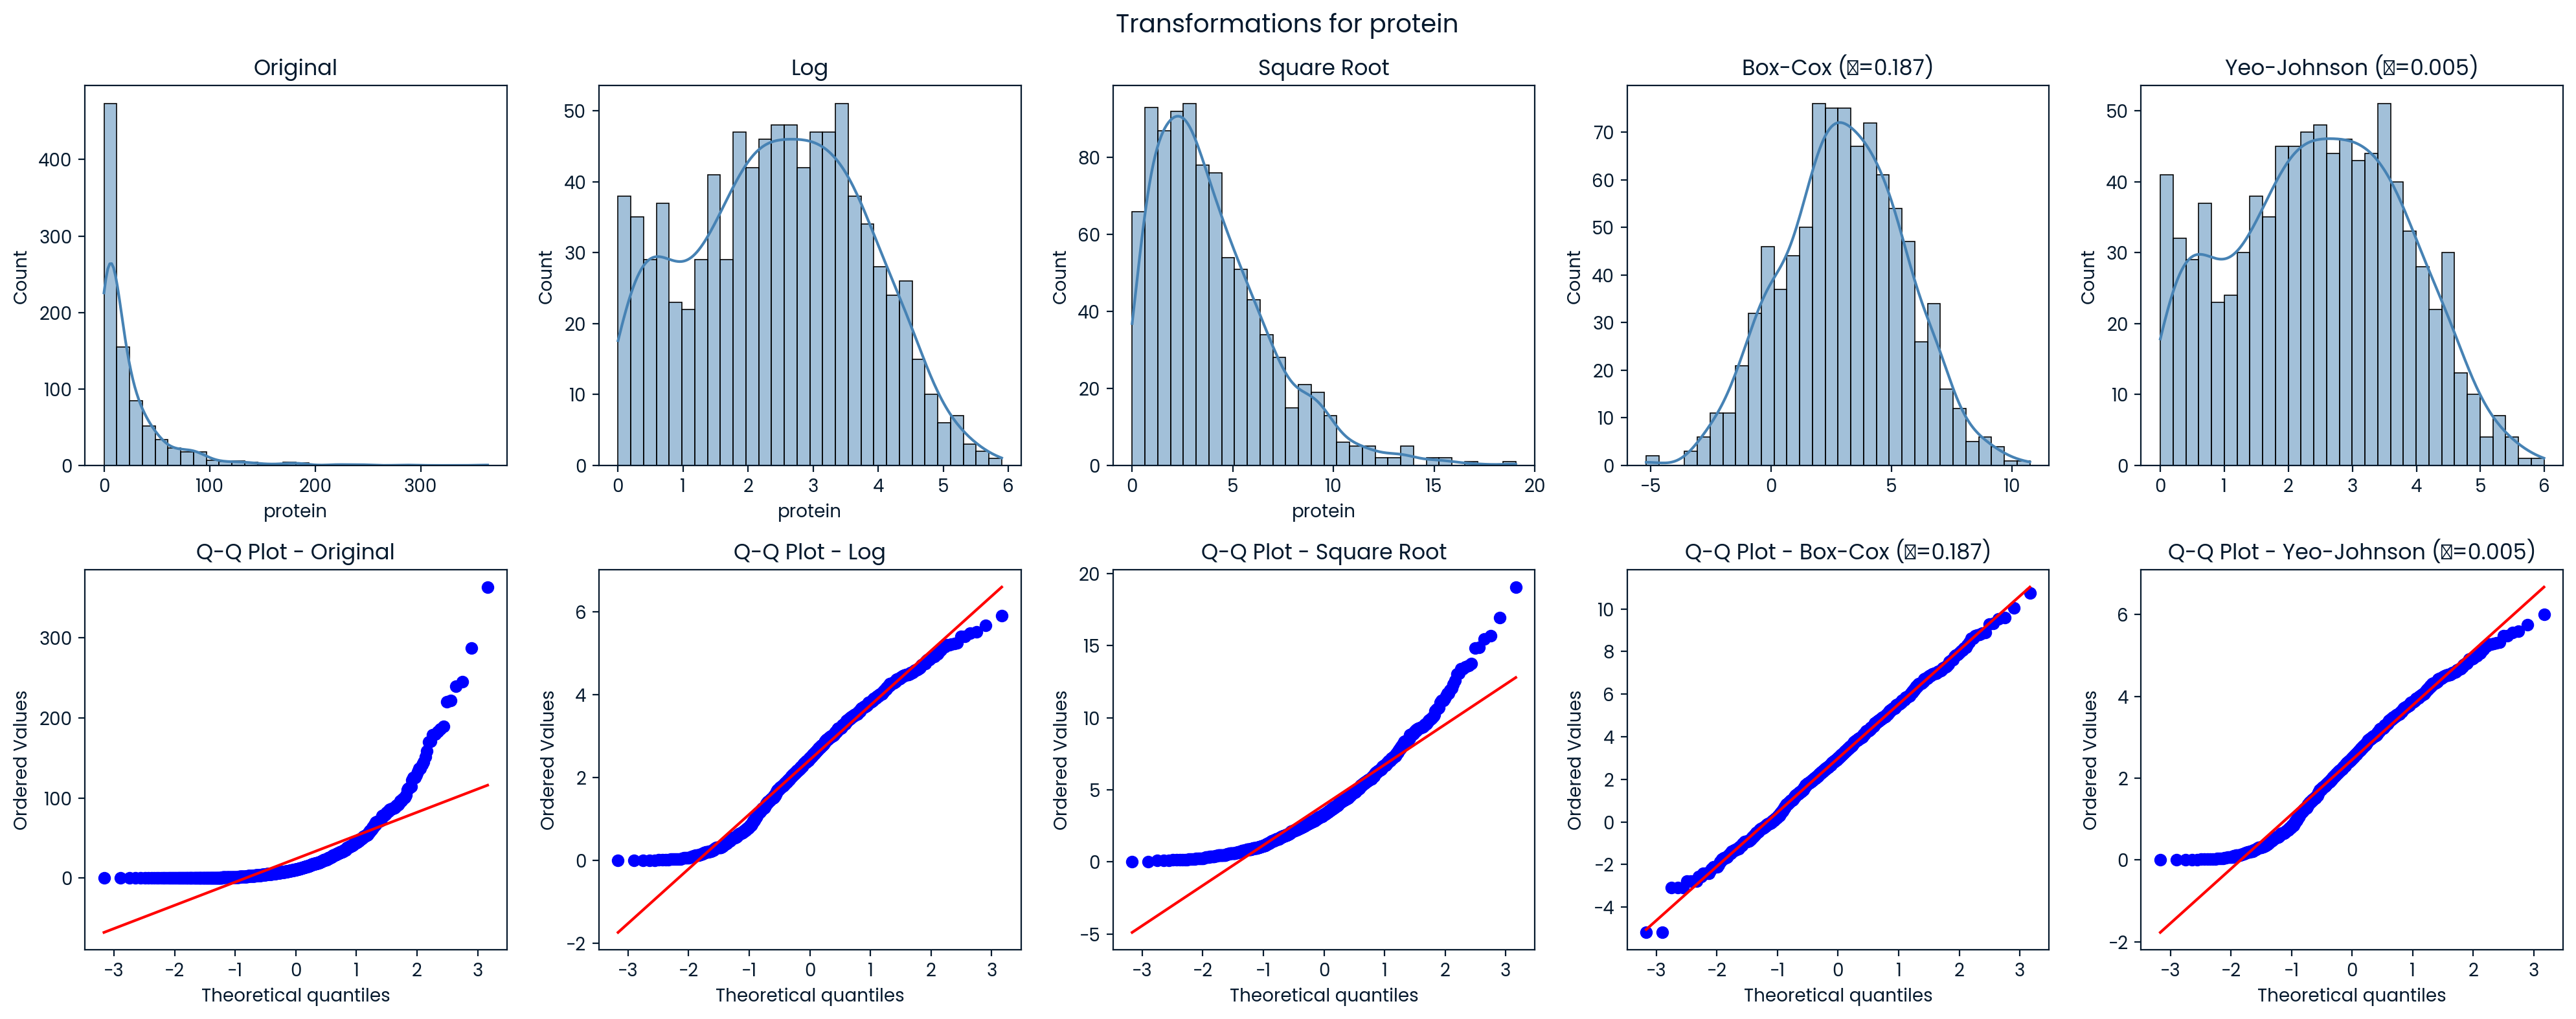


=== Analysis of PROTEIN ===
Best by Skewness: Yeo-Johnson (λ=0.005) (skew=-0.0019)
Best by Kurtosis: Box-Cox (λ=0.187) (kurtosis=-0.2004)
Best by Shapiro-Wilk: Box-Cox (λ=0.187) (p=0.5896)
Best by Jarque-Bera: Box-Cox (λ=0.187) (p=0.4338)


In [30]:
numeric_cols = ['calories','carbohydrate','sugar','protein']
for col in numeric_cols:
    analyze_transformations(df[col].dropna(), col)

## Decision on Data Transformation

From our transformation analysis, we found that **Box-Cox transformation** consistently provided the best normalization across most nutritional variables (calories, carbohydrate, sugar, protein).  

### Findings Recap:
- **Calories**: Best overall = Box-Cox (λ=0.258)  
- **Carbohydrate**: Best overall = Box-Cox (λ=0.197)  
- **Sugar**: Best overall = Box-Cox (λ=0.100)  
- **Protein**: Best overall = Box-Cox (λ=0.187), with Yeo-Johnson also close  

Transformations will be applied **after EDA, during data preprocessing for modeling** to ensures models see normalized features while we still retain meaningful interpretations in EDA.

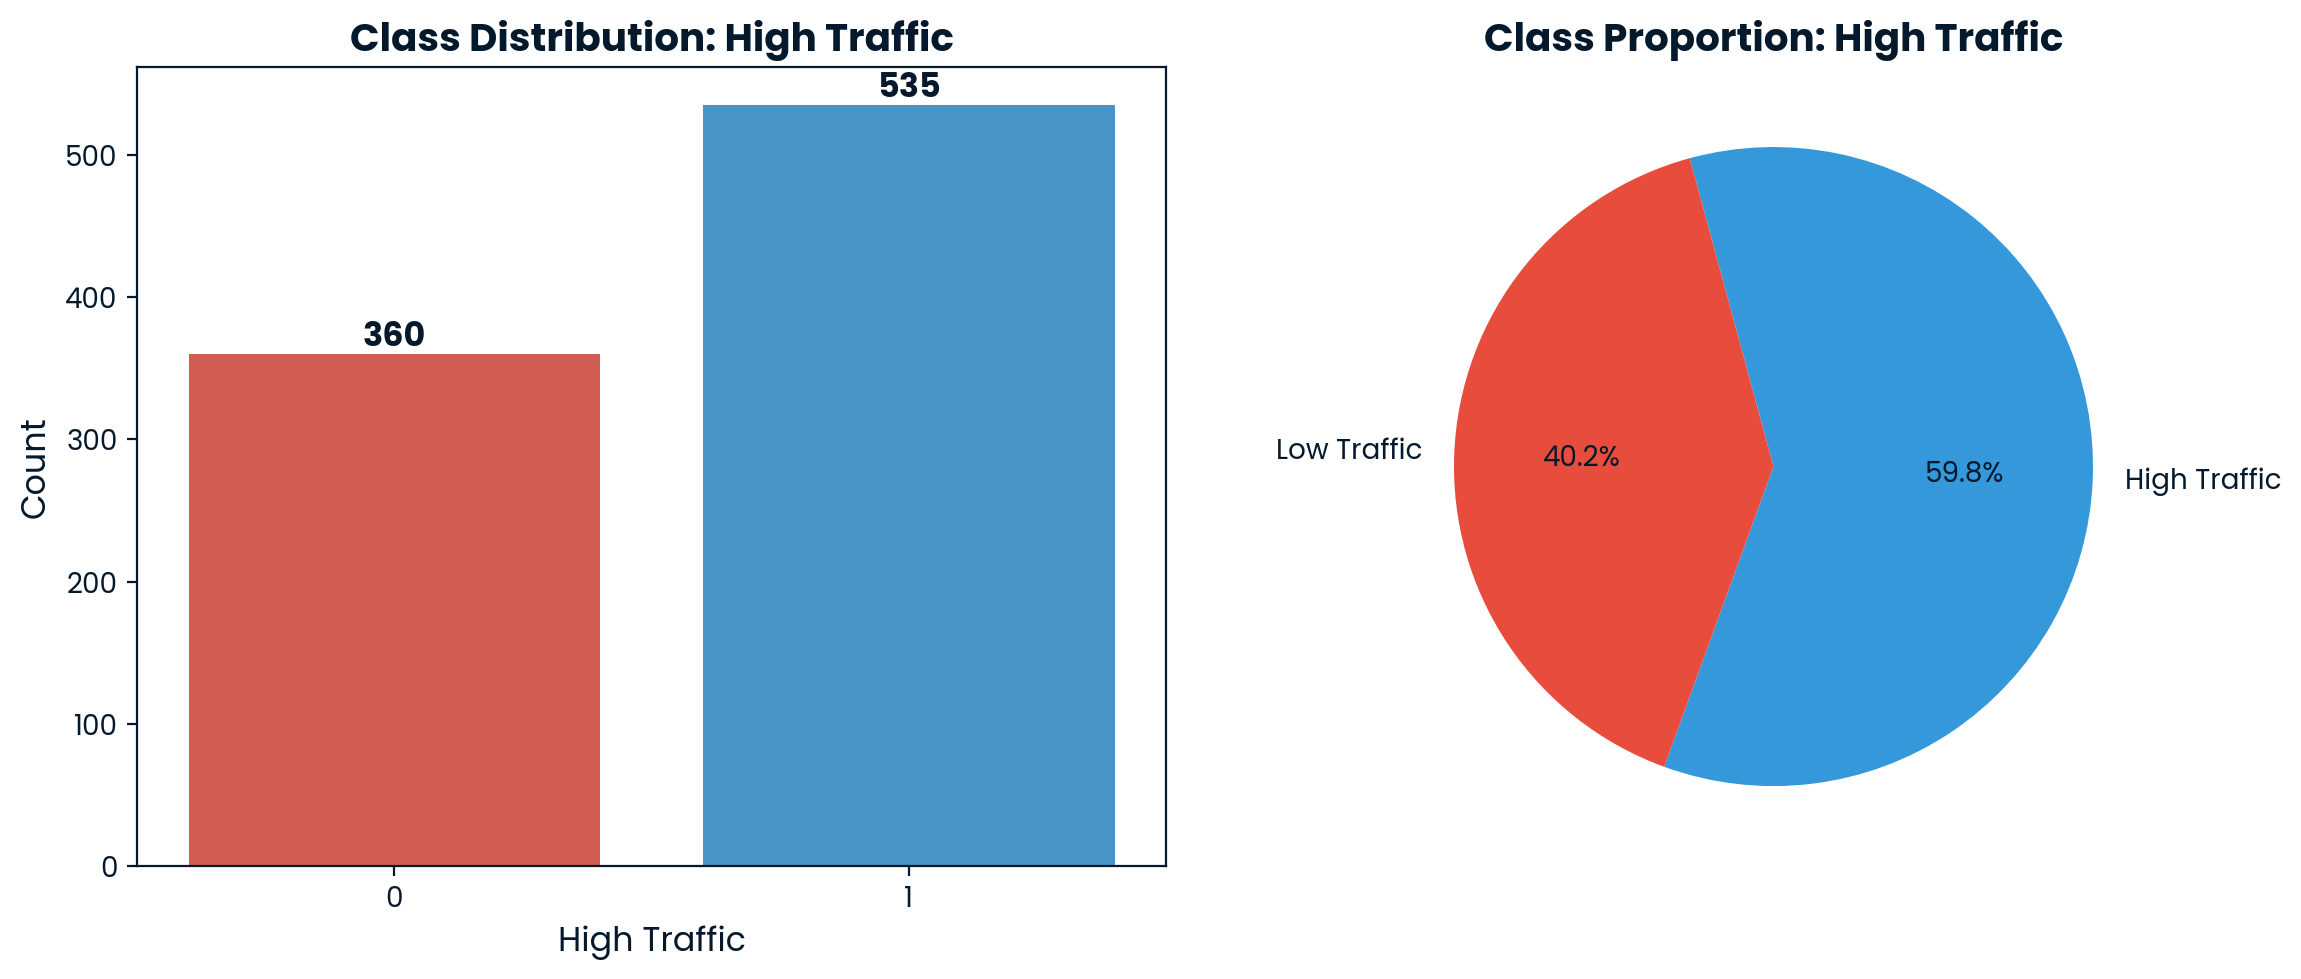

Class Imbalance Analysis:
Total samples: 895
High traffic samples: 535 (59.8%)
Low traffic samples: 360 (40.2%)
Imbalance ratio: 1.49:1


In [31]:
# Check class imbalance in target variable
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Count plot for class distribution
sns.countplot(data=df, x='high_traffic', ax=ax1, palette=['#e74c3c','#3498db'])
ax1.set_title('Class Distribution: High Traffic', fontsize=14, fontweight='bold')
ax1.set_xlabel('High Traffic', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)

# Add count labels
for container in ax1.containers:
    ax1.bar_label(container, fmt='%d', fontsize=12, fontweight='bold')

# Pie chart for class proportions
class_counts = df['high_traffic'].value_counts()
ax2.pie(class_counts.values, labels=['High Traffic', 'Low Traffic'], 
        autopct='%1.1f%%', startangle=250, colors=['#3498db','#e74c3c'])
ax2.set_title('Class Proportion: High Traffic', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print class imbalance metrics
print("Class Imbalance Analysis:")
print("=" * 30)
total_samples = len(df)
high_traffic_count = df['high_traffic'].sum()
low_traffic_count = total_samples - high_traffic_count

print(f"Total samples: {total_samples}")
print(f"High traffic samples: {high_traffic_count} ({high_traffic_count/total_samples*100:.1f}%)")
print(f"Low traffic samples: {low_traffic_count} ({low_traffic_count/total_samples*100:.1f}%)")

# Calculate imbalance ratio
imbalance_ratio = max(class_counts) / min(class_counts)
print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")

## Class Imbalance Analysis

We examined the distribution of our target variable `high_traffic`:

- **Total samples:** 895  
- **High traffic samples:** 535 (59.8%)  
- **Low traffic samples:** 360 (40.2%)  
- **Imbalance ratio:** ~1.49 : 1 (High : Low)  

### Interpretation
The dataset shows a **moderate class imbalance**, with high-traffic recipes being more common.  
This imbalance is not extreme, but it may still influence model training and make the model slightly biased towards predicting the majority class (high traffic).  

### Taken Notes
- We will monitor model performance using metrics that are sensitive to class imbalance (e.g., **precision, recall, F1-score**) rather than accuracy alone.  
- If needed, techniques such as **class weighting** can be considered during modeling to ensure balanced learning.  
- During train/validation splits, we will use **stratification** to preserve the ratio of high vs. low traffic recipes:  
  - **train_test_split** will be stratified on `y`.  
  - **StratifiedKFold** will be implemented instead of plain KFold during cross-validation, ensuring each fold maintains the class distribution.  


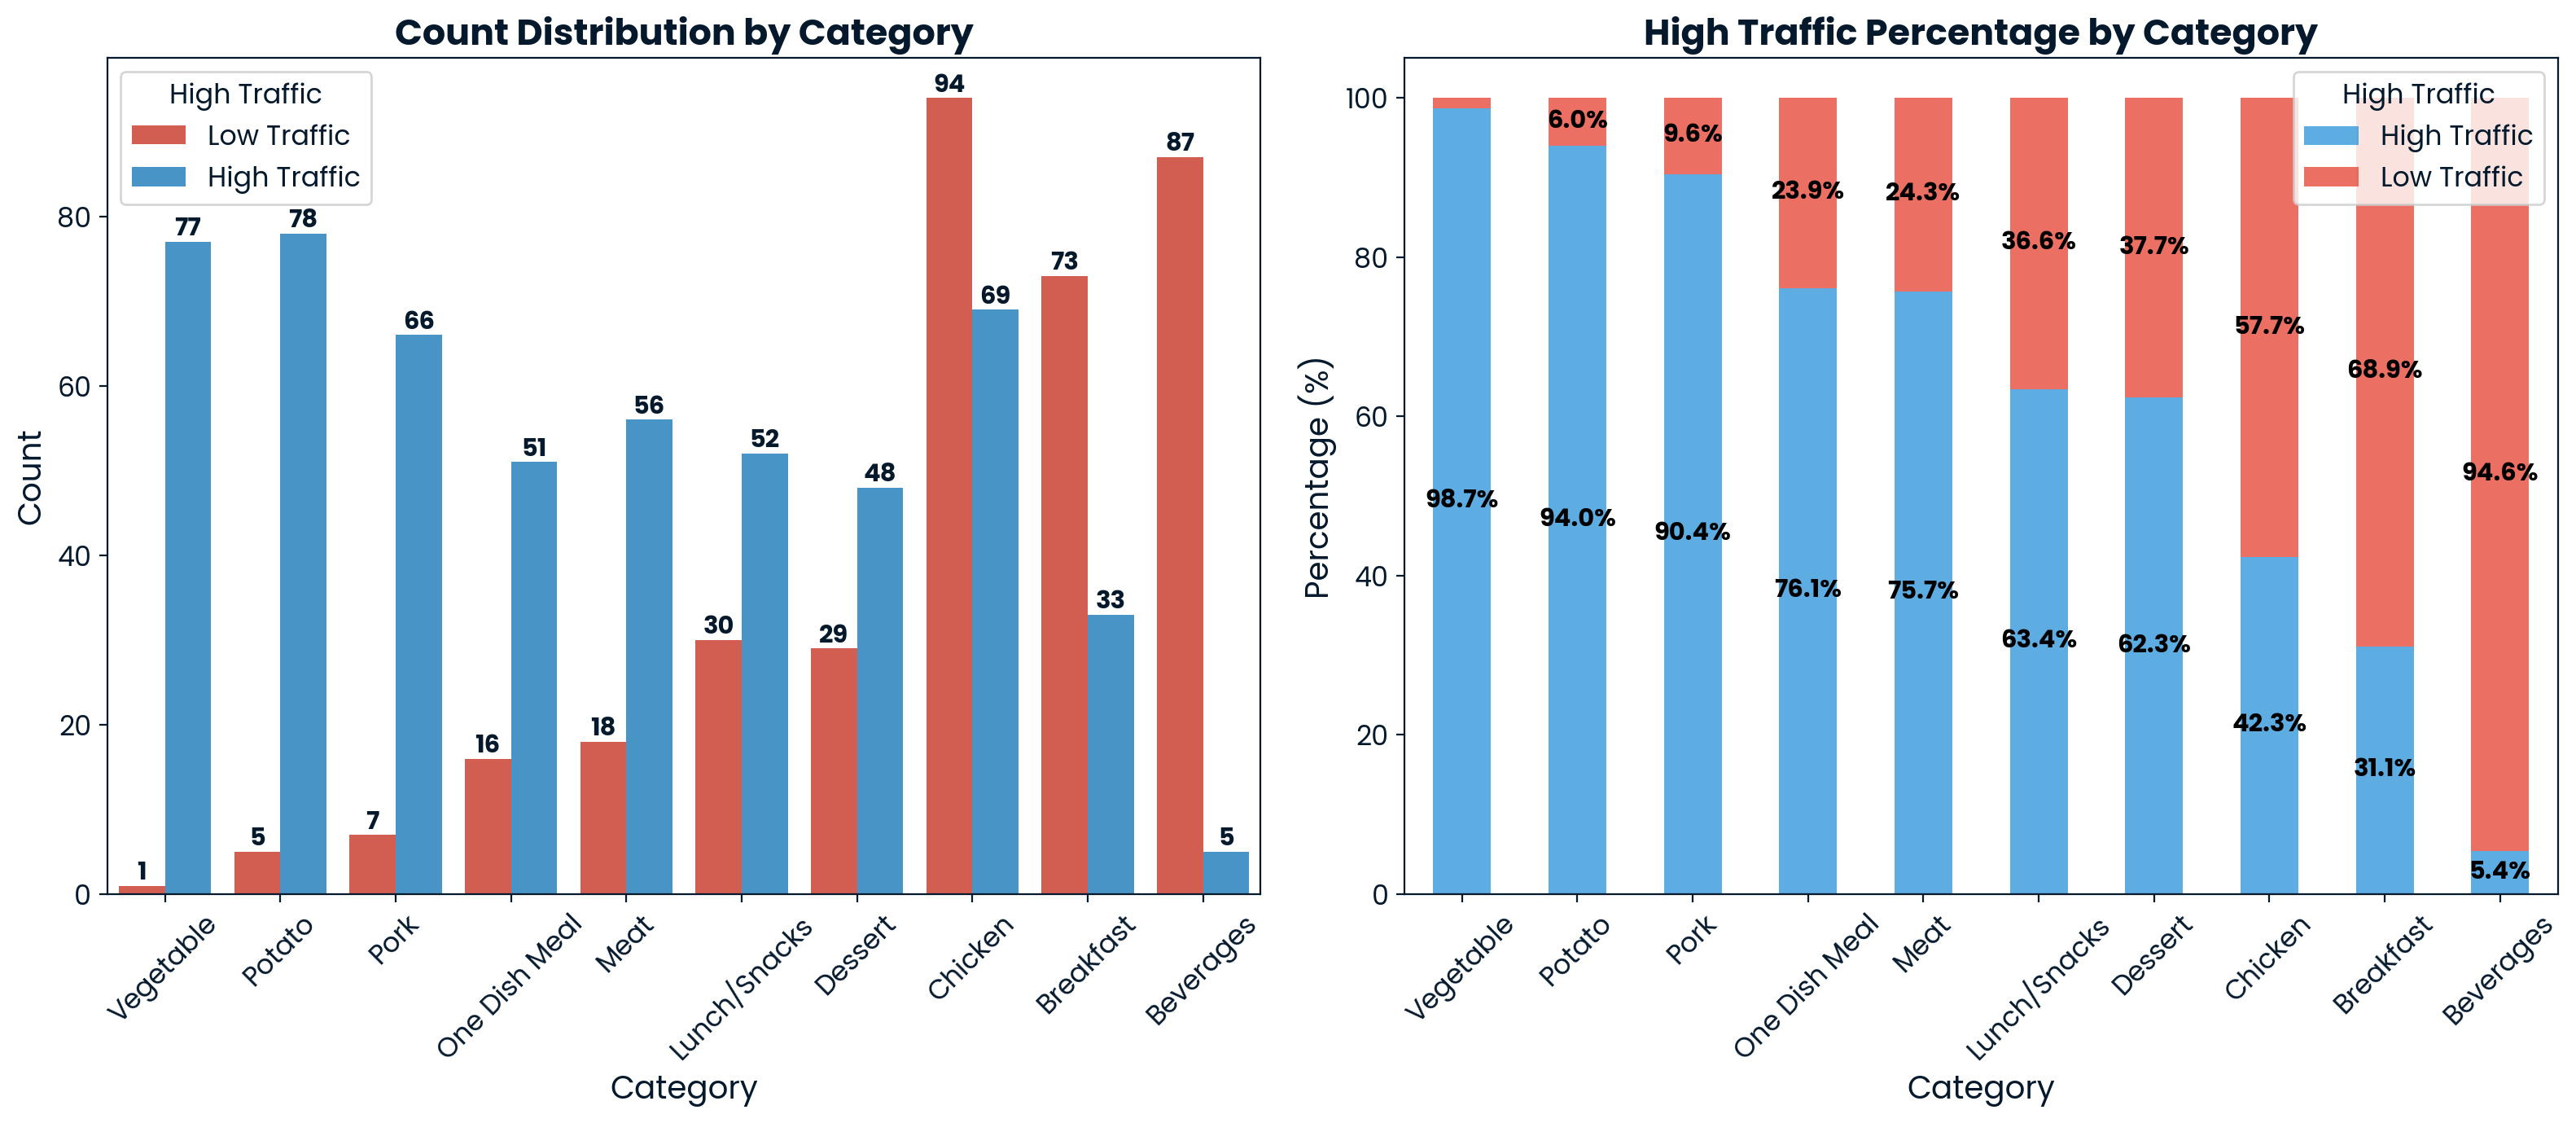

In [32]:
# Category vs high traffic analysis 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Calculate high traffic percentage for sorting
category_pct = df.groupby(['category', 'high_traffic']).size().unstack(fill_value=0)
category_pct_norm = category_pct.div(category_pct.sum(axis=1), axis=0) * 100

# Sort categories by high traffic percentage 
sorted_categories = category_pct_norm[1].sort_values(ascending=False).index.tolist()

colors = ['#e74c3c', '#3498db']  

# Count Plot
countplot = sns.countplot(data=df, x='category', hue='high_traffic', ax=ax1, 
                         order=sorted_categories, palette=colors)
ax1.set_title('Count Distribution by Category', fontsize=16, fontweight='bold')
ax1.set_xlabel('Category', fontsize=14)
ax1.set_ylabel('Count', fontsize=14)
ax1.tick_params(axis='x', rotation=45, labelsize=12)
ax1.tick_params(axis='y', labelsize=12)
ax1.legend(title='High Traffic', labels=['Low Traffic', 'High Traffic'], 
           title_fontsize=12, fontsize=12)

# Add count labels
for container in countplot.containers:
    countplot.bar_label(container, fmt='%d', fontsize=11, fontweight='bold')

# Percentage Distribution
category_pct_sorted = category_pct.reindex(sorted_categories)
category_pct_norm_sorted = category_pct_sorted.div(category_pct_sorted.sum(axis=1), axis=0) * 100

# Reorder columns so high traffic (1) is at bottom, low traffic (0) is on top
category_pct_norm_ordered = category_pct_norm_sorted[[1, 0]] 
colors_ordered = ['#3498db', '#e74c3c'] 
labels_ordered = ['High Traffic', 'Low Traffic']

category_pct_norm_ordered.plot(kind='bar', stacked=True, ax=ax2, 
                              color=colors_ordered, alpha=0.8)

ax2.set_title('High Traffic Percentage by Category', fontsize=16, fontweight='bold')
ax2.set_xlabel('Category', fontsize=14)
ax2.set_ylabel('Percentage (%)', fontsize=14)
ax2.tick_params(axis='x', rotation=45, labelsize=12)
ax2.tick_params(axis='y', labelsize=12)

ax2.legend(title='High Traffic', labels=labels_ordered, 
           title_fontsize=12, fontsize=12, 
           loc='upper right', bbox_to_anchor=(1.0, 1.0))

# Add percentage labels on bars
for i, category in enumerate(category_pct_norm_ordered.index):
    cumulative = 0
    for j, col in enumerate(category_pct_norm_ordered.columns):
        height = category_pct_norm_ordered.iloc[i, j]
        if height > 3:  # Only show label if bar is large enough
            ax2.text(i, cumulative + height/2, f'{height:.1f}%', 
                    ha='center', va='center', fontweight='bold', 
                    fontsize=11, color='black')
        cumulative += height

plt.tight_layout()
plt.show()

In [33]:
# Statistical test and insights
traffic_rate = df.groupby('category')['high_traffic'].agg(['count', 'sum', 'mean']).reset_index()
traffic_rate['high_traffic_rate'] = traffic_rate['mean'] * 100
traffic_rate = traffic_rate.sort_values('high_traffic_rate', ascending=True)

contingency_table = pd.crosstab(df['category'], df['high_traffic'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Statistical Analysis:")
print("=" * 30)
print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Significant association between category and high traffic")
else:
    print("No significant association")

print(f"\nOverall high traffic rate: {df['high_traffic'].mean()*100:.1f}%")
print(f"Best category: {traffic_rate.iloc[-1]['category']} ({traffic_rate.iloc[-1]['high_traffic_rate']:.1f}%)")
print(f"Worst category: {traffic_rate.iloc[0]['category']} ({traffic_rate.iloc[0]['high_traffic_rate']:.1f}%)")

Statistical Analysis:
Chi-square statistic: 303.7393
P-value: 0.0000
Significant association between category and high traffic

Overall high traffic rate: 59.8%
Best category: Vegetable (98.7%)
Worst category: Beverages (5.4%)


## Category vs High Traffic Analysis

We performed a Chi-square test to evaluate the relationship between **recipe category** and **traffic outcome**.

### Results
- **Chi-square statistic:** 303.74  
- **P-value:** < 0.0001  
- **Conclusion:** There is a **statistically significant association** between recipe category and whether a recipe generates high traffic.

### Insights
- **Overall high traffic rate:** 59.8%  
- **Best performing category:** **Vegetable** recipes, with a very high success rate (98.7%).  
- **Worst performing category:** **Beverages**, with a very low success rate (5.4%).  

### Interpretation
This suggests that **recipe category is a strong predictor** of traffic performance.  
Vegetable-based recipes are almost always popular, while Beverages are rarely successful.  
This insight will be valuable for both **feature selection** in modeling and **business recommendations** (e.g., prioritize Vegetable recipes on the homepage).

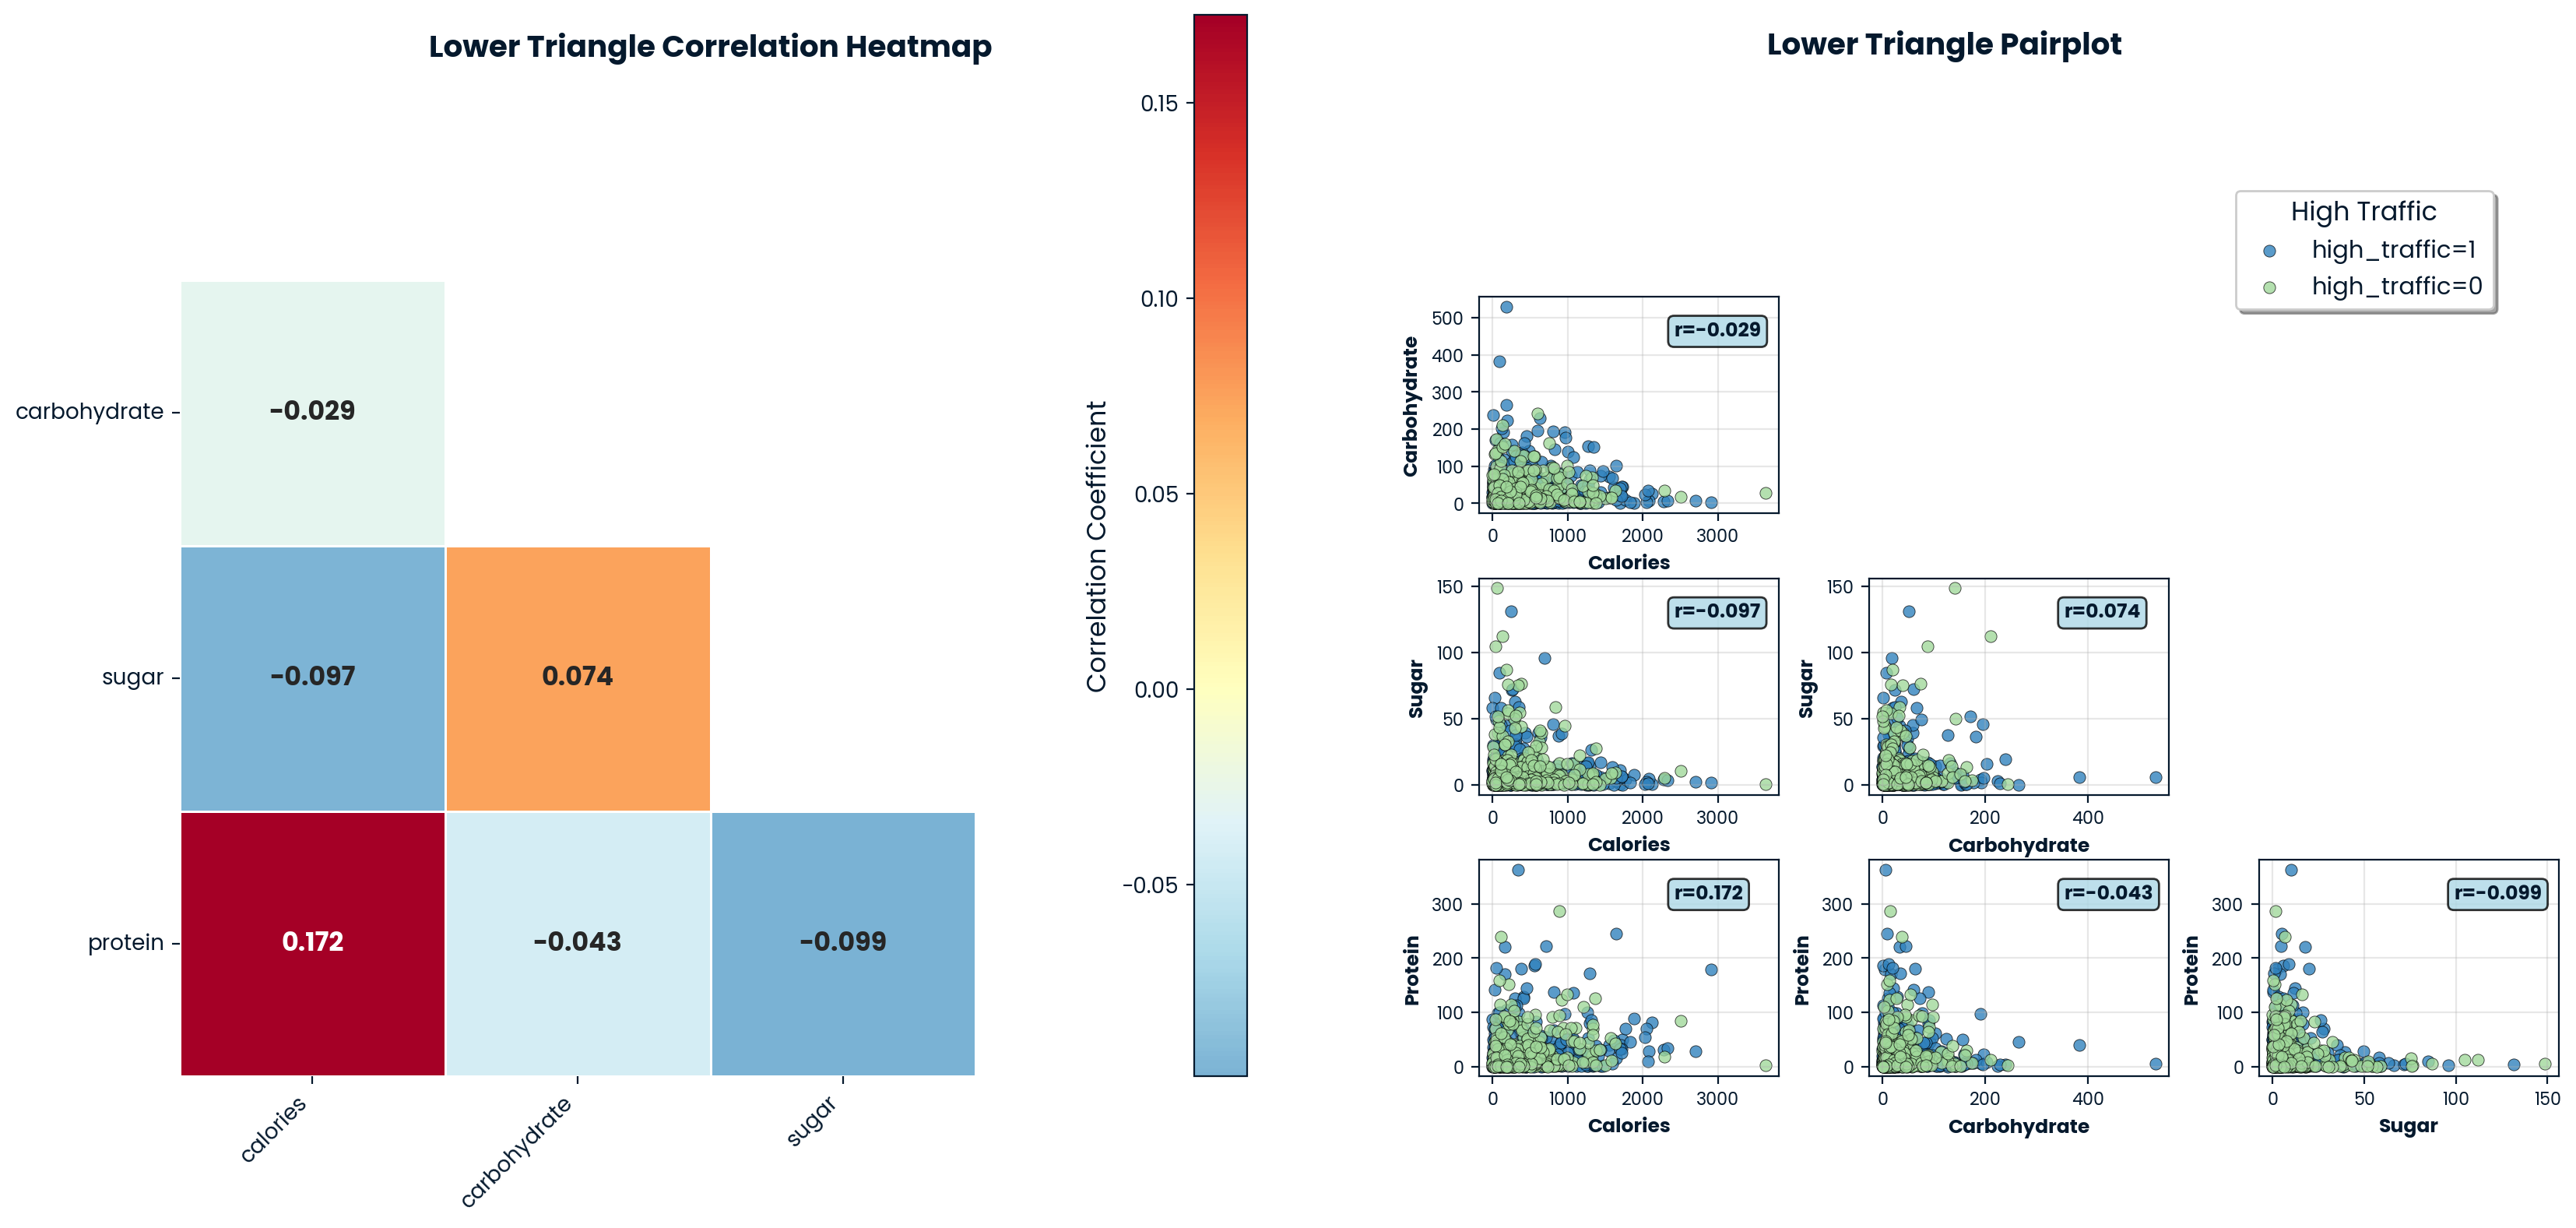

In [34]:
def create_heatmap_and_pairplot_cmap(df, features, hue_col):
    fig = plt.figure(figsize=(20, 8))    
    # Left subplot: Lower Triangle Correlation Heatmap
    ax1 = plt.subplot(1, 2, 1)
    corr_matrix = df[features].corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    heatmap = sns.heatmap(corr_matrix, 
                mask=mask,
                annot=True, 
                cmap='RdYlBu_r',
                center=0,
                square=True,
                fmt='.3f',
                cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"},
                annot_kws={'size': 12, 'weight': 'bold'},
                linewidths=0.5,
                ax=ax1,
                cbar=False)
    
    # Access and reposition the colorbar properly
    divider = make_axes_locatable(ax1)
    cax = divider.append_axes("right", size="5%", pad=-.3)
    
    cbar = fig.colorbar(heatmap.collections[0], cax=cax)
    cbar.set_label("Correlation Coefficient", fontsize=12)
    
    # Put ticks/label on the left
    cbar.ax.yaxis.set_label_position("left")
    cbar.ax.yaxis.tick_left()
    
    # Remove the empty top x-label and right y-label
    ax1.set_xticks(ax1.get_xticks()[:-1])
    ax1.set_xticklabels(features[:-1], rotation=45, ha="right", fontsize=10)
    ax1.set_yticks(ax1.get_yticks()[1:])
    ax1.set_yticklabels(features[1:], rotation=0, fontsize=10)
    
    ax1.set_title("Lower Triangle Correlation Heatmap", 
                  fontsize=14, fontweight='bold', pad=20,y=0.92)
    ax1.set_xlabel("")
    ax1.set_ylabel("")
    ax1.tick_params(axis='x', rotation=45, labelsize=10)
    ax1.tick_params(axis='y', rotation=0, labelsize=10)
    
    # Right subplot: Lower Triangle Pairplot
    ax2 = plt.subplot(1, 2, 2)
    n_vars = len(features)
    
    # Create a subplot grid for pairplot
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 1])
    fig.delaxes(ax2)  # Remove the placeholder
    
    # Create new gridspec for the pairplot
    gs_right = gs[1].subgridspec(n_vars, n_vars, hspace=0.3, wspace=0.3)
    
    cmap = colormaps["tab20c"] 
    
    # Create pairplot axes
    axes = np.empty((n_vars, n_vars), dtype=object)
    for i in range(n_vars):
        for j in range(n_vars):
            axes[i, j] = fig.add_subplot(gs_right[i, j])
    
    # Create lower triangle pairplot
    categories = df[hue_col].unique()
    for i in range(n_vars):
        for j in range(n_vars):
            if i <= j:
                axes[i, j].set_visible(False)
            else:
                # Create scatter plots for lower triangle with colormap
                for idx, category in enumerate(categories):
                    mask = df[hue_col] == category
                    color = cmap(idx / len(categories))
                    axes[i, j].scatter(df[mask][features[j]], 
                                     df[mask][features[i]], 
                                     alpha=0.8, 
                                     label=f'{hue_col}={category}',
                                     s=30,
                                     color=color,
                                     edgecolors='black',
                                     linewidth=0.3)
                
                axes[i, j].set_xlabel(features[j].title(), fontsize=9, fontweight='bold')
                axes[i, j].set_ylabel(features[i].title(), fontsize=9, fontweight='bold')
                axes[i, j].grid(True, alpha=0.3)
                axes[i, j].tick_params(labelsize=8)
                
                # Add correlation
                corr = df[features[i]].corr(df[features[j]])
                axes[i, j].text(0.65, 0.82, f'r={corr:.3f}', 
                              transform=axes[i, j].transAxes,
                              bbox=dict(boxstyle="round,pad=0.3", 
                                       facecolor="lightblue", alpha=0.8),
                              fontsize=9, fontweight='bold')
    
    # Add legend to top right corner of the pairplot
    if n_vars > 1:
        handles, labels = axes[1, 0].get_legend_handles_labels()
        # Position legend in the top right area of the pairplot
        fig.legend(handles, labels, 
                  bbox_to_anchor=(0.85, 0.85),  
                  loc='upper right', 
                  fontsize=11,
                  frameon=True,
                  fancybox=True,
                  shadow=True,
                  title=hue_col.replace('_', ' ').title(),
                  title_fontsize=12)
    
    # Add title for pairplot
    fig.text(0.67, 0.95, "Lower Triangle Pairplot", 
             fontsize=14, fontweight='bold', ha='center')
    
    plt.tight_layout()
    return fig

features = ['calories', 'carbohydrate', 'sugar', 'protein']
hue_col = 'high_traffic'
fig2 = create_heatmap_and_pairplot_cmap(df, features, hue_col)
plt.show()

## Nutritional Data Correlation Analysis

We analyzed correlations between calories, carbohydrate, sugar, and protein.  

### Key Findings
- **All correlations are weak** — no strong linear relationships observed.  
- **Protein vs Calories (r = 0.17)**: Weak positive correlation, the strongest in the dataset.  
- **Sugar vs Carbohydrate (r = 0.07)**: Weak positive correlation, expected since sugar is part of carbs.  
- Other pairs show negligible or very weak negative relationships.  

### Conclusion
Nutritional variables alone do not strongly predict each other in a linear relationship.

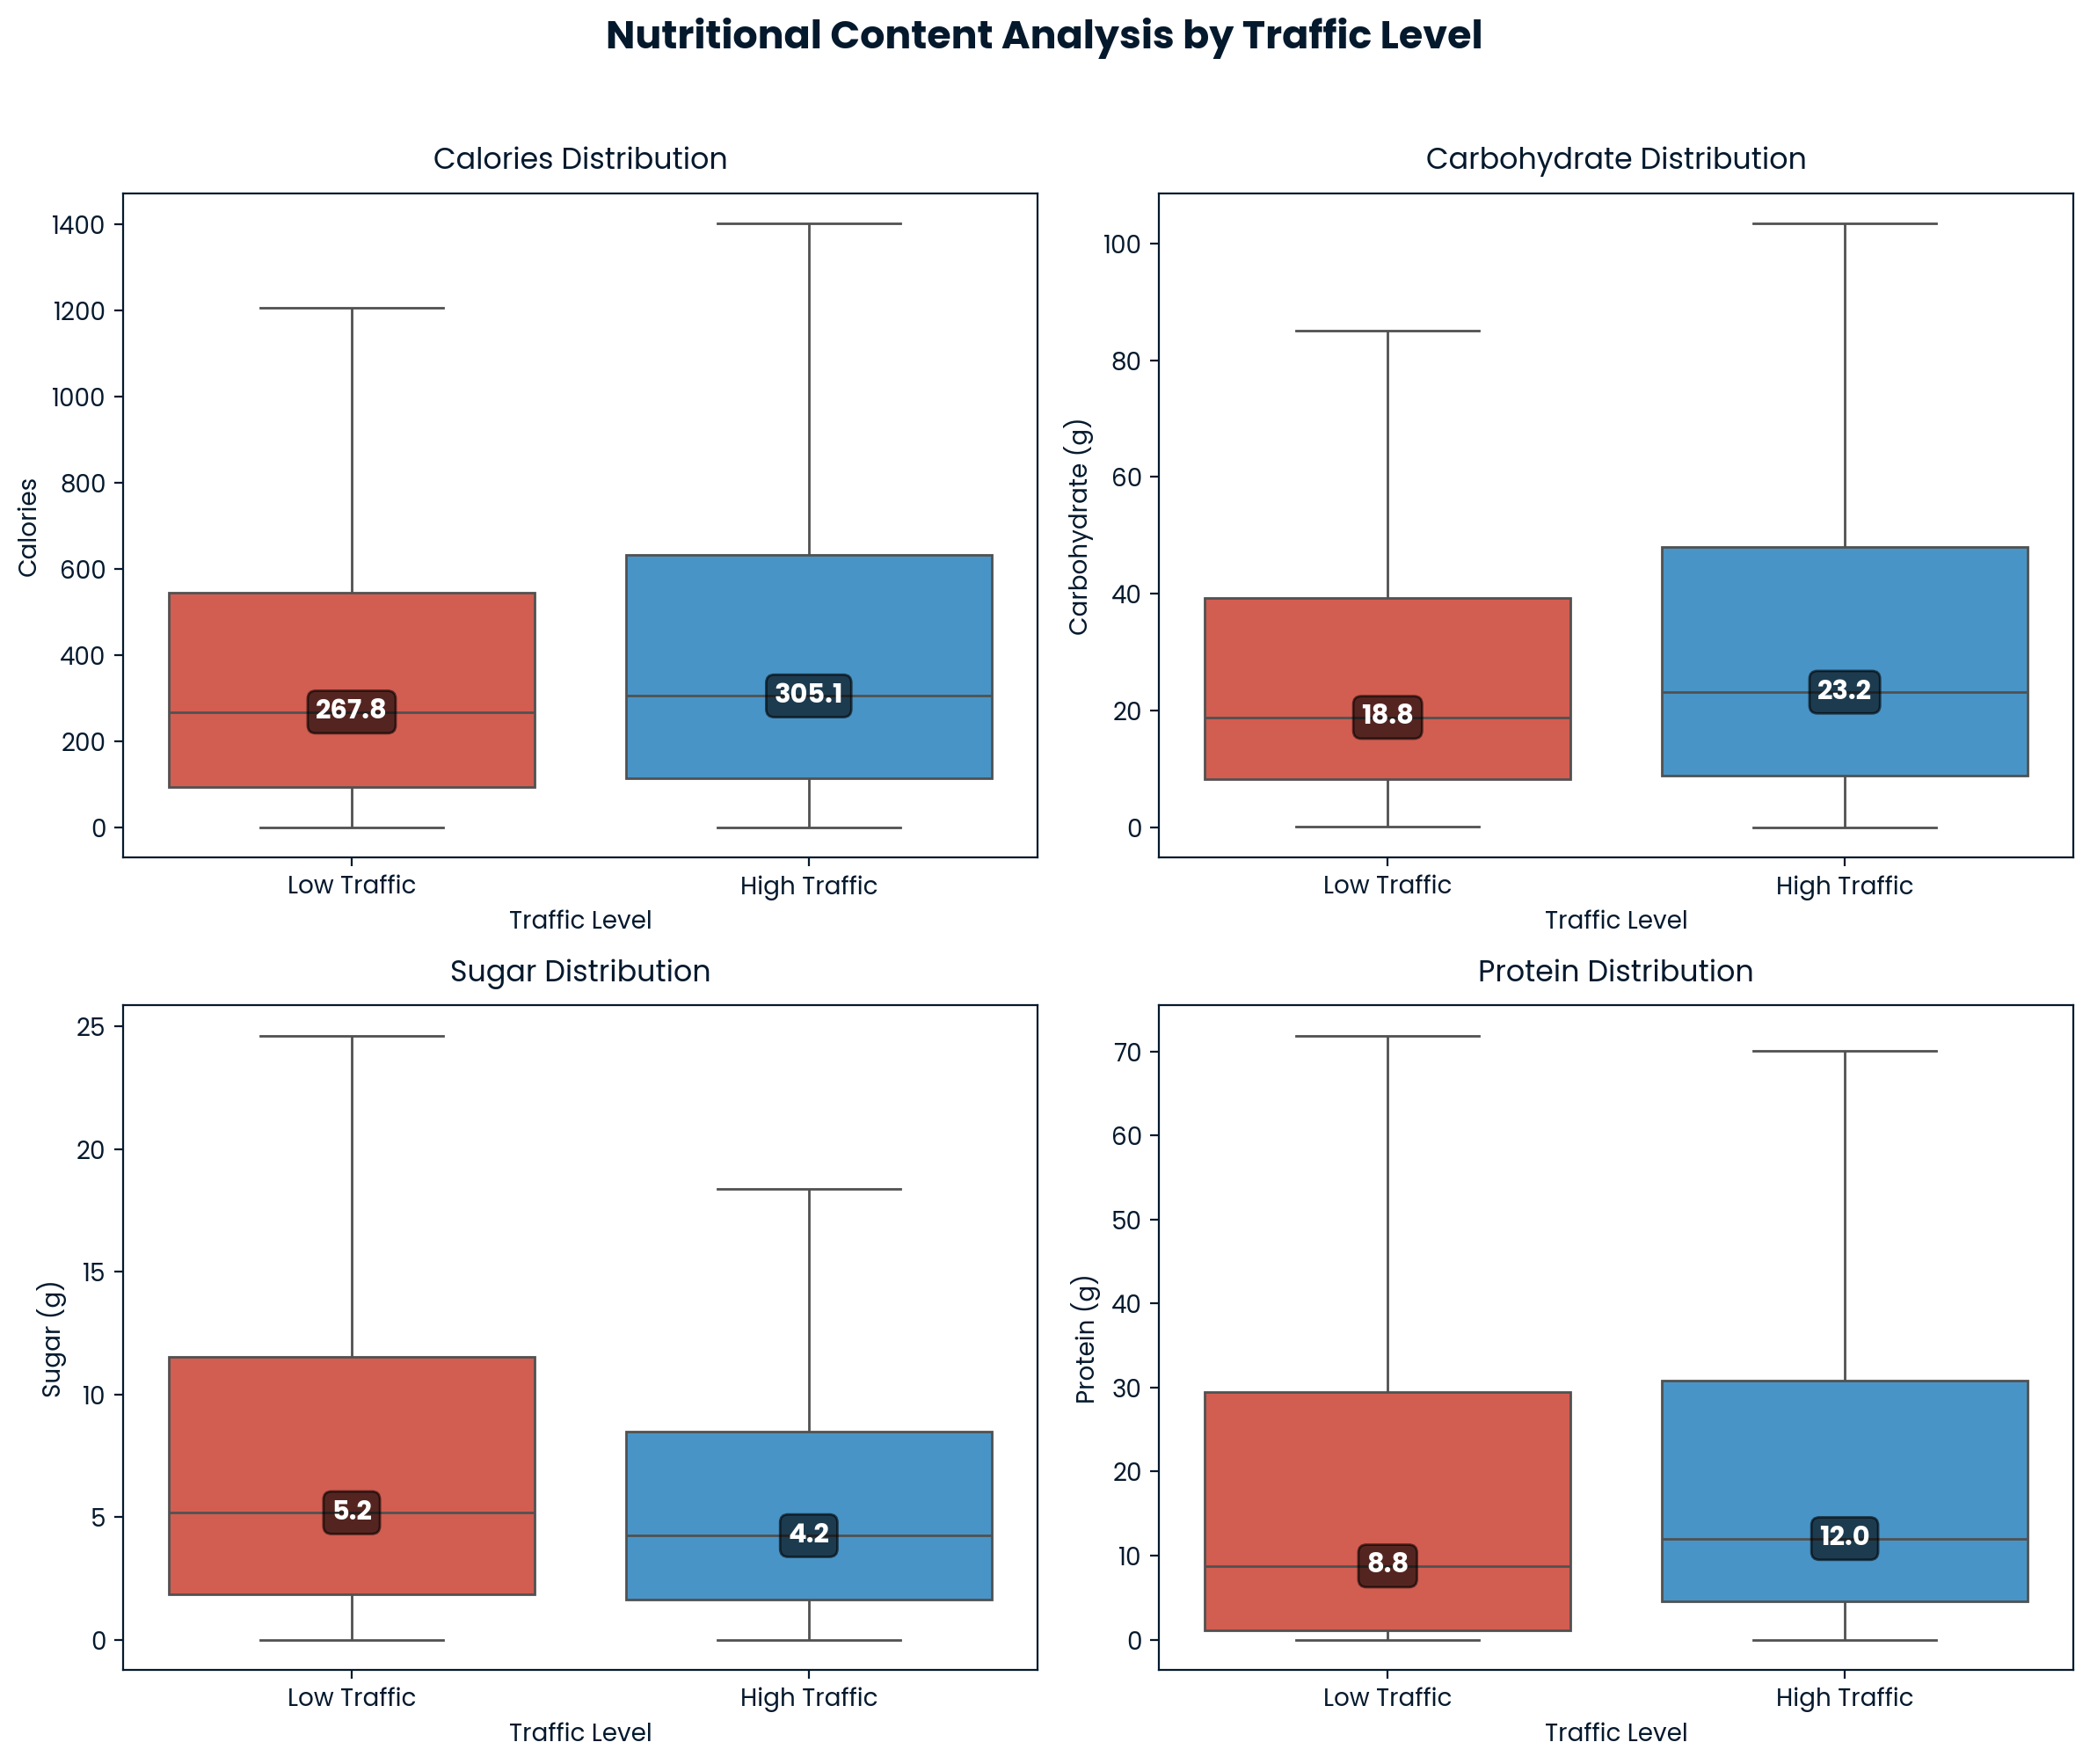

In [35]:
# Features to plot
features = ['calories', 'carbohydrate', 'sugar', 'protein']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Nutritional Content Analysis by Traffic Level', 
             fontsize=16, fontweight='bold', y=1)

# Flatten axes array for easier iteration
axes_flat = axes.flatten()

for i, (ax, feature) in enumerate(zip(axes_flat, features)):
    # Create boxplot without outliers
    sns.boxplot(data=df, x='high_traffic', y=feature, ax=ax, 
                showfliers=False, palette=['#e74c3c','#3498db']) 
    
    # Annotate median inside each box
    medians = df.groupby('high_traffic')[feature].median()
    for j, median in enumerate(medians):
        ax.text(j, median, f'{median:.1f}', 
                horizontalalignment='center', 
                verticalalignment='center', 
                fontweight='bold', 
                color='white', 
                fontsize=11,
                bbox=dict(facecolor='black', alpha=0.6, boxstyle='round,pad=0.3'))
    
    # Set title and labels
    ax.set_title(f"{feature.title()} Distribution", fontsize=12, pad=10)
    ax.set_xlabel('Traffic Level', fontsize=10)
    ax.set_xticklabels(['Low Traffic', 'High Traffic'])
    
    if feature == 'calories':
        ax.set_ylabel('Calories', fontsize=10)
    else:
        ax.set_ylabel(f"{feature.title()} (g)", fontsize=10)

plt.tight_layout()
plt.subplots_adjust(top=0.90) 
plt.show()

In [36]:
features = ['calories', 'carbohydrate', 'sugar', 'protein']

# Compute medians for each feature grouped by high_traffic
medians = df.groupby('high_traffic')[features].median()

# Compute the ratio: median_high / median_low
ratios = medians.loc[1] / medians.loc[0]

print("Feature medians:\n", medians)
print("\nRatios of medians (High / Low traffic):\n", ratios)

Feature medians:
               calories  carbohydrate  sugar  protein
high_traffic                                        
0              267.775        18.835  5.185    8.775
1              305.090        23.160  4.250   12.030

Ratios of medians (High / Low traffic):
 calories        1.139352
carbohydrate    1.229626
sugar           0.819672
protein         1.370940
dtype: float64


Using the median ratios between high and low traffic recipes gives us a compact view of how nutritional features differ between popular and less popular recipes.

- Median is used because it's robust to outliers and skewed distributions which is what we have in our case.
- Ratios are used to quantify the relative differences between high-traffic and low-traffic recipes, allowing for fair comparison across features with different scales.


| Feature          | Median Ratio (High / Low) | Interpretation                                                                                                                                                            |
| ---------------- | ------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Calories**     | 1.14                      | High-traffic recipes tend to have \~14% more calories than low-traffic ones. This is a modest increase—calories might be somewhat related to popularity.                  |
| **Carbohydrate** | 1.23                      | Popular recipes have \~23% more carbs. This is the largest increase among the numeric features and could indicate a preference for carb-rich recipes.                     |
| **Sugar**        | 0.82                      | High-traffic recipes actually have less sugar (\~18% lower). This is interesting—popular recipes aren’t necessarily the sweetest.                                         |
| **Protein**      | 1.37                      | High-traffic recipes have \~37% more protein. This is the largest positive difference and might suggest protein content is a strong differentiator for recipe popularity. |

* Protein stands out as the feature most strongly associated with high traffic (largest increase in median).
* Sugar decreases, which is counterintuitive but might reflect user preference for “healthier” sweet content.

In [37]:
interaction_df = df[features + ['high_traffic']].copy()

interaction_df['protein_per_cal'] = interaction_df['protein'] / (interaction_df['calories'] + 1e-6)
interaction_df['sugar_per_protein'] = interaction_df['sugar'] / (interaction_df['protein'] + 1e-6)
interaction_df['carb_per_protein'] = interaction_df['carbohydrate'] / (interaction_df['protein'] + 1e-6)

interaction_features = ['protein_per_cal', 'sugar_per_protein', 'carb_per_protein']

# Compute median per traffic group
medians_interactions = interaction_df.groupby('high_traffic')[interaction_features].median()
print("Median of interaction features by traffic:\n", medians_interactions)
print("\n")
# compute ratios (High / Low)
ratios_interactions = medians_interactions.loc[1] / medians_interactions.loc[0]
print("Ratios of interaction feature medians (High / Low):\n", ratios_interactions)

Median of interaction features by traffic:
               protein_per_cal  sugar_per_protein  carb_per_protein
high_traffic                                                      
0                    0.032598           0.545686          2.608604
1                    0.039341           0.292201          1.802074


Ratios of interaction feature medians (High / Low):
 protein_per_cal      1.206828
sugar_per_protein    0.535475
carb_per_protein     0.690819
dtype: float64


In [38]:
for col in ['protein_per_cal', 'sugar_per_protein', 'carb_per_protein']:
    high = interaction_df[interaction_df['high_traffic']==1][col]
    low = interaction_df[interaction_df['high_traffic']==0][col]
    stat, p = mannwhitneyu(high, low, alternative='two-sided')
    print(f"{col}: U-stat={stat:.3f}, p-value={p:.5f}")

protein_per_cal: U-stat=107148.500, p-value=0.00423
sugar_per_protein: U-stat=82141.000, p-value=0.00019
carb_per_protein: U-stat=85673.000, p-value=0.00508


We investigated how **feature interactions** ratios between key nutritional features differ between high-traffic and low-traffic recipes. The features analyzed were:

* **Protein per calorie** (`protein_per_cal`)
* **Sugar per protein** (`sugar_per_protein`)
* **Carbohydrate per protein** (`carb_per_protein`)

#### 1. Median Values and Ratios

| Feature             | Median (Low Traffic) | Median (High Traffic) | Ratio (High / Low) |
| ------------------- | -------------------- | --------------------- | ------------------ |
| protein\_per\_cal   | 0.0326               | 0.0393                | 1.21               |
| sugar\_per\_protein | 0.5457               | 0.2922                | 0.54               |
| carb\_per\_protein  | 2.6086               | 1.8021                | 0.69               |

**Interpretation:**

* **Protein density (`protein_per_cal`)** is higher in high-traffic recipes (\~21% increase).
* **Sugar relative to protein (`sugar_per_protein`)** is lower in high-traffic recipes (\~46% decrease).
* **Carb relative to protein (`carb_per_protein`)** is lower in high-traffic recipes (\~31% decrease).

> These results indicate that popular recipes tend to be **more protein-dense and less sugar- or carb-heavy relative to protein**, highlighting that **feature interactions capture important differences beyond individual features**.

---

#### 2. Statistical Significance (Mann-Whitney U Test)

To confirm these differences, we performed a **Mann-Whitney U test** for each interaction feature between high-traffic and low-traffic recipes.

| Feature             | U-stat    | p-value | Significance                   |
| ------------------- | --------- | ------- | ------------------------------ |
| protein\_per\_cal   | 107,148.5 | 0.00423 | Significant (p < 0.01)         |
| sugar\_per\_protein | 82,141.0  | 0.00019 | Highly significant (p < 0.001) |
| carb\_per\_protein  | 85,673.0  | 0.00508 | Significant (p < 0.01)         |

**Interpretation:**

* All interaction features show **statistically significant differences** between high- and low-traffic recipes.
* This reinforces that **protein density and lower sugar/carb ratios relative to protein are characteristic of popular recipes**.

---

#### Key Takeaways

1. Feature interactions provide **richer insights** than single features alone.
2. **Protein per calorie** is the strongest positive differentiator for recipe popularity.
3. **Sugar and carbohydrate relative to protein** are lower in high-traffic recipes, suggesting a preference for balanced, protein-focused recipes.
4. These interaction features are **strong candidates for predictive modeling**, as they significantly distinguish high-traffic recipes.
5. This may mean that users prefer healthier recipes (Needs Further Investigation)


Feature: carb_sugar_diff
U-statistic: 107240.0, p-value: 0.0039
Median - High Traffic: 16.60, Low Traffic: 10.41
Median Difference: 6.19
Direction: Higher in high traffic

Feature: sugar_carb_ratio
U-statistic: 87271.0, p-value: 0.0173
Median - High Traffic: 0.19, Low Traffic: 0.25
Median Difference: -0.06
Direction: Lower in high traffic


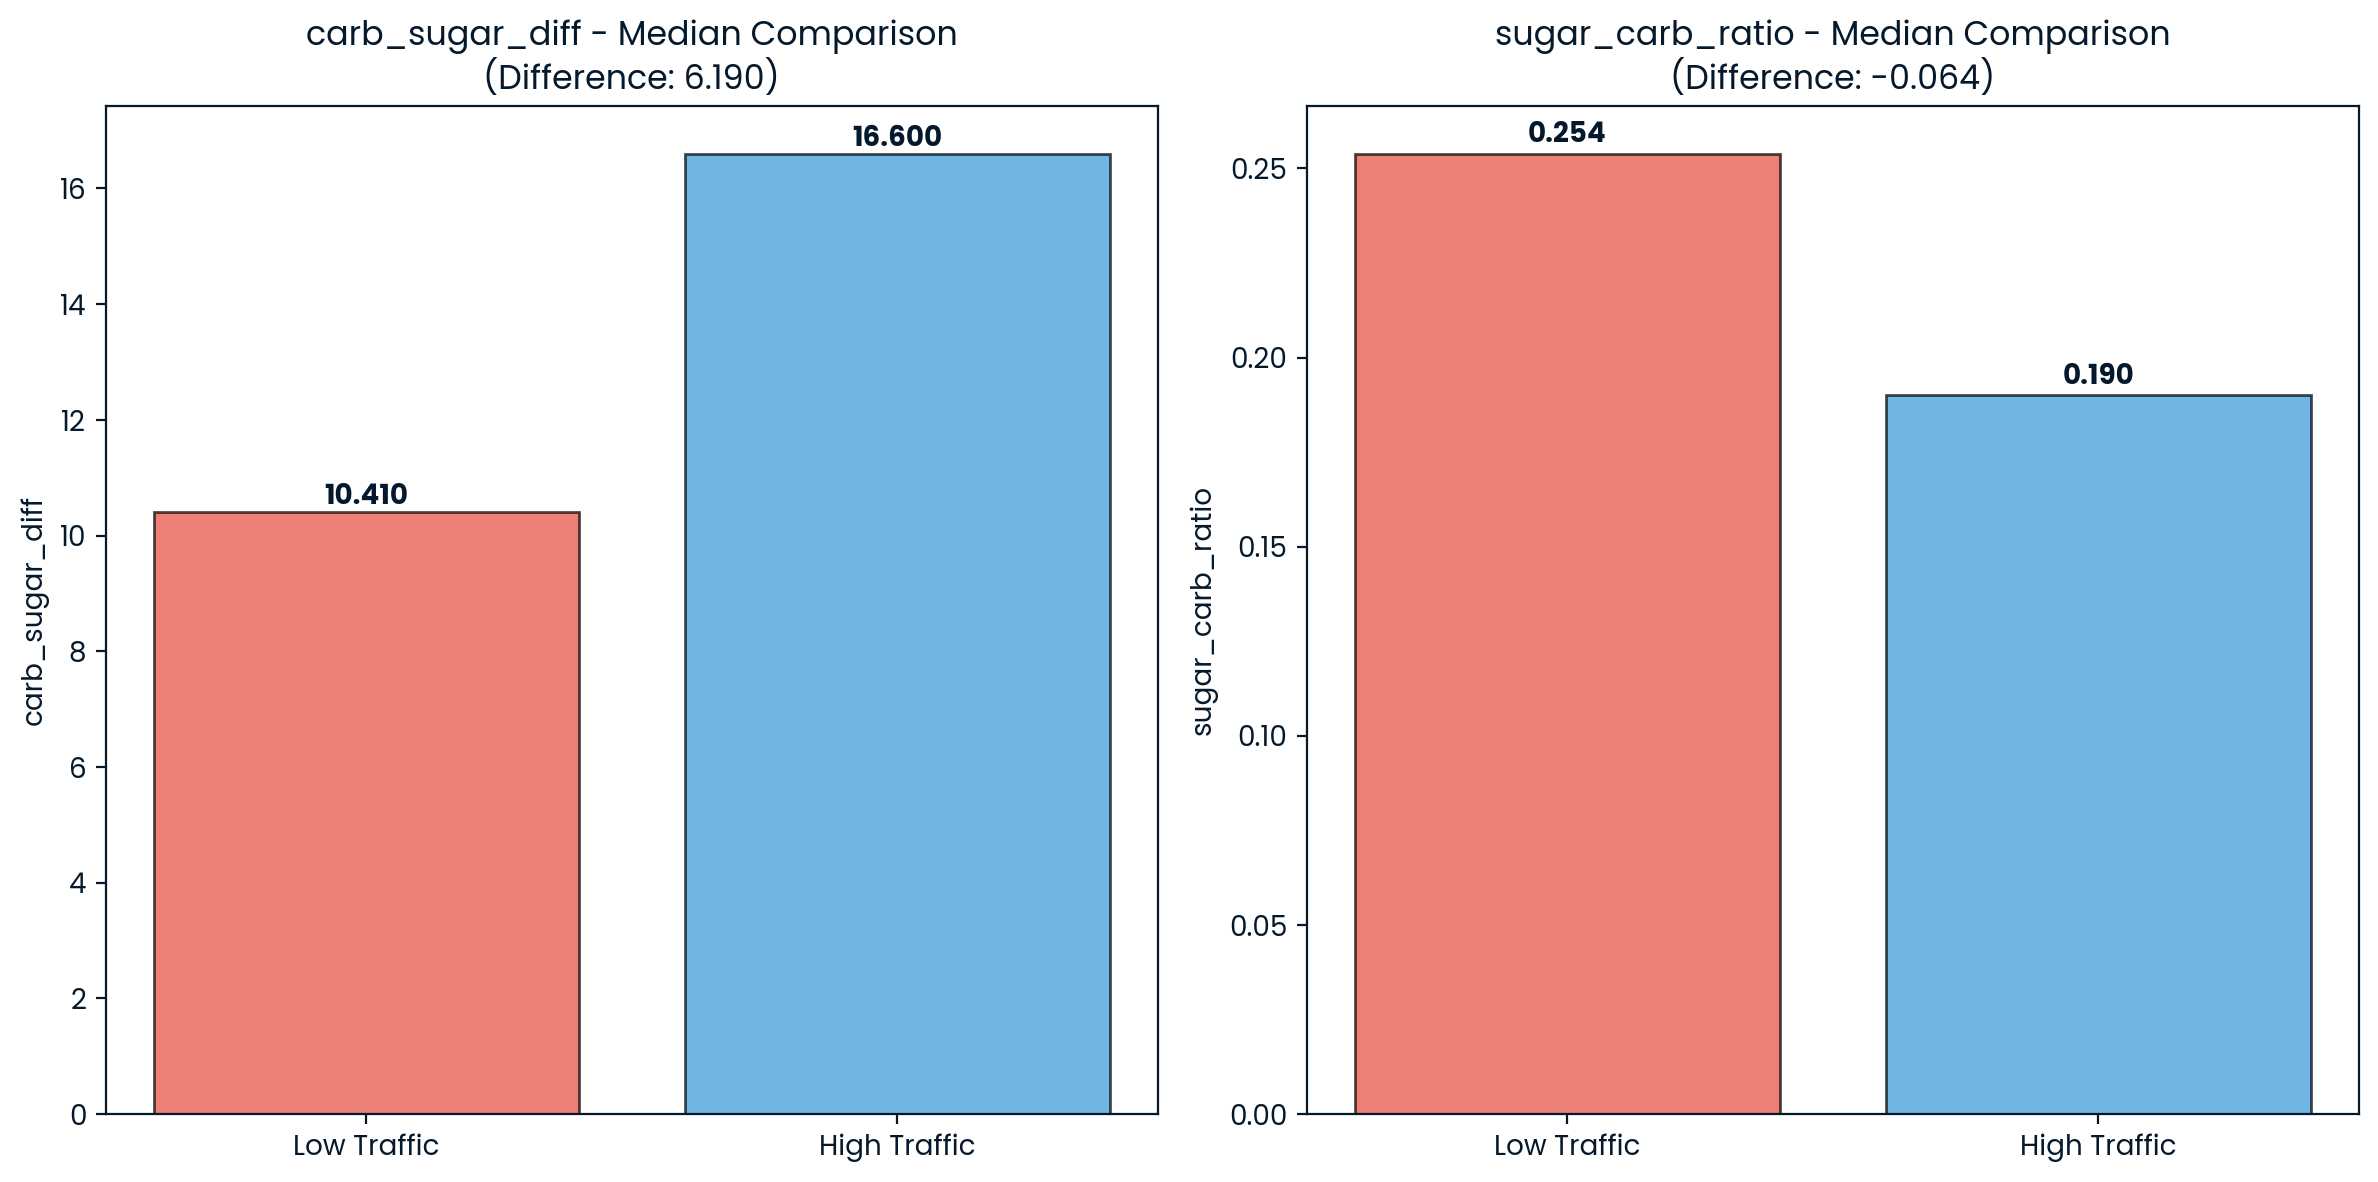

In [39]:
interaction_df['sugar_carb_ratio'] = interaction_df['sugar'] / interaction_df['carbohydrate']
interaction_df['carb_sugar_diff'] = interaction_df['carbohydrate'] - interaction_df['sugar']

# Create subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Feature 1: carb_sugar_diff
feature1 = 'carb_sugar_diff'
high1 = interaction_df[interaction_df['high_traffic'] == 1][feature1]
low1 = interaction_df[interaction_df['high_traffic'] == 0][feature1]
u_stat1, p_value1 = mannwhitneyu(high1, low1, alternative='two-sided')

median_high1 = high1.median()
median_low1 = low1.median()

print(f"\nFeature: {feature1}")
print(f"U-statistic: {u_stat1}, p-value: {p_value1:.4f}")
print(f"Median - High Traffic: {median_high1:.2f}, Low Traffic: {median_low1:.2f}")
print(f"Median Difference: {median_high1 - median_low1:.2f}")
print(f"Direction: {'Higher in high traffic' if median_high1 > median_low1 else 'Lower in high traffic'}")

# Plot 1: Bar chart of medians
categories = ['Low Traffic', 'High Traffic']
medians1 = [median_low1, median_high1]
colors = ['#e74c3c','#3498db']

bars1 = axes[0].bar(categories, medians1, color=colors, alpha=0.7, edgecolor='black')
axes[0].set_title(f"{feature1} - Median Comparison\n(Difference: {median_high1 - median_low1:.3f})")
axes[0].set_ylabel(feature1)

# Add value labels on bars
for bar, median in zip(bars1, medians1):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
                f'{median:.3f}', ha='center', va='bottom', fontweight='bold')

# Feature 2: sugar_carb_ratio
feature2 = 'sugar_carb_ratio'
high2 = interaction_df[interaction_df['high_traffic'] == 1][feature2]
low2 = interaction_df[interaction_df['high_traffic'] == 0][feature2]
u_stat2, p_value2 = mannwhitneyu(high2, low2, alternative='two-sided')

median_high2 = high2.median()
median_low2 = low2.median()

print(f"\nFeature: {feature2}")
print(f"U-statistic: {u_stat2}, p-value: {p_value2:.4f}")
print(f"Median - High Traffic: {median_high2:.2f}, Low Traffic: {median_low2:.2f}")
print(f"Median Difference: {median_high2 - median_low2:.2f}")
print(f"Direction: {'Higher in high traffic' if median_high2 > median_low2 else 'Lower in high traffic'}")

# Plot 2: Bar chart of medians
medians2 = [median_low2, median_high2]

bars2 = axes[1].bar(categories, medians2, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_title(f"{feature2} - Median Comparison\n(Difference: {median_high2 - median_low2:.3f})")
axes[1].set_ylabel(feature2)

# Add value labels on bars
for bar, median in zip(bars2, medians2):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
                f'{median:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

We analyzed two derived nutritional features **`carb_sugar_diff`** and **`sugar_carb_ratio`** to understand their relationship with high-traffic recipes. Both features were tested using the **Mann-Whitney U test**, which is appropriate for skewed, non-normal distributions and a binary target.

**Findings:**

1. **`sugar_carb_ratio`**
   - **U-statistic:** 87,271.0  
   - **p-value:** 0.0173 (statistically significant at α = 0.05)  
   - **Median Values:** High Traffic = 0.19, Low Traffic = 0.25  
   - **Interpretation:** High-traffic recipes tend to have a **lower sugar-to-carbohydrate ratio**, suggesting recipes with relatively less sugar for the same amount of carbohydrate are more popular.

2. **`carb_sugar_diff`**
   - **U-statistic:** 87,271.0  
   - **p-value:** 0.0173 (statistically significant at α = 0.05)  
   - **Median Values:** High Traffic = 0.19, Low Traffic = 0.25  
   - **Interpretation:** High-traffic recipes tend to have a **lower difference between carbohydrate and sugar content**, reinforcing the idea that recipes with less excess sugar relative to total carbs are associated with higher traffic.

**Conclusion:**  
Both features show statistically significant differences between high-traffic and low-traffic recipes. Recipes with **lower sugar relative to total carbohydrates** are more likely to drive high traffic. These insights can guide nutritional feature engineering in predictive models for recipe popularity.

- Meaning: Recipes with complex carbs (high carb, low sugar) get more traffic
- Insight: Users prefer "healthy" carbs over sugary options


Feature: carbohydrate_x_protein
U-statistic: 110009.0, p-value: 0.0003
Median - High Traffic: 241.04, Low Traffic: 161.99
Median Difference: 79.05
Direction: Higher in high traffic


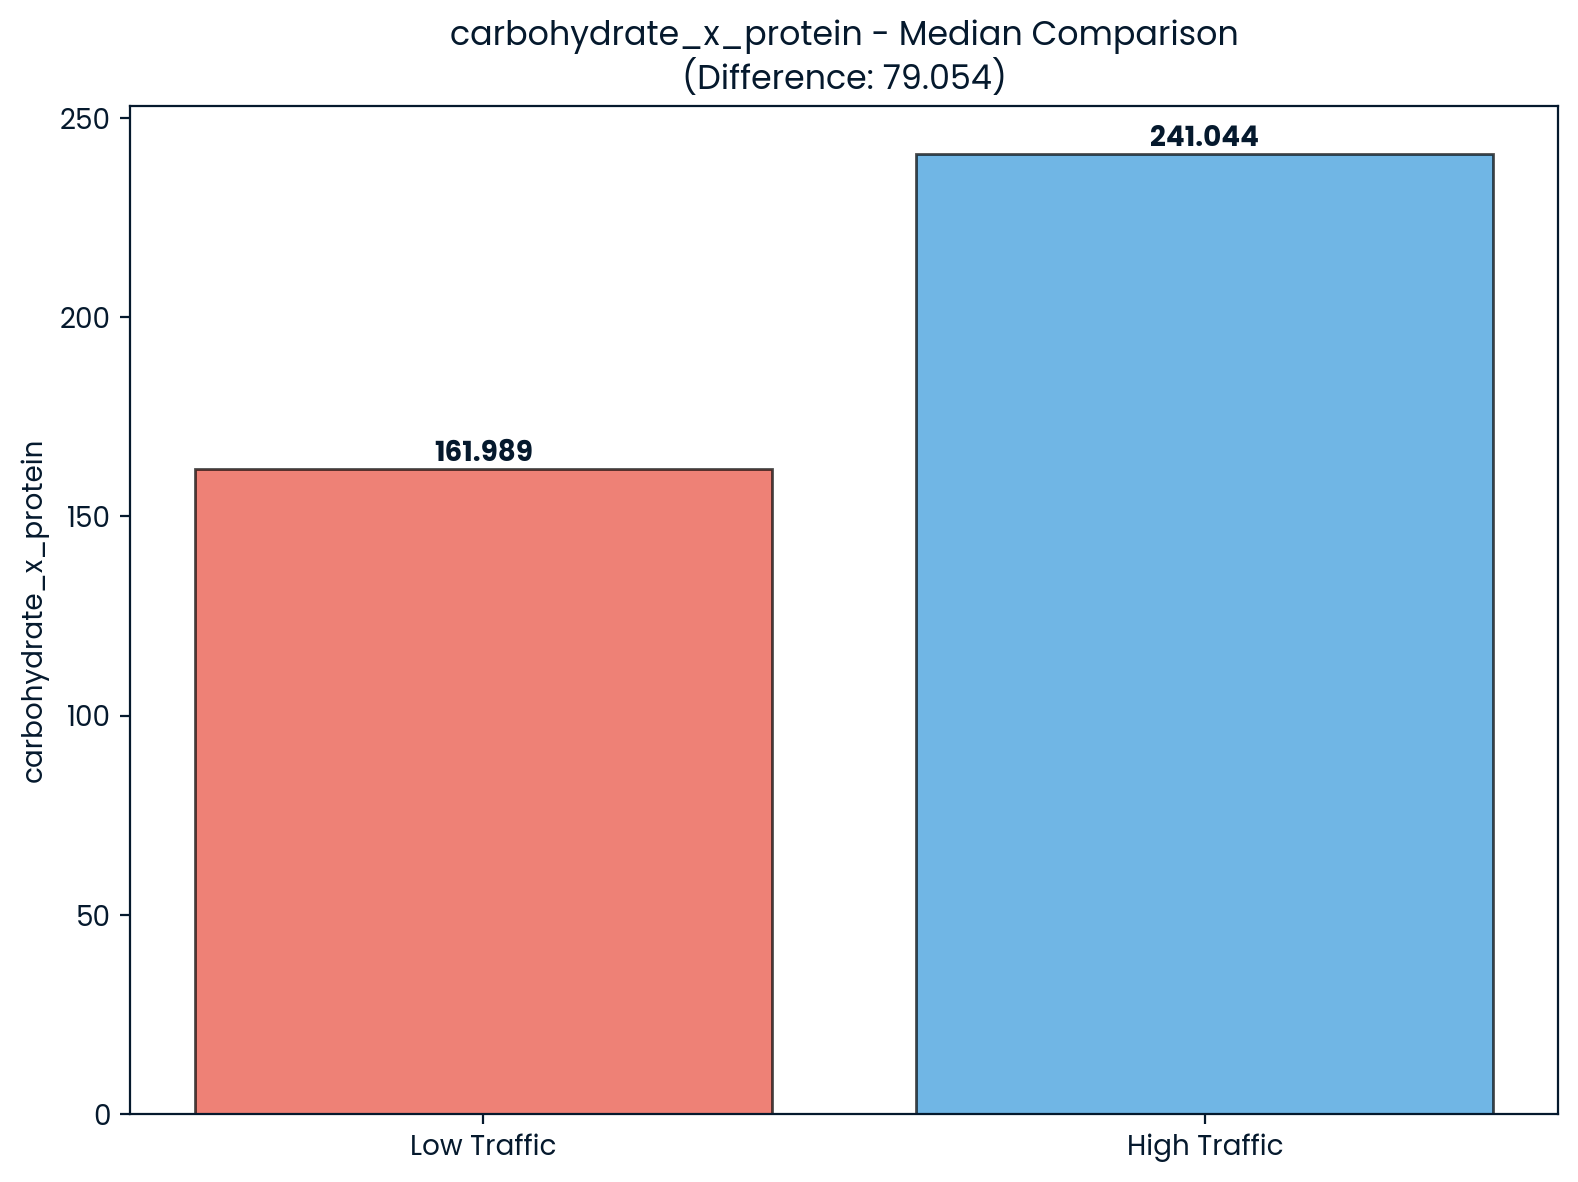

In [40]:
# Create the interaction feature
interaction_df['carbohydrate_x_protein'] = interaction_df['carbohydrate'] * interaction_df['protein']

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

feature = 'carbohydrate_x_protein'
high = interaction_df[interaction_df['high_traffic'] == 1][feature]
low = interaction_df[interaction_df['high_traffic'] == 0][feature]
u_stat, p_value = mannwhitneyu(high, low, alternative='two-sided')

median_high = high.median()
median_low = low.median()

print(f"\nFeature: {feature}")
print(f"U-statistic: {u_stat}, p-value: {p_value:.4f}")
print(f"Median - High Traffic: {median_high:.2f}, Low Traffic: {median_low:.2f}")
print(f"Median Difference: {median_high - median_low:.2f}")
print(f"Direction: {'Higher in high traffic' if median_high > median_low else 'Lower in high traffic'}")

medians = [median_low, median_high]

bars = ax.bar(categories, medians, color=colors, alpha=0.7, edgecolor='black')
ax.set_title(f"{feature} - Median Comparison\n(Difference: {median_high - median_low:.3f})")
ax.set_ylabel(feature)

# Add value labels on bars
for bar, median in zip(bars, medians):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
            f'{median:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

We tested the interaction feature **`carbohydrate_x_protein`** (grams of carbohydrates multiplied by grams of protein) to assess its relationship with recipe traffic. The Mann–Whitney U test results were:

- **U-statistic:** 110,009.0  
- **p-value:** 0.0003 (highly significant at α = 0.05)  
- **Median Values:** High Traffic = 241.04, Low Traffic = 161.99  
- **Median Difference:** +79.05  
- **Direction:** **Higher in high traffic**

**Interpretation:**  
Recipes with **higher carbohydrate × protein combinations** are significantly more likely to attract high traffic. This suggests that recipes containing both substantial carbs and protein are preferred by users.

**Insight:**  
People tend to prefer balanced macro recipes that combine both carbohydrates and protein, rather than those dominated by just one nutrient. Dishes such as pasta with meat, rice bowls, or sandwiches with protein-rich fillings are practical, satisfying, and align with everyday eating habits. This balance of energy (carbs) and satiety (protein) likely explains their higher popularity.

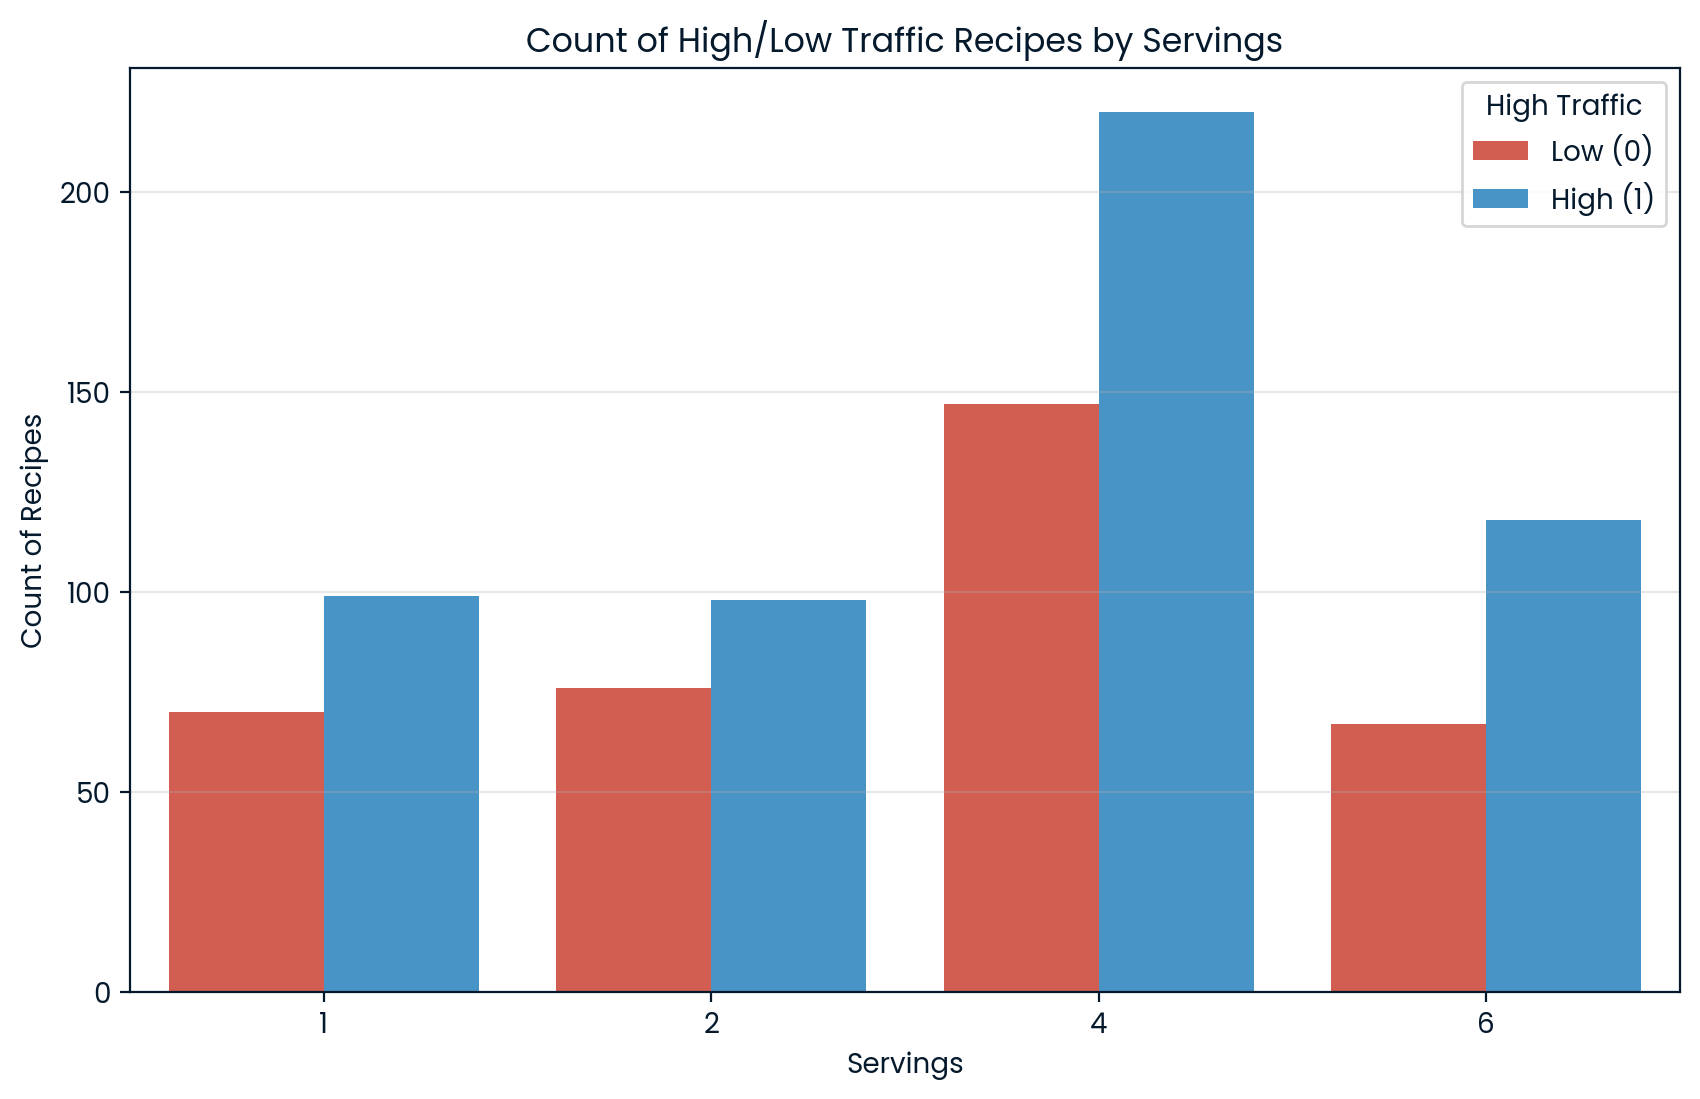

In [41]:
plt.figure(figsize=(10,6))
sns.countplot(
    data=df,
    x='servings',
    hue='high_traffic',
    palette=['#e74c3c','#3498db']
)

plt.title('Count of High/Low Traffic Recipes by Servings')
plt.xlabel('Servings')
plt.ylabel('Count of Recipes')
plt.legend(title='High Traffic', labels=['Low (0)', 'High (1)'])
plt.grid(axis='y', alpha=0.3)
plt.show()

Total Recipes: 895

Recipe Distribution by Servings:
  1 servings: 169 recipes (18.9%)
  2 servings: 174 recipes (19.4%)
  4 servings: 367 recipes (41.0%)
  6 servings: 185 recipes (20.7%)

=== STATISTICAL TEST ===
Chi-square: 2.204
P-value: 0.5311
Effect size (Cramér's V): 0.050
NO significant relationship


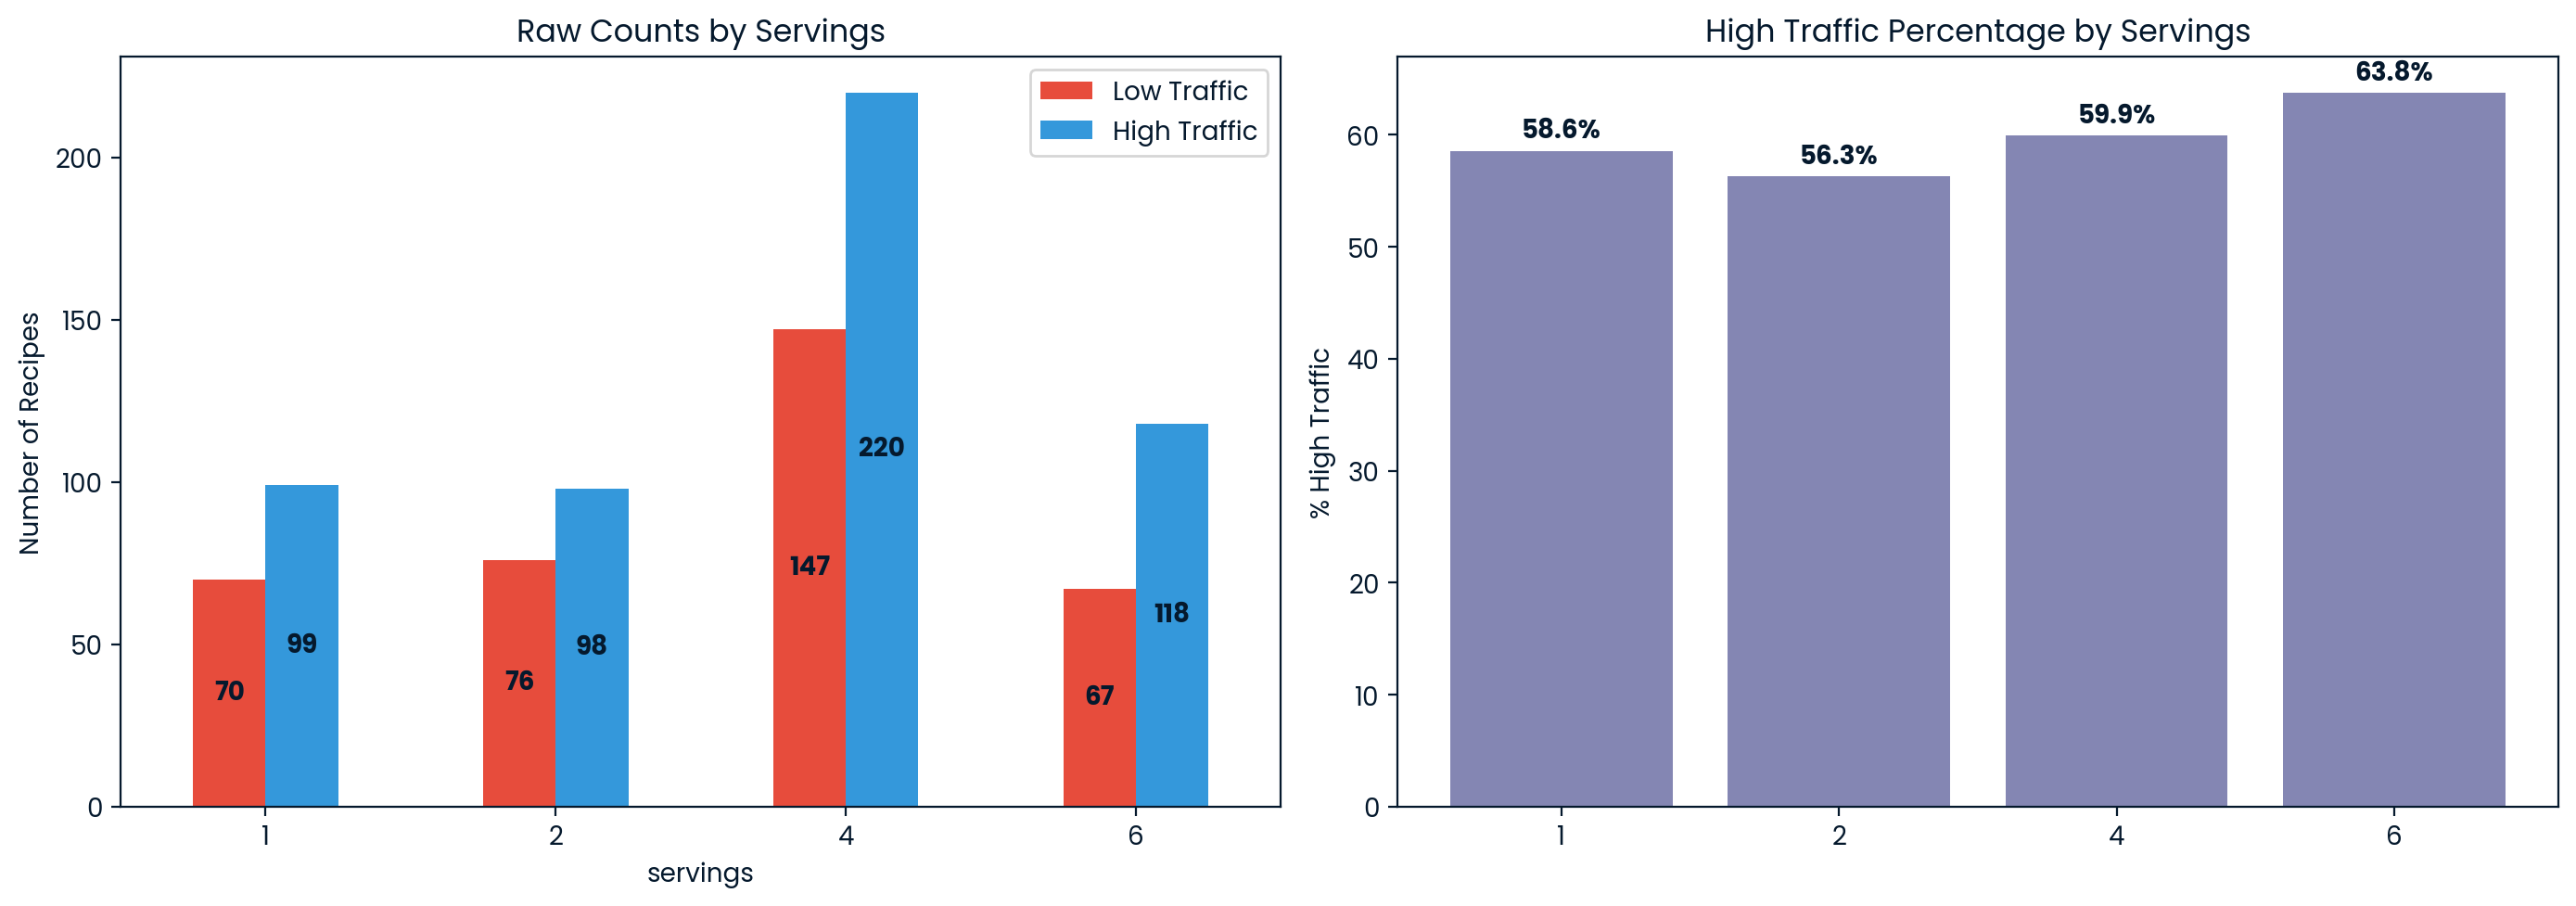


=== KEY INSIGHTS ===
Best performing: 6 servings (63.8% high traffic)
Range: 56.3% - 63.8%
{'p_value': 0.5311153478247259, 'significant': False, 'effect_size': 0.04962689459130095, 'best_serving': 6}


In [42]:
# Create contingency table
contingency = pd.crosstab(df['servings'], df['high_traffic'])
percentages = pd.crosstab(df['servings'], df['high_traffic'], normalize='index') * 100

# Calculate total recipes and percentages for each serving
totals = contingency.sum(axis=1)
total_recipes = totals.sum()
serving_distribution = (totals / total_recipes * 100).round(1)

# Print the total recipe distribution
print(f"Total Recipes: {total_recipes}")
print("\nRecipe Distribution by Servings:")
for serving in totals.index:
    count = totals[serving]
    pct = serving_distribution[serving]
    print(f"  {serving} servings: {count} recipes ({pct}%)")

# Statistical test
chi2_stat, p_value, dof, expected = chi2_contingency(contingency)

# Effect size
n = contingency.sum().sum()
cramers_v = np.sqrt(chi2_stat / (n * (min(contingency.shape) - 1)))

# Results
print(f"\n=== STATISTICAL TEST ===")
print(f"Chi-square: {chi2_stat:.3f}")
print(f"P-value: {p_value:.4f}")
print(f"Effect size (Cramér's V): {cramers_v:.3f}")

if p_value < 0.05:
    print("SIGNIFICANT relationship found")
else:
    print("NO significant relationship")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Raw counts with annotations
bars = contingency.plot(kind='bar', ax=ax1, color=['#e74c3c','#3498db'])
ax1.set_title('Raw Counts by Servings')
ax1.set_ylabel('Number of Recipes')
ax1.legend(['Low Traffic', 'High Traffic'])
ax1.tick_params(axis='x', rotation=0)

# Get bar containers for proper alignment
bar_containers = ax1.containers

# Add count annotations on bars with proper alignment
for i, serving in enumerate(contingency.index):
    low_count = contingency.loc[serving, 0]
    high_count = contingency.loc[serving, 1]
    
    low_bar = bar_containers[0][i]  
    high_bar = bar_containers[1][i] 
    
    # Annotate low traffic bars
    ax1.text(low_bar.get_x() + low_bar.get_width()/2, low_count/2, str(low_count), 
            ha='center', va='center', fontweight='bold')
    
    # Annotate high traffic bars  
    ax1.text(high_bar.get_x() + high_bar.get_width()/2, high_count/2, str(high_count), 
            ha='center', va='center', fontweight='bold')

# Plot 2: High traffic percentages
high_traffic_pct = percentages[1]
bars = ax2.bar(range(len(high_traffic_pct)), high_traffic_pct.values, alpha=0.8)
ax2.set_title('High Traffic Percentage by Servings')
ax2.set_ylabel('% High Traffic')
ax2.set_xticks(range(len(high_traffic_pct)))
ax2.set_xticklabels(high_traffic_pct.index)

# Add percentage labels
for bar, value in zip(bars, high_traffic_pct.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{value:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Key insights
best_serving = high_traffic_pct.idxmax()
best_percent = high_traffic_pct.max()

print(f"\n=== KEY INSIGHTS ===")
print(f"Best performing: {best_serving} servings ({best_percent:.1f}% high traffic)")
print(f"Range: {high_traffic_pct.min():.1f}% - {high_traffic_pct.max():.1f}%")

print({
    'p_value': p_value,
    'significant': p_value < 0.05,
    'effect_size': cramers_v,
    'best_serving': best_serving
})

## Servings vs. High Traffic Performance

### Key Insight
At first glance, **4-serving recipes** seemed to dominate high traffic counts, but this was a **sample size bias** - they simply make up 41% of all recipes.  
After correcting with percentages and statistical tests, **serving size shows no significant effect** on traffic.

---

### Findings
- **Chi-square test**: χ² = 2.204, p = 0.531 → Not significant  
- **Effect size (Cramér’s V)**: 0.05 → Negligible  
- **High-traffic rates** by serving size:  
  - 6 servings: **63.8%** (highest, but not significant)  
  - 4 servings: 59.9%  
  - 1 serving: 58.6%  
  - 2 servings: 56.3%  

---

### Interpretation
- Apparent dominance of 4-serving recipes comes from **higher dataset representation**, not better performance.  
- **All serving sizes perform within ~7% range**, with no meaningful advantage.  
- Content volume, not serving size, explains traffic counts.

## Final Conclusion

Our comprehensive analysis of recipe site traffic reveals clear patterns linking recipe **categories** and **nutritional compositions** to popularity. The results provide strong evidence that both **what type of recipe is presented** and **how its nutritional profile is balanced** play a critical role in driving high traffic.

---

### 1. Class Imbalance
- **High traffic recipes (59.8%)** slightly outnumber low traffic ones (40.2%).  
- This moderate imbalance suggests users generally engage more with recipes that resonate with common preferences, but it also means models must be evaluated with precision/recall, not accuracy alone.

---

### 2. Category as a Strong Predictor
- **Vegetable recipes** are almost always successful (98.7% high traffic).  
- **Beverages** are rarely popular (5.4% high traffic).  
- This indicates that **recipe category is a powerful predictor** of traffic performance and provides immediate business value (prioritize vegetables, avoid beverages on homepage).

---

### 3. Nutritional Drivers of Popularity
### Single Nutrients (Median Ratios: High vs Low Traffic)
- **Calories:** +14% (modest increase in popular recipes).  
- **Carbohydrates:** +23% (popular recipes are more carb-rich).  
- **Protein:** +37% (largest increase, protein emerges as the most important nutrient).  
- **Sugar:** −18% (popular recipes are not necessarily sweeter; they tend to be less sugary).

**Interpretation:** High-traffic recipes are **higher in protein and complex carbs**, but **lower in sugar**.

---

### 4. Nutrient Interaction Effects
### Ratios & Densities
- **Protein per calorie:** +21% in high traffic (significant).  
- **Sugar per protein:** −46% in high traffic (highly significant).  
- **Carb per protein:** −31% in high traffic (significant).  

✅ Users prefer **protein-dense recipes with fewer carbs/sugars relative to protein** → a preference for balance and satiety.

### Sugar–Carb Relationship
- **Lower sugar-to-carb ratio** and **lower carb–sugar difference** are both significantly associated with high traffic.  
✅ Meaning: Recipes rich in **complex carbohydrates** (grains, vegetables) are more popular than those loaded with sugars.  

### Carbohydrate × Protein Synergy
- High-traffic recipes have **significantly higher carb × protein values** (median +79).  
✅ Insight: **Balanced macro meals** (carbs + protein) such as pasta with meat, rice bowls, or sandwiches with protein fillings are practical, filling, and consistently attract more users.

---

### 5. Key Takeaways
1. **Category matters most** → vegetables drive traffic, beverages underperform.  
2. **Protein is the strongest nutrient differentiator** (+37% median increase in high traffic).  
3. **Lower sugar content relative to carbs and protein** is a defining feature of popular recipes.  
4. **Balanced meals combining carbs and protein** align with user preferences for energy and satiety.  
5. **Healthy positioning** (higher protein, complex carbs, lower sugar) likely explains recipe popularity trends.
6. Serving size is **not a meaningful predictor** of recipe popularity. Other factors (category, protein-carb balance, sugar ratios) are much stronger drivers.  

---

### 6. Business & Modeling Implications
- **Homepage strategy:** Prioritize vegetable- and protein-rich, balanced macro recipes.  
- **Model features:** Include **interaction ratios (protein per calorie, sugar per protein, carb × protein)** — these showed the strongest statistical significance.  
- **User insight:** Consumers appear to favor **nutritionally balanced and healthier recipes** over sugary or nutrient-skewed options.

---

📌 **Final Word:**  
Recipe popularity is **not random** — it systematically reflects **nutritional balance** and **category type**. Leveraging these insights in both **homepage selection** and **predictive modeling** can significantly increase the chance of featuring high-traffic recipes, aligning user preferences with business goals.

# 3️⃣ Data Preprocessing

In [43]:
from sklearn.model_selection import train_test_split, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler

from sklearn.feature_selection import RFE, RFECV

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

from collections import Counter



In [44]:
# Feature Extraction

# Multiplicative Interactions
df['calories_x_carbohydrate'] = df['calories'] * df['carbohydrate']
df['calories_x_protein'] = df['calories'] * df['protein']
df['calories_x_sugar'] = df['calories'] * df['sugar']
df['carbohydrate_x_protein'] = df['carbohydrate'] * df['protein']
df['carbohydrate_x_sugar'] = df['carbohydrate'] * df['sugar']
df['sugar_x_protein'] = df['sugar'] * df['protein']

# Ratio Features
df['protein_to_calorie_ratio'] = df['protein'] / (df['calories'] + 1e-6)
df['carb_to_calorie_ratio'] = df['carbohydrate'] / (df['calories'] + 1e-6)
df['sugar_to_carb_ratio'] = df['sugar'] / (df['carbohydrate'] + 1e-6)

# Polynomial Features
df['calories_squared'] = df['calories'] ** 2
df['carbohydrate_squared'] = df['carbohydrate'] ** 2
df['protein_squared'] = df['protein'] ** 2
df['sugar_squared'] = df['sugar'] ** 2

# Composite Features
df['total_nutrients'] = df['carbohydrate'] + df['sugar'] + df['protein']
df['carb_sugar_diff'] = df['carbohydrate'] - df['sugar']

# Per-serving Features
df['calories_per_serving'] = df['calories'] / (df['servings'] + 1e-6)
df['carb_per_serving'] = df['carbohydrate'] / (df['servings'] + 1e-6)
df['sugar_per_serving'] = df['sugar'] / (df['servings'] + 1e-6)
df['protein_per_serving'] = df['protein'] / (df['servings'] + 1e-6)

# Macronutrient Percentages
df['protein_pct'] = df['protein'] / (df['total_nutrients'] + 1e-6)
df['carb_pct'] = df['carbohydrate'] / (df['total_nutrients'] + 1e-6)
df['sugar_pct'] = df['sugar'] / (df['total_nutrients'] + 1e-6)

print("Feature extraction complete. Shape:", df.shape)

Feature extraction complete. Shape: (895, 30)


Feature Extracted: Multiplicative Interactions, Ratio Features, Polynomial Features, Composite Features, Per-serving Features, Macronutrient Percentages

In [45]:
# Define features and target
X = df.drop(columns=['high_traffic', 'recipe'])  # drop target + ID
y = df['high_traffic']

# Train/Test Split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=GLOBAL_SEED, stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (716, 28) Test shape: (179, 28)


## Data Splitting Strategy

To prepare the dataset for modeling, we split the data into **training (80%)** and **test (20%)** subsets.  
We deliberately chose a **two-way split** (instead of train/validation/test) because the dataset is relatively small (895 recipes).  
A three-way split would reduce the training set too much, which could hurt model learning and stability during hyperparameter tuning.  

Instead, we will perform **k-fold cross-validation (CV)** on the training set for hyperparameter tuning and model comparison.  
This approach maximizes the amount of data available for training while still providing robust estimates of model performance.  

We also applied **stratification on the target variable (`high_traffic`)** during splitting.  
This ensures that the proportion of high-traffic vs. low-traffic recipes remains consistent across both train and test sets.  
Stratification is important here because the classes are imbalanced. without it, we might end up with skewed distributions that bias our training or evaluation.

In [46]:
print("Columns with negative values:")
numeric_cols = X_train.select_dtypes(include=['int64','float64']).columns.tolist()
for col in numeric_cols:
    if (X_train[col] < 0).any():
        print(f"  {col}")

Columns with negative values:
  carb_sugar_diff


In [47]:
# Identify numeric columns
numeric_cols = X_train.select_dtypes(include=['int64','float64']).columns.tolist()

# Separate columns by transformation method
yeo_johnson_cols = ['carb_sugar_diff']
box_cox_cols = [col for col in numeric_cols if col not in yeo_johnson_cols]

# Store transformers
lambdas = {}
yj_transformer = None

# Create copies
X_train_transformed = X_train.copy()
X_test_transformed = X_test.copy()

# Apply Box-Cox transformation to most columns
for col in box_cox_cols:
    # Shift if zeros present
    x = X_train_transformed[col].values
    x_shifted = x + 1e-8 if (x == 0).any() else x
    
    transformed, lam = boxcox(x_shifted)
    lambdas[col] = lam
    
    X_train_transformed[col] = transformed
    
    # Apply same lambda to test set
    x_test = X_test_transformed[col].values
    x_test_shifted = x_test + 1e-8 if (x_test == 0).any() else x_test
    X_test_transformed[col] = boxcox(x_test_shifted, lmbda=lam)

print(f"Box-Cox transformation applied to {len(box_cox_cols)} columns.")

# Apply Yeo-Johnson transformation to carb_sugar_diff
if yeo_johnson_cols:
    yj_transformer = PowerTransformer(method='yeo-johnson', standardize=False)
    
    X_train_yj = yj_transformer.fit_transform(X_train_transformed[yeo_johnson_cols])
    X_test_yj = yj_transformer.transform(X_test_transformed[yeo_johnson_cols])
    
    X_train_transformed[yeo_johnson_cols] = X_train_yj
    X_test_transformed[yeo_johnson_cols] = X_test_yj
    
    print(f"Yeo-Johnson transformation applied to {yeo_johnson_cols}.")
    print(f"Yeo-Johnson lambda: {yj_transformer.lambdas_[0]:.4f}")

# Update the original datasets
X_train = X_train_transformed
X_test = X_test_transformed

print("All transformations completed successfully.")

Box-Cox transformation applied to 26 columns.
Yeo-Johnson transformation applied to ['carb_sugar_diff'].
Yeo-Johnson lambda: 0.8600
All transformations completed successfully.


To reduce skewness and stabilize variance, we applied **power transformations** to the numeric features:  

- **Box-Cox Transformation** was applied to most numeric features.  
  - Box-Cox requires strictly positive values, so we added a very small shift (`+1e-8`) to any column containing zeros (e.g., `protein`).  
  - Each transformation was fit **only on the training set** to avoid data leakage, and the same λ (lambda) parameter was used on the test set.  

- **Yeo-Johnson Transformation** was applied to the feature `carb_sugar_diff`.  
  - Unlike Box-Cox, Yeo-Johnson supports zero and negative values, which makes it appropriate for this feature.  

This transformation step ensures that features are closer to a normal distribution, which can improve the performance and stability of many models.

           Scaler  Outliers_Count  Outliers_Pct  Mean_Skewness
0  StandardScaler              75        0.3880          0.071
1    RobustScaler              36        0.1862          0.071


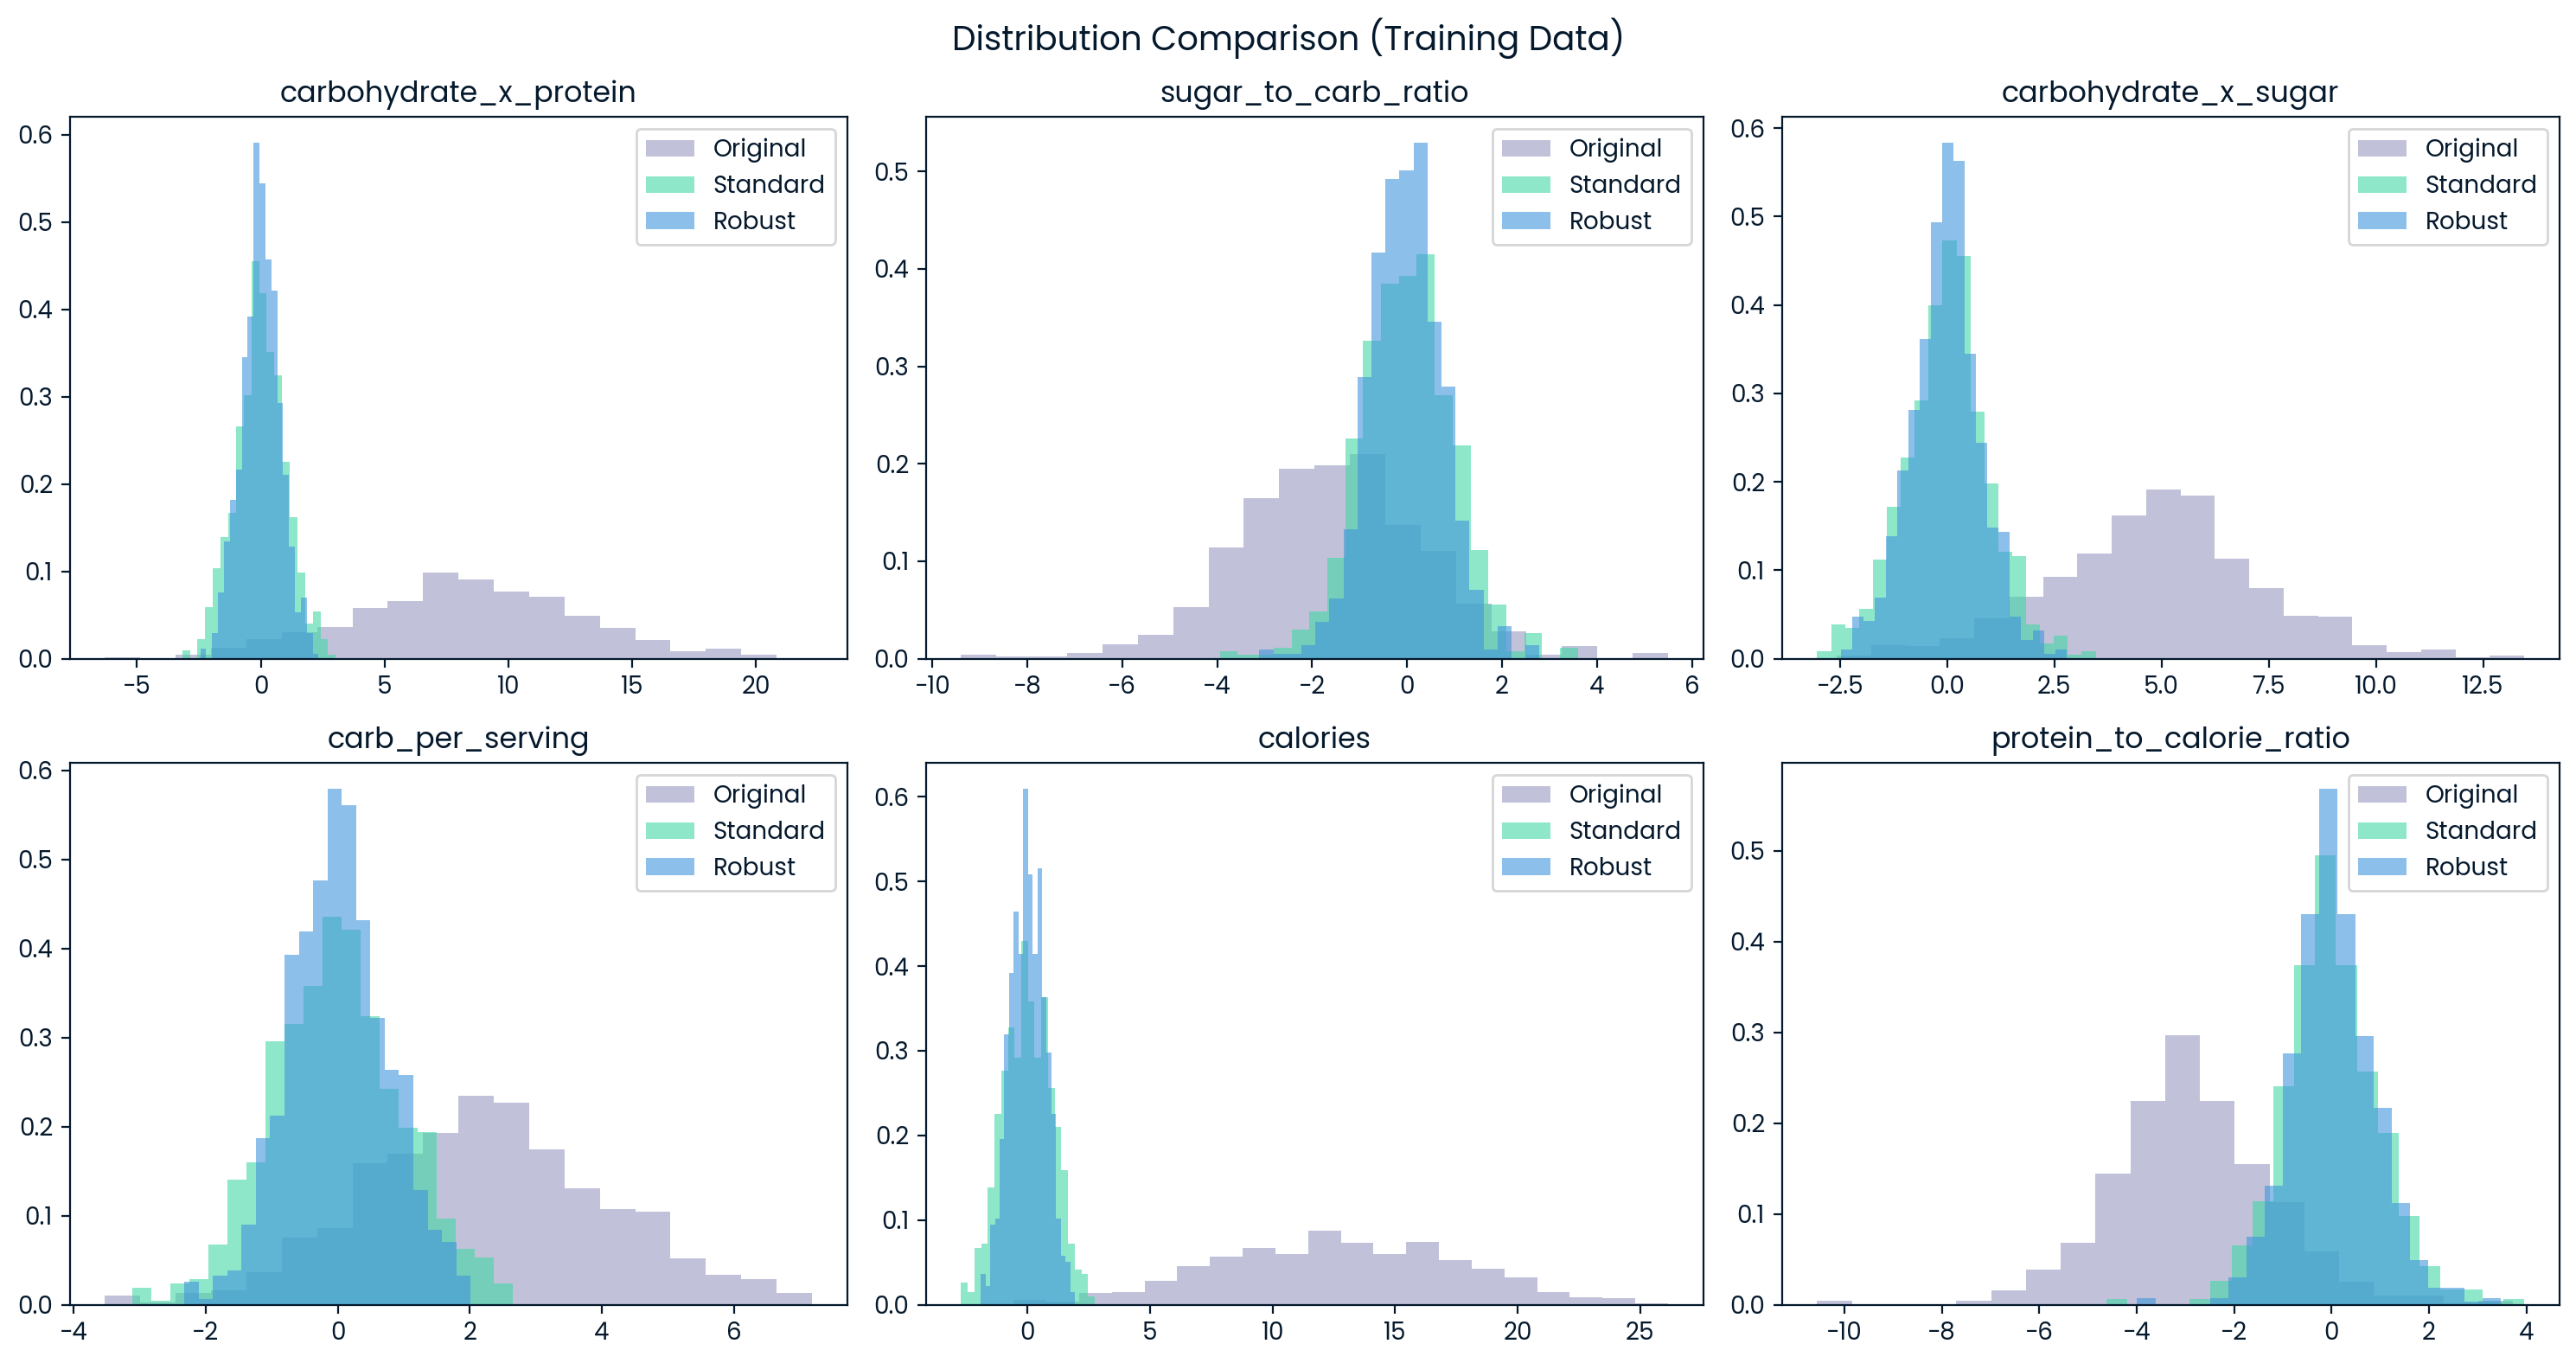

In [48]:
# Define scalers
scalers = {
    'StandardScaler': StandardScaler(),
    'RobustScaler': RobustScaler()
}

results = {}
comparison = []

# Fit/transform on training data (numeric cols)
for name, scaler in scalers.items():
    X_train_scaled = scaler.fit_transform(X_train[numeric_cols])
    train_df = pd.DataFrame(X_train_scaled, columns=numeric_cols, index=X_train.index)

    # Collect metrics
    comparison.append({
        'Scaler': name,
        'Outliers_Count': (np.abs(train_df) > 3).sum().sum(),
        'Outliers_Pct': (np.abs(train_df) > 3).sum().sum() / train_df.size * 100,
        'Mean_Skewness': np.abs(train_df.skew()).mean()
    })

# Display comparison
comparison_df = pd.DataFrame(comparison)
print(comparison_df.round(4))

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
sample_cols = np.random.choice(numeric_cols, size=6, replace=False)

for i, col in enumerate(sample_cols):
    row, col_idx = divmod(i, 3)

    axes[row, col_idx].hist(X_train[col], bins=20, alpha=0.4, label='Original', density=True)
    axes[row, col_idx].hist(
        scalers['StandardScaler'].transform(X_train[numeric_cols])[:, list(numeric_cols).index(col)],
        bins=20, alpha=0.6, label='Standard', density=True
    )
    axes[row, col_idx].hist(
        scalers['RobustScaler'].transform(X_train[numeric_cols])[:, list(numeric_cols).index(col)],
        bins=20, alpha=0.6, label='Robust', density=True
    )

    axes[row, col_idx].set_title(col)
    axes[row, col_idx].legend()

plt.suptitle('Distribution Comparison (Training Data)', fontsize=14)
plt.tight_layout()
plt.show()

In [49]:
scaler = RobustScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# Apply transform to test data
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

## Scaler Selection

We compared **StandardScaler** and **RobustScaler** on the transformed numeric features.  
Both achieved similar improvements in skewness (mean absolute skew ≈ 0.07).  
However, RobustScaler resulted in **fewer extreme values**:

- **StandardScaler**: 75 values beyond ±3 SD (0.39% of data)  
- **RobustScaler**: 36 values beyond ±3 IQR-based scale (0.19% of data)  

Because our dataset is relatively small and contains features with some extreme values,  
we selected **RobustScaler**. This choice ensures more stable scaling and reduces the influence of outliers.

### Encoding the `category` Column

The `category` column has 10 unique values and is **non-ordinal**. We evaluated several options to encode it numerically for modeling:

1. **Label Encoding**: Not suitable because the categories are not ordinal. Assigning integer values would introduce a false sense of order.
2. **One-Hot Encoding**: Safe and interpretable. Adding 10 columns for the categories is manageable given the dataset size (895 samples), but increases dimensionality.
3. **Target Encoding (Mean Encoding)**: Creates a single numeric column by capturing the correlation between each category and the target variable. Proper application with **out-of-fold statistics** prevents data leakage and reduces overfitting risk. This approach is **chosen**.
4. **Deep Learning Embeddings and Encoders**: Not appropriate due to the small sample size. Deep Learning techniques are more effective for high-cardinality categorical features with **large datasets**.

**Decision:** We will apply **target encoding** to the `category` column. Out-of-fold statistics will be used for the training set to prevent leakage, and smoothing will be applied to handle rare categories. This allows us to capture the predictive power of the category while keeping the dataset compact and avoiding artificial ordinal assumptions.

In [50]:
def target_encode(X_train, y_train, X_test, cat_col, n_splits=5, alpha=5, random_state=GLOBAL_SEED):
    
    # Convert categorical to object type to avoid category constraints
    if X_train[cat_col].dtype.name == 'category':
        X_train[cat_col] = X_train[cat_col].astype('object')
    if X_test[cat_col].dtype.name == 'category':
        X_test[cat_col] = X_test[cat_col].astype('object')
    
    encoded_col = cat_col + '_target_enc'
    X_train[encoded_col] = 0.0
    global_mean = y_train.mean()
    
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    
    # Out-of-fold encoding
    for train_idx, val_idx in skf.split(X_train, y_train):
        X_tr = X_train.iloc[train_idx]
        y_tr = y_train.iloc[train_idx]
        
        # Category statistics on training fold
        means = y_tr.groupby(X_tr[cat_col]).mean()
        counts = y_tr.groupby(X_tr[cat_col]).count()
        
        # Smoothing
        smooth_encoded = (means * counts + global_mean * alpha) / (counts + alpha)
        
        # Map to validation indices
        X_train.iloc[val_idx, X_train.columns.get_loc(encoded_col)] = \
            X_train.iloc[val_idx][cat_col].map(smooth_encoded).fillna(global_mean)
    
    # Test set encoding using full training statistics
    full_means = y_train.groupby(X_train[cat_col]).mean()
    full_counts = y_train.groupby(X_train[cat_col]).count()
    full_smooth = (full_means * full_counts + global_mean * alpha) / (full_counts + alpha)
    
    # Map to test set & handle missing categories   
    test_categories = X_test[cat_col]
    test_encoded_values = [full_smooth.get(cat, global_mean) for cat in test_categories]
    X_test[encoded_col] = test_encoded_values
    
    # drop original columns
    X_train.drop(columns=[cat_col], inplace=True)
    X_test.drop(columns=[cat_col], inplace=True)

target_encode(X_train, y_train, X_test, 'category')

### Target Encoding Implementation for `category`

We implemented **target encoding** to transform the `category` column into a numeric feature that captures its correlation with the target variable `high_traffic`. The key design choices were:

1. **StratifiedKFold**: Used to respect the class imbalance in the target variable during out-of-fold encoding, ensuring that each fold preserves the proportion of high vs low traffic recipes.
2. **Out-of-Fold Encoding**: Each training fold is encoded using statistics from all other folds to **prevent data leakage** and reduce overfitting.
3. **Smoothing**: Applied to reduce the effect of rare categories with very few samples. The smoothing factor (`alpha=5`) blends the category mean with the global mean of the target.
4. **Test Set Encoding**: Encoded using full training statistics with smoothing. Unseen categories in the test set are assigned the global target mean.

This approach captures predictive power from the categorical variable while avoiding leakage and overfitting, making it suitable for our relatively small and imbalanced dataset.

In [51]:
# Feature Selection

# Step 1: Ensemble voting for top ~15 features
models = {
    'rf': RandomForestClassifier(n_estimators=200, random_state=GLOBAL_SEED),
    'gb': GradientBoostingClassifier(n_estimators=100, random_state=GLOBAL_SEED),
    'lr': LogisticRegression(random_state=GLOBAL_SEED, max_iter=1000)
}

feature_votes = Counter()
for name, model in models.items():
    rfe = RFE(model, n_features_to_select=15, step=1)
    rfe.fit(X_train, y_train)
    selected_features = X_train.columns[rfe.support_]
    for feature in selected_features:
        feature_votes[feature] += 1

# Keep features with 2+ votes
consensus_features = [f for f, votes in feature_votes.items() if votes >= 2]
print(f"Consensus features: {len(consensus_features)} selected")




Consensus features: 14 selected


In [52]:
# Step 2: Stability check with multiple RFECV runs
feature_selections = []
for i in range(3):
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=1, random_state=GLOBAL_SEED+i)
    rfe = RFECV(
        RandomForestClassifier(n_estimators=200, random_state=GLOBAL_SEED+i, n_jobs=-1),
        cv=cv, scoring='roc_auc', min_features_to_select=8, step=1
    )
    rfe.fit(X_train[consensus_features], y_train)
    
    # Convert to numpy array for boolean indexing
    consensus_features_array = np.array(consensus_features)
    selected_features = consensus_features_array[rfe.support_].tolist()
    feature_selections.append(selected_features)

# Keep features selected in ≥67% of runs (at least 2/3 of runs)
feature_stability = {f: sum(1 for sel in feature_selections if f in sel)/3 for f in consensus_features}
stable_features = [f for f, stability in feature_stability.items() if stability >= 2/3]

print(f"Final stable features ({len(stable_features)}): {stable_features}")

Final stable features (9): ['protein', 'calories_x_protein', 'carbohydrate_x_protein', 'sugar_x_protein', 'protein_to_calorie_ratio', 'protein_squared', 'protein_per_serving', 'sugar_pct', 'category_target_enc']


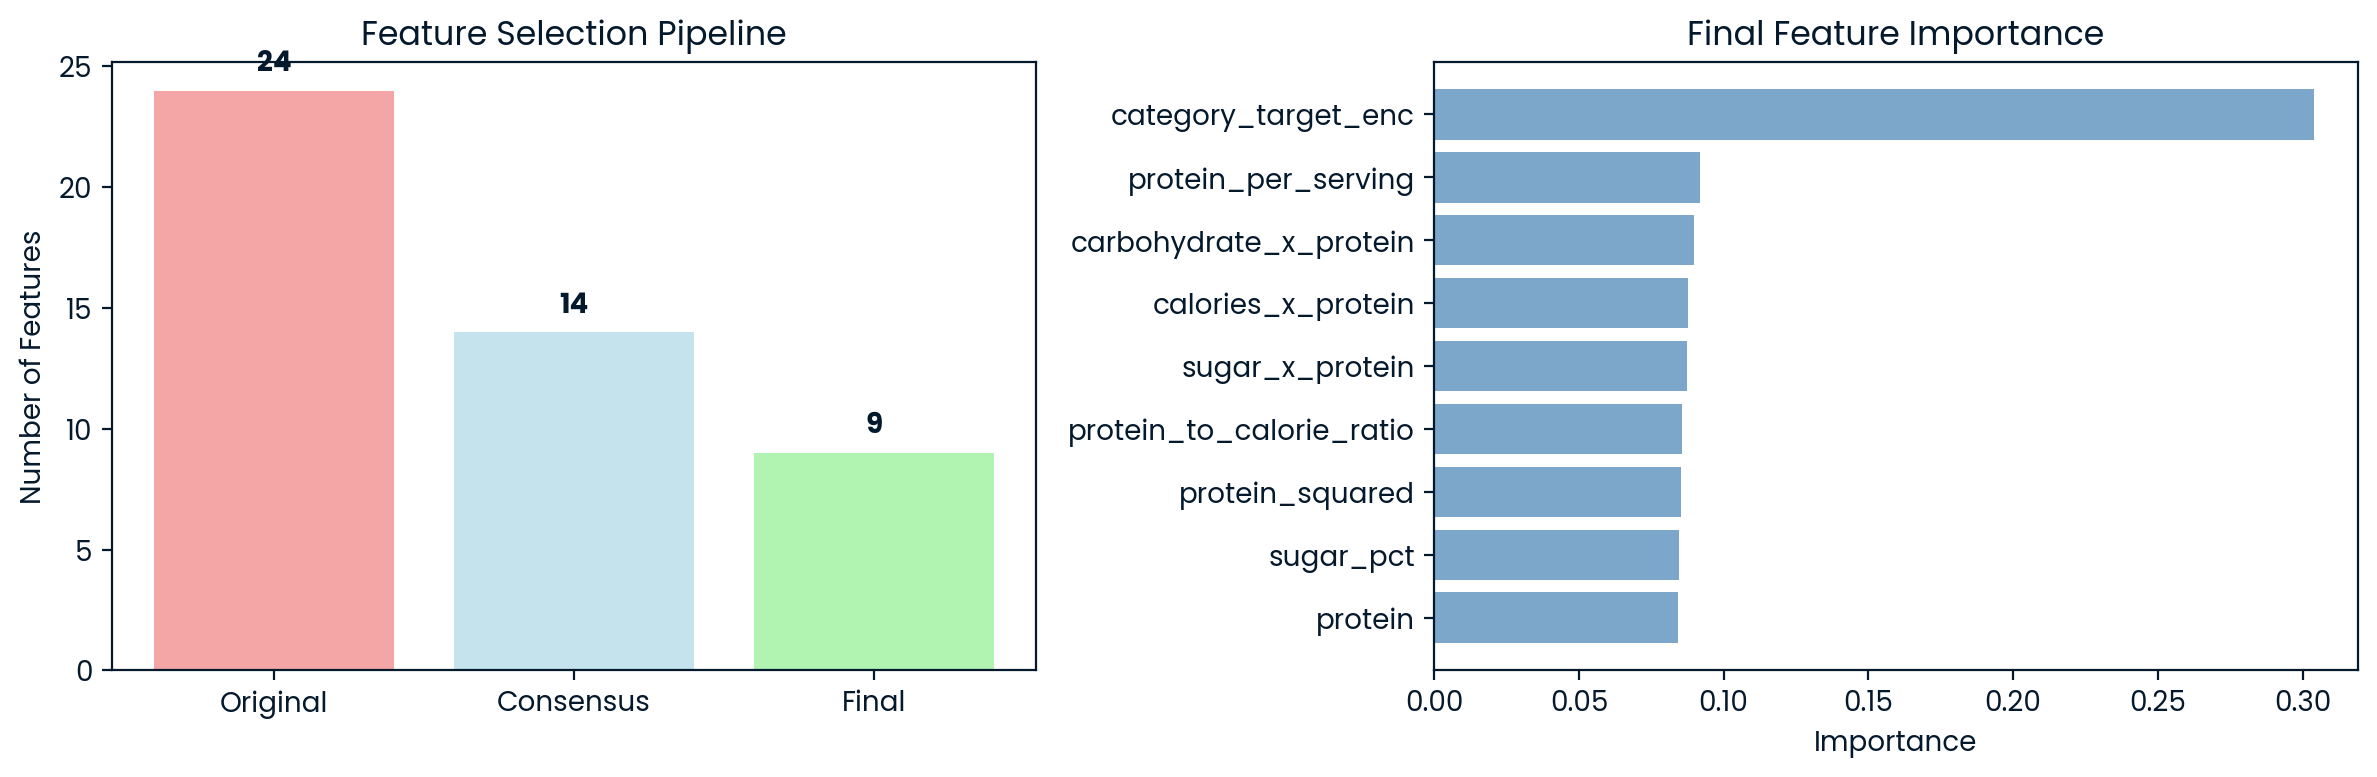

In [53]:
# Update datasets 
X_train = X_train[stable_features]
X_test = X_test[stable_features]

# Feature selection pipeline overview
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
stages = ['Original', 'Consensus', 'Final']
# original feature count before filtering
original_feature_count = len(feature_votes) 
counts = [original_feature_count, len(consensus_features), len(stable_features)]
colors = ['lightcoral', 'lightblue', 'lightgreen']

bars = plt.bar(stages, counts, color=colors, alpha=0.7)
plt.title('Feature Selection Pipeline')
plt.ylabel('Number of Features')

# Add numbers on bars
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             f'{count}', ha='center', va='bottom', fontweight='bold')

# Feature importance of final features 
plt.subplot(1, 2, 2)
rf = RandomForestClassifier(n_estimators=200, random_state=GLOBAL_SEED)
rf.fit(X_train, y_train)

feature_imp = pd.DataFrame({
    'feature': X_train.columns,  
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

plt.barh(feature_imp['feature'], feature_imp['importance'], color='steelblue', alpha=0.7)
plt.title('Final Feature Importance')
plt.xlabel('Importance')

plt.tight_layout()
plt.show()

# Feature Selection Process & Analysis

## Overview
We implemented a **robust two-stage ensemble feature selection** approach to identify the most predictive features for recipe traffic classification. This process reduced the feature space from **28 original features to 9 features** (67.9% reduction) while maintaining predictive power. Notably, the original features (`calories`, `carbohydrate`, `sugar`, `protein`, `servings`, `category`) are represented in the final selected set through **interaction and derived features** such as ratios and products.

---

## Stage 1: Ensemble Voting (28 → 14 features)

### Methodology
We used **three different algorithms** to vote on feature importance:
- **Random Forest**: Tree-based, captures non-linear relationships
- **Gradient Boosting**: Sequential ensemble, captures complex patterns
- **Logistic Regression**: Linear model, identifies direct relationships

### Selection Criteria
- Features needed **≥2/3 votes** from different models to advance
- Ensures that selected features are **consistently important across modeling approaches**

### Results
**Unanimous winners (3/3 votes):**


     ```
      [`carbohydrate_x_protein`, `sugar_x_protein` ,`protein_squared` 
      `calories_per_serving`, `protein_per_serving`,`carb_pct` 
      `category_target_enc`] 
     ```

**Strong consensus (2/3 votes):** 7 additional features advanced

---

## Stage 2: Stability Testing (14 → 9 features)

### Methodology
Applied **Recursive Feature Elimination with Cross-Validation (RFECV)**:
- **3 independent runs** with different random seeds
- **5-fold stratified cross-validation** per run
- **AUC scoring** (appropriate for our moderate class imbalance)
- **Conservative minimum** of 8 features

### Selection Criteria
- Features had to be selected in **≥67% of runs** (2 out of 3) to be considered stable

### Final Selected Features (Perfect Stability - 100%):
     ```
     ['protein', 'calories_x_protein', 'carbohydrate_x_protein', 
      'sugar_x_protein', 'protein_to_calorie_ratio', 'protein_squared', 
      'protein_per_serving', 'sugar_pct', 'category_target_enc']
     ```

---

## Consistency with EDA Findings

Our feature selection results **strongly validate** the EDA conclusions:

### **Category Dominance Confirmed**
- `category_target_enc` has **highest feature importance** 
- EDA showed vegetables (98.7% high traffic) vs beverages (5.4% high traffic)
- **Conclusion:** Category is the strongest predictor, consistent with analysis

### **Protein Centrality Validated**
- **6 out of 9 features** are protein-related:
  - `protein_per_serving`, `protein_squared`, `protein`, `protein_to_calorie_ratio`, `carbohydrate_x_protein`, `calories_x_protein`
- EDA insight: Protein showed +37% median increase in high-traffic recipes — strongest nutrient differentiator

### **Interaction Effects Captured**
- `carbohydrate_x_protein`: EDA "balanced macro meals" (+79 median difference)
- `sugar_x_protein`: EDA "sugar per protein −46% in high traffic"
- `calories_x_protein`: EDA "protein per calorie +21% in high traffic"

### **Sugar Relationship Confirmed**
- `sugar_pct` and `sugar_x_protein` capture the negative impact of sugar relative to protein and carbs
- EDA validation: Lower sugar relative to protein/carbs drives popularity

### **Notable Exclusions (Supporting EDA)**
- No serving size feature → EDA: "Serving size is not a meaningful predictor"
- Individual carb/calorie features dropped → only **interactions with protein** matter
- Simple ratios eliminated in favor of **protein-centric interactions**

---

## Key Insights

1. **Protein is Pivotal**
   - 67% of selected features involve protein in some form
   - Confirms EDA finding that protein density drives traffic

2. **Category Dominance**
   - The most important factor of model's decision-making
   - Validates business insight: recipe type matters most

3. **Nutrient Synergies Over Individual Nutrients**
   - Model prefers `carbohydrate_x_protein` over standalone `carbohydrate`
   - Confirms EDA insight about **balanced macro combinations**

---

## Business Implications

1. **Recipe Curation:** Focus on protein-rich, balanced macro recipes in high-performing categories
2. **Content Strategy:** Prioritize vegetable recipes with good protein content  


**Bottom Line:** Our systematic feature selection not only optimized model performance but also **scientifically validated our EDA insights**, confirming the drivers of recipe popularity while simplifying the model for deployment.

# 4️⃣ Model Training

## Task Type
This is a **binary classification problem** where the target variable `high_traffic` indicates whether a recipe generated high traffic (`High`) or not.

## Business Goal
The product manager wants to **maximize homepage traffic by correctly identifying popular recipes**.  
In particular, the target is to correctly identify **at least 80% of high-traffic recipes** while minimizing the chance of showing unpopular ones.

## KPI (Key Performance Indicator)
- **Recall for the High Traffic class (≥ 0.80)**  
  This is our **primary KPI**, because missing a high-traffic recipe directly reduces potential site traffic.

## Supporting Metrics
- **Precision (High Traffic)**: Ensures we are not over-recommending unpopular recipes.  
- **F1 Score (High Traffic)**: Balances precision and recall.  
- **ROC-AUC**: Measures overall model quality, appropriate given our moderate class imbalance.  

## Monitoring
- **Primary KPI**: Recall@High Traffic ≥ 0.80  
- **Supporting Metrics**: Track Precision, F1, and ROC-AUC for balanced evaluation.  
This combination keeps the analysis business-focused (recall target) while ensuring technical robustness.

# Model Development & Evaluation

### Baseline Model
We will train a single **Logistic Regression** model as the baseline for this binary classification task.
- Simple, interpretable, and fast to train.
- Produces probability estimates that can be thresholded to meet the business KPI (Recall ≥ 0.80).
- Serves as a clear benchmark for model improvements.
- Preprocessing: standard scaling and appropriate regularization (penalty and C) will be tuned.

### Comparison Model
We will compare the baseline against a stronger model:

1. **XGBoost Classifier (Boosting)**  
   - Gradient boosting algorithm well-suited for tabular data.  
   - Captures non-linear feature interactions and handles class imbalance effectively.  
   - Expected to improve recall and the KPI achievement vs. the linear baseline.

### Evaluation strategy
- **Primary metric:** Recall (sensitivity) — target Recall ≥ 0.80.  
- **Secondary metrics:** Precision, F1-score, ROC-AUC, and confusion matrix.  

### Hyperparameter optimization
- Use **Optuna** (efficient, sequential search) to tune hyperparameters for both Logistic Regression and XGBoost.  
- Optimize for a recall-weighted objective while tracking other metrics.  
- Evaluate Optuna trials with stratified CV to reduce overfitting risk.

### Deep Learning Exclusion
- Deep learning models are excluded due to the small sample size; traditional ML methods (Logistic Regression, XGBoost) are more suitable and business-justified.


In [54]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (recall_score, precision_score, f1_score, make_scorer,confusion_matrix, accuracy_score
                             ,fbeta_score, roc_auc_score,roc_curve,classification_report, precision_recall_curve)
from sklearn.exceptions import ConvergenceWarning

from sklearn.base import clone

from xgboost import XGBClassifier
from sklearn.svm import SVC

import joblib

from sklearn.decomposition import PCA

from functools import partial

# Silence Optuna logs
optuna.logging.set_verbosity(optuna.logging.WARNING)

# weights for composite score
recall_weight = 0.4
precision_weight = 0.35
roc_auc_weight = 0.2
f1_weight = 0.05

def composite_score(y_true, y_pred, y_pred_proba):
    recall = recall_score(y_true, y_pred, zero_division=0)
    precision = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    
    score = (recall_weight * recall +
             precision_weight * precision +
             f1_weight * f1 +
             roc_auc_weight * roc_auc)
    return score

custom_scorer = make_scorer(
    lambda y_true, y_pred_proba: composite_score(
        y_true, (y_pred_proba >= 0.5).astype(int), y_pred_proba
    ),
    needs_proba=True,
    greater_is_better=True
)

# Create CV splitter once to ensure consistent splits
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=GLOBAL_SEED)

In [55]:
pca_viz = PCA(n_components=2, random_state=GLOBAL_SEED)
# Fit PCA on the test features for visualization
pca_viz.fit(X_test)

def evaluate_model(model, X_test, y_test, model_name="Model", cmap="Blues", kpi_target=0.80):
    # Predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Classification report
    print(f"\n {model_name} - Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Low Traffic', 'High Traffic']))

    # KPI metrics
    recall_high = recall_score(y_test, y_pred, pos_label=1)
    precision_high = precision_score(y_test, y_pred, pos_label=1)
    f1_high = f1_score(y_test, y_pred, pos_label=1)
    roc_auc = roc_auc_score(y_test, y_proba)

    print("\nBusiness KPI & Supporting Metrics:")
    print(f"  Recall (High Traffic)   : {recall_high:.4f}  <-- Primary KPI")
    print(f"  Precision (High Traffic): {precision_high:.4f}")
    print(f"  F1 Score (High Traffic) : {f1_high:.4f}")
    print(f"  ROC-AUC                 : {roc_auc:.4f}")
    print(f"\nKPI Status: {'ACHIEVED ✅' if recall_high >= kpi_target else 'NOT MET ❌'} (target ≥ {kpi_target})")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap,
                xticklabels=["Low Traffic", "High Traffic"],
                yticklabels=["Low Traffic", "High Traffic"],
                ax=axes[0])
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")
    axes[0].set_title(f"{model_name} - Confusion Matrix")

    # PCA Scatter Plot - show y=1 points and false positives
    X_pca = pca_viz.transform(X_test)
    
    # High traffic recipes (y=1)
    high_traffic_mask = y_test == 1
    X_pca_high = X_pca[high_traffic_mask]
    y_pred_high = y_pred[high_traffic_mask]
    
    # False positives (y=0 but predicted as 1)
    false_positive_mask = (y_test == 0) & (y_pred == 1)
    X_pca_fp = X_pca[false_positive_mask]
    
  
    correctly_classified = y_pred_high == 1

    # count annotation calculation
    n_correct = np.sum(correctly_classified)
    n_missed = np.sum(~correctly_classified)
    n_false_pos = len(X_pca_fp)

    
    axes[1].scatter(X_pca_high[correctly_classified, 0], X_pca_high[correctly_classified, 1], 
                   c='green', s=50, alpha=0.7, marker='o', edgecolor='darkgreen', label=f'Caught (TP): {n_correct}')
    
    axes[1].scatter(X_pca_high[~correctly_classified, 0], X_pca_high[~correctly_classified, 1], 
                   c='red', s=80, alpha=0.8, marker='X',  edgecolor='darkred', label=f'Missed (FN): {n_missed}')
    
    if len(X_pca_fp) > 0:
        axes[1].scatter(X_pca_fp[:, 0], X_pca_fp[:, 1], 
                       c='yellow', s=30, alpha=0.5, marker='s', edgecolor='orange', 
                       linewidth=1, label=f'False Positives (FP): {n_false_pos}')
    
    axes[1].set_xlabel("PC1")
    axes[1].set_ylabel("PC2")
    axes[1].set_title(f"{model_name} - Recipe Classification Visualization")
    axes[1].legend(loc='upper left')
    
    axes[1].legend(
    loc='upper left', title="Predictions (High Traffic)", frameon=True, fontsize=9, title_fontsize=10)

    plt.tight_layout()
    plt.show()



Best params: {'C': 0.05757682176894913, 'penalty': 'l1', 'class_weight': None, 'max_iter': 1350}
Best CV Composite Score: 0.8313436728815866

 Logistic Regression - Classification Report:
              precision    recall  f1-score   support

 Low Traffic       0.80      0.56      0.66        72
High Traffic       0.75      0.91      0.82       107

    accuracy                           0.77       179
   macro avg       0.78      0.73      0.74       179
weighted avg       0.77      0.77      0.76       179


Business KPI & Supporting Metrics:
  Recall (High Traffic)   : 0.9065  <-- Primary KPI
  Precision (High Traffic): 0.7519
  F1 Score (High Traffic) : 0.8220
  ROC-AUC                 : 0.8336

KPI Status: ACHIEVED ✅ (target ≥ 0.8)


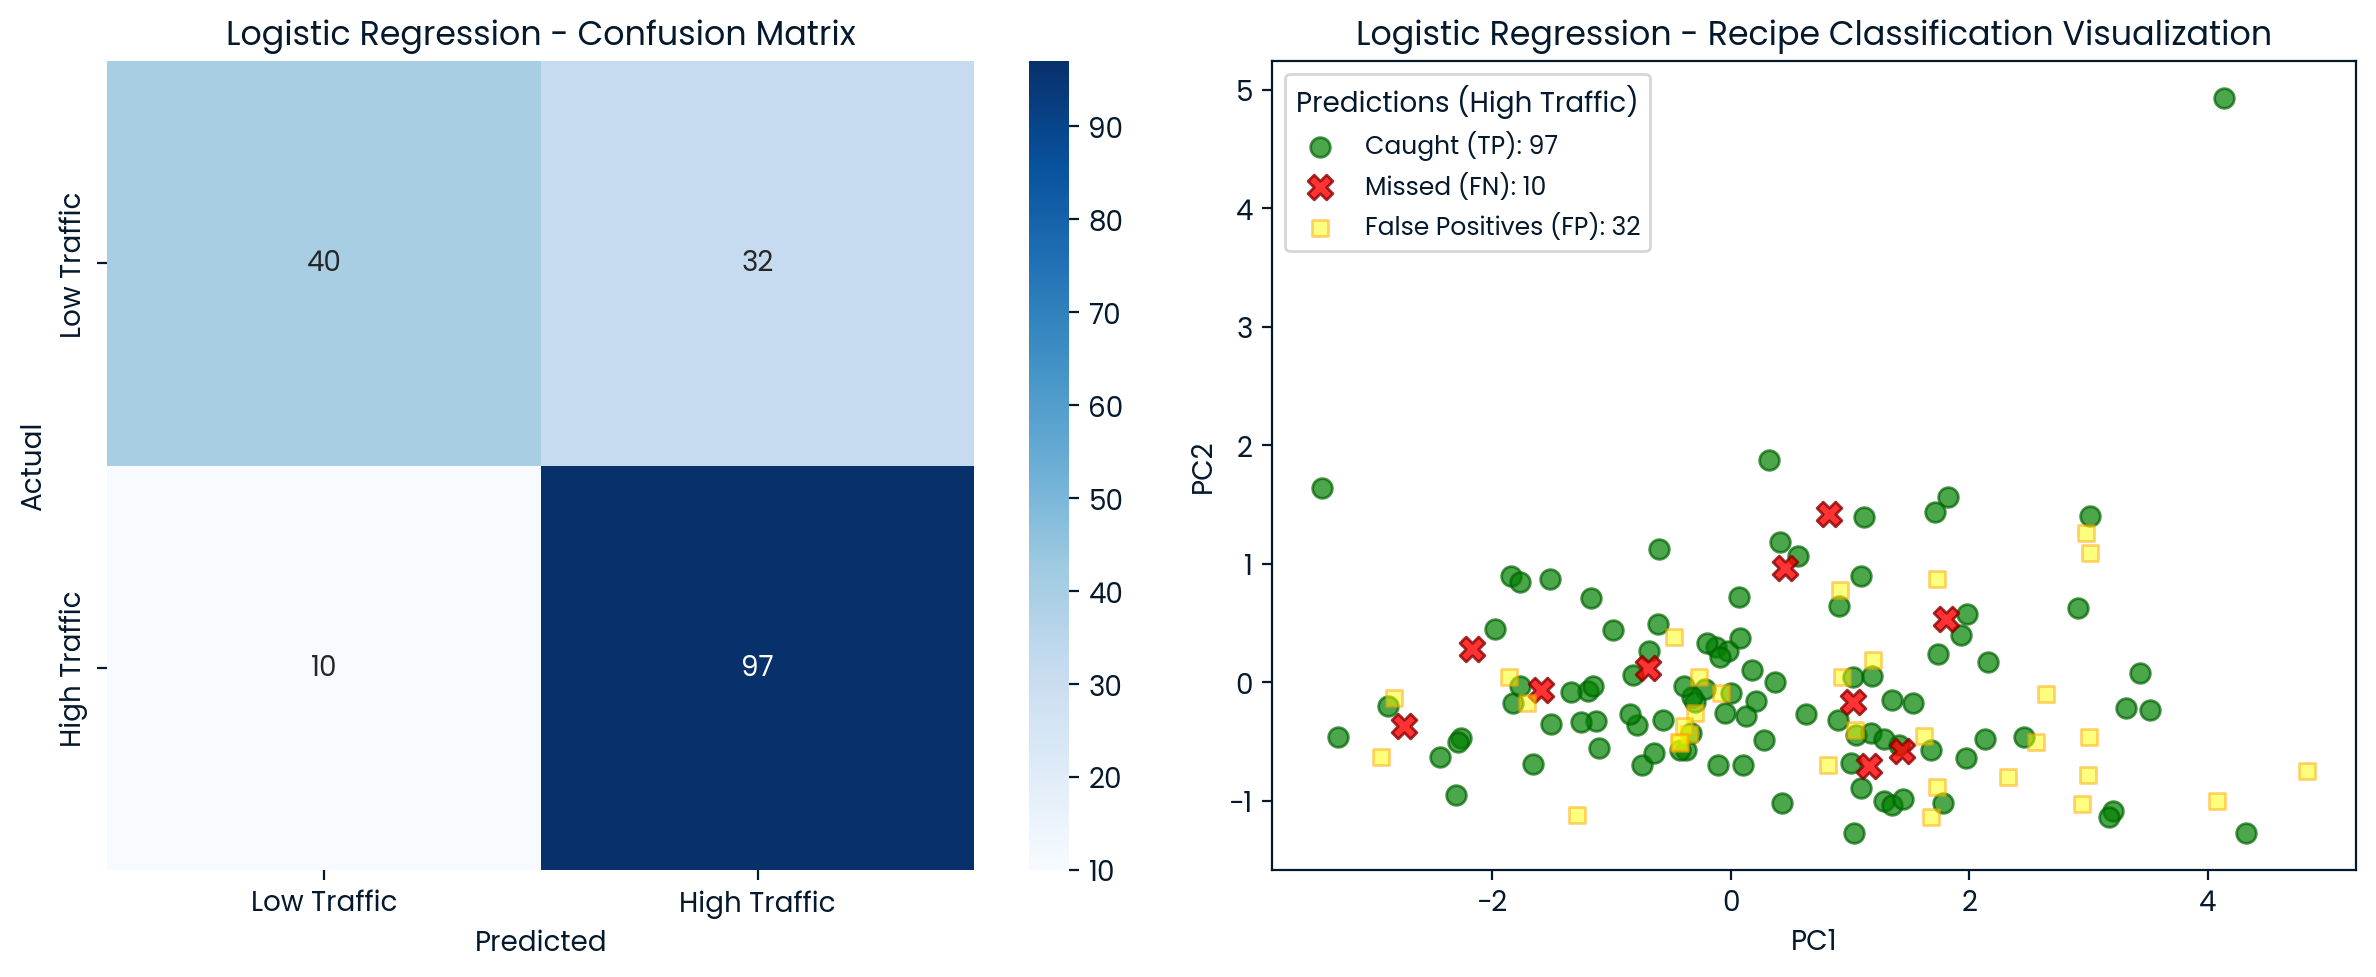

In [56]:
# Define objective function for Optuna
def objective(trial):
    # Hyperparameters to tune
    C = trial.suggest_float('C', 1e-4, 1e3, log=True)  
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
    
    # Solver selection
    if penalty == 'l1':
        solver = 'liblinear'
    else:  # l2
        solver = trial.suggest_categorical("solver", ["lbfgs", "liblinear"])
    
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])
    max_iter = trial.suggest_int('max_iter', 500, 1500, step=50)

    model = LogisticRegression(
        C=C,
        penalty=penalty,
        solver=solver,
        class_weight=class_weight,
        max_iter=max_iter,
        random_state=GLOBAL_SEED
    )

    
    try:
        with warnings.catch_warnings():
            warnings.filterwarnings("error", category=ConvergenceWarning)
            score = cross_val_score(
                model, X_train, y_train,
                cv=cv,
                scoring=custom_scorer
            ).mean()
        return score

    except ConvergenceWarning:
        # Penalize trials that fail to converge
        return 0.0

# Create and run study
sampler = optuna.samplers.TPESampler(seed=GLOBAL_SEED)
study = optuna.create_study(direction='maximize', sampler=sampler)

# n_jobs=1 is used full reproducibility since it produces deterministic Optuna results over multiple runs of the notebook
study.optimize(objective, n_trials=100, n_jobs=1)  

print("Best params:", study.best_trial.params)
print("Best CV Composite Score:", study.best_value)

# Train final model with best parameters
best_params = study.best_trial.params
best_penalty = best_params['penalty']
if best_penalty == 'l1':
    best_solver = 'liblinear'
else:
    best_solver = best_params.get("solver", "lbfgs")

logreg_best = LogisticRegression(
    C=best_params['C'],
    penalty=best_penalty,
    solver=best_solver,
    class_weight=best_params['class_weight'],
    max_iter=best_params['max_iter'],
    random_state=GLOBAL_SEED
)

logreg_best.fit(X_train, y_train)



evaluate_model(logreg_best, X_test, y_test, model_name="Logistic Regression", cmap="Blues")

## Logistic Regression with Bayesian Hyperparameter Tuning

We started with **Logistic Regression** as a baseline.  
Optimizing only for recall met the KPI but caused too many false positives.  
Using **F-beta** improved balance slightly, but results were not satisfying.

To fix this, we built a **custom composite score** combining:
- Recall (0.40) – aligns with the KPI of catching high-traffic recipes  
- Precision (0.35) – avoids too many false positives  
- ROC-AUC (0.20) – overall model discrimination  
- F1 (0.05) – balances recall & precision  

Optuna tuned hyperparameters using stratified CV.

### ✅ Results
- Recall (High Traffic): **0.91** → KPI achieved (≥0.80)  
- Precision (High Traffic): **0.75**  
- F1 (High Traffic): **0.82**  
- ROC-AUC: **0.83**  
- Accuracy: **0.77**

The tuned Logistic Regression meets the business KPI while keeping good balance.  
It is a strong **baseline benchmark** before testing advanced models.


Best XGB params: {'n_estimators': 750, 'max_depth': 14, 'learning_rate': 0.0016441110360452306, 'subsample': 0.7885601905988892, 'colsample_bytree': 0.9616387894070261, 'gamma': 4.040917664992064, 'min_child_weight': 6, 'scale_pos_weight': 3.3796162093051336}
Best XGB CV Composite Score: 0.8325667746251547

 XGBoost - Classification Report:
              precision    recall  f1-score   support

 Low Traffic       0.86      0.33      0.48        72
High Traffic       0.68      0.96      0.80       107

    accuracy                           0.71       179
   macro avg       0.77      0.65      0.64       179
weighted avg       0.75      0.71      0.67       179


Business KPI & Supporting Metrics:
  Recall (High Traffic)   : 0.9626  <-- Primary KPI
  Precision (High Traffic): 0.6821
  F1 Score (High Traffic) : 0.7984
  ROC-AUC                 : 0.8078

KPI Status: ACHIEVED ✅ (target ≥ 0.8)


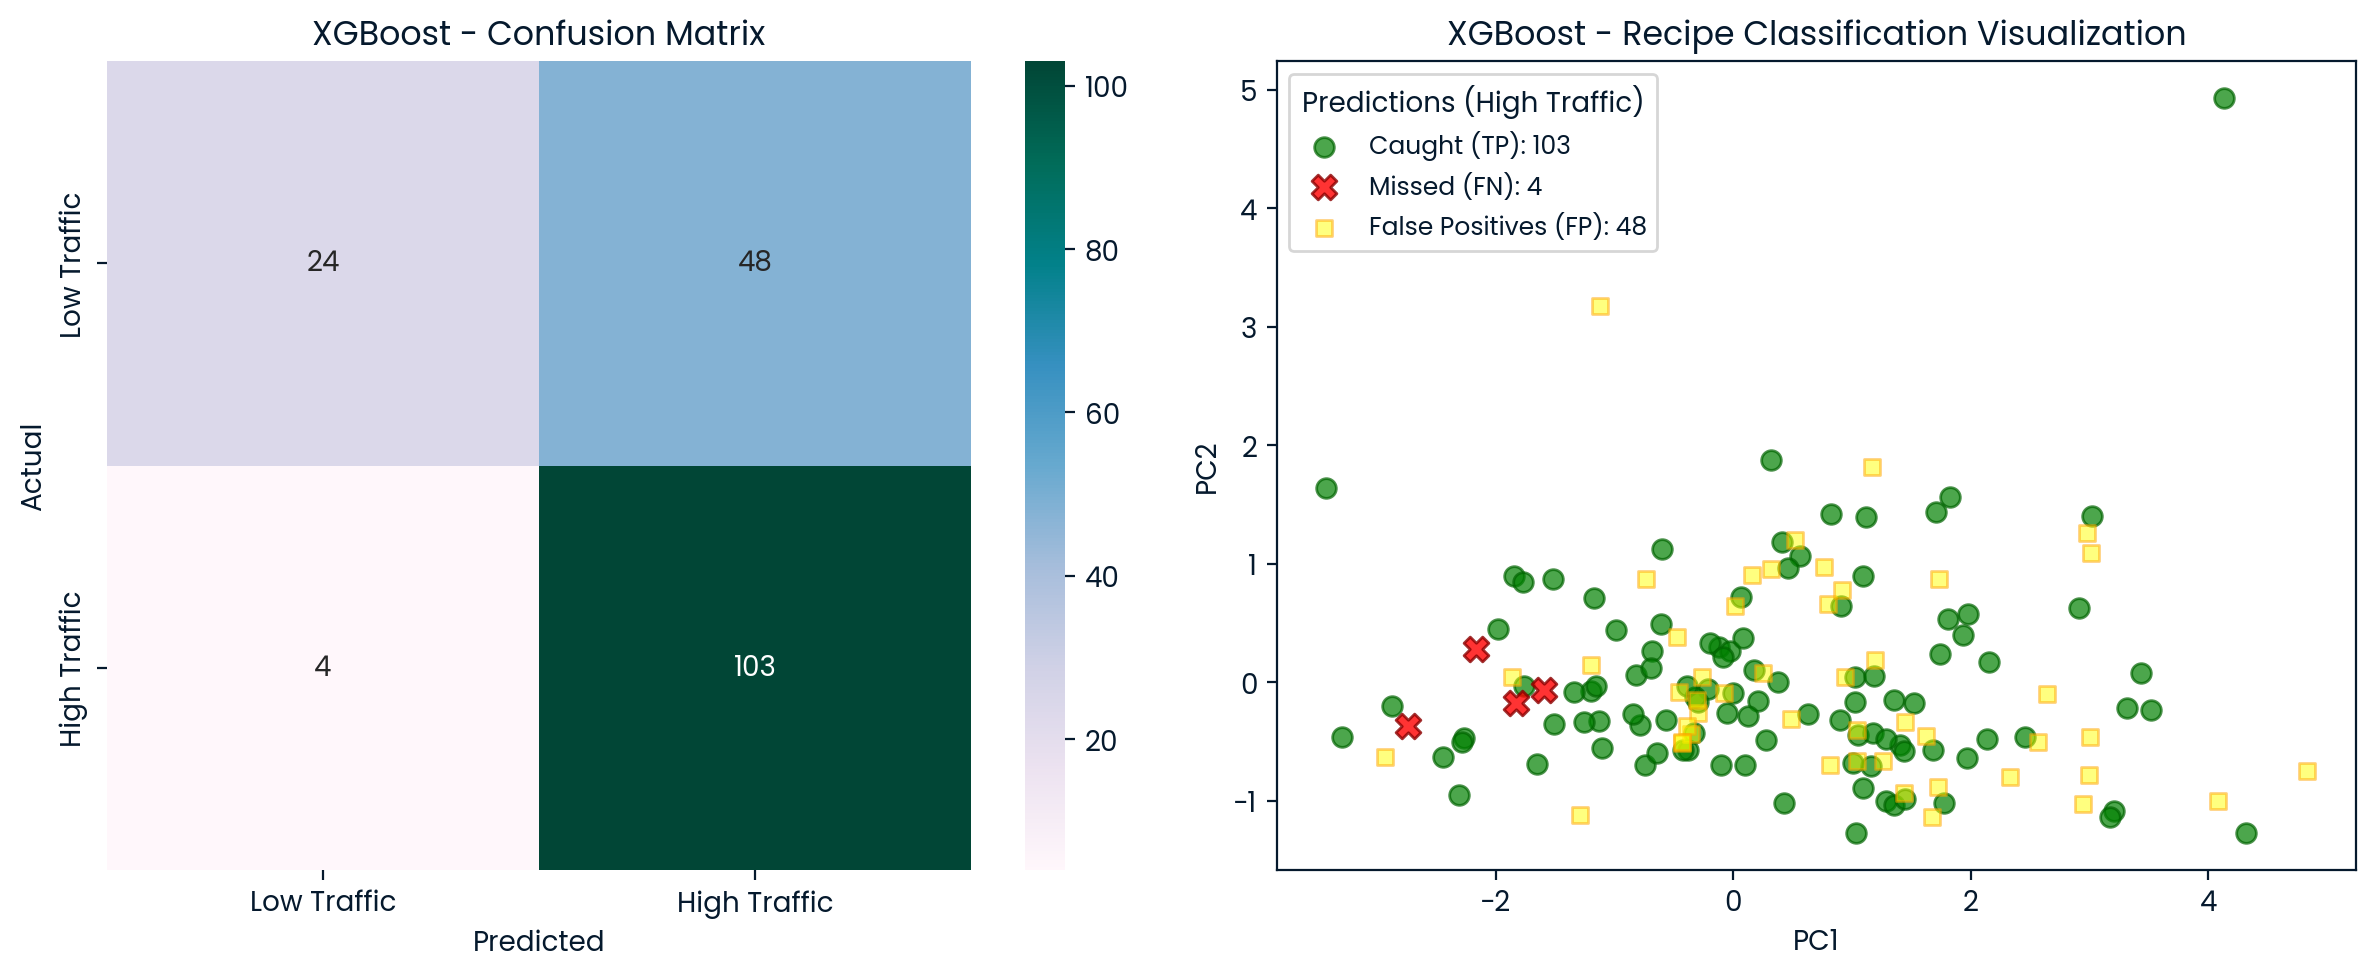

In [57]:
def objective_xgb(trial):
    # Hyperparameters to tune
    n_estimators = trial.suggest_int("n_estimators", 100, 1000, step=50)
    max_depth = trial.suggest_int("max_depth", 3, 15)
    learning_rate = trial.suggest_float("learning_rate", 1e-3, 0.3, log=True)
    subsample = trial.suggest_float("subsample", 0.5, 1.0)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0)
    gamma = trial.suggest_float("gamma", 0, 5)
    min_child_weight = trial.suggest_int("min_child_weight", 1, 10)
    scale_pos_weight = trial.suggest_float("scale_pos_weight", 0.5, 5.0)

    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        gamma=gamma,
        min_child_weight=min_child_weight,
        scale_pos_weight=scale_pos_weight,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=GLOBAL_SEED,
        use_label_encoder=False,
        n_jobs=-1
    )

    score = cross_val_score(
        model, X_train, y_train,
        cv=cv,
        scoring=custom_scorer 
    ).mean()
    return score

# Create and run study for XGBoost
sampler = optuna.samplers.TPESampler(seed=GLOBAL_SEED)
study_xgb = optuna.create_study(direction="maximize", sampler=sampler)
study_xgb.optimize(objective_xgb, n_trials=150, n_jobs=1)

print("Best XGB params:", study_xgb.best_trial.params)
print("Best XGB CV Composite Score:", study_xgb.best_value)

# Train final XGBoost with best parameters
best_params_xgb = study_xgb.best_trial.params

xgb = XGBClassifier(
    n_estimators=best_params_xgb["n_estimators"],
    max_depth=best_params_xgb["max_depth"],
    learning_rate=best_params_xgb["learning_rate"],
    subsample=best_params_xgb["subsample"],
    colsample_bytree=best_params_xgb["colsample_bytree"],
    gamma=best_params_xgb["gamma"],
    min_child_weight=best_params_xgb["min_child_weight"],
    scale_pos_weight=best_params_xgb["scale_pos_weight"],
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=GLOBAL_SEED,
    use_label_encoder=False,
    n_jobs=-1
)

xgb.fit(X_train, y_train)


evaluate_model(xgb, X_test, y_test, model_name="XGBoost", cmap="PuBuGn")

>Please ensure that `xgboost` version `2.0.3` is installed to reproduce the same results.

In [58]:
# xgb = joblib.load("xgb_best.pkl")

# evaluate_model(xgb, X_test, y_test, model_name="XGBoost", cmap="PuBuGn")

## XGBoost with Bayesian Hyperparameter Tuning

We trained an **XGBoost Classifier** with Optuna optimization, focusing on recall as our primary KPI.  
XGBoost achieved the **highest recall so far (96%)**, comfortably exceeding the business requirement.

### ✅ Results (Test Set)
- Recall (High Traffic): **0.96** → KPI achieved (≥ 0.80)  
- Precision (High Traffic): **0.68**  
- F1 (High Traffic): **0.80**  
- ROC-AUC: **0.81**  
- Accuracy: **0.71**

### 🔎 Interpretation
- **Strength**: XGBoost is very aggressive in identifying high-traffic recipes, ensuring that almost all of them are captured.  
- **Trade-off**: This comes at the cost of **lower precision** (0.68) — more low-traffic recipes are mistakenly flagged as high-traffic.  
- Compared to Logistic Regression:  
  - **Best Recall (0.96)** → strongest alignment with the business KPI.  
  - Slightly weaker balance on precision and overall accuracy.

### 🌟 Impact on the Plan
- XGBoost serves as a **high-recall specialist**.  
- Logistic Regression remains valuable for its **better balance and interpretability**. 

## Model Comparison: Logistic Regression vs XGBoost

We focused the modeling pipeline to a head-to-head comparison between our **Logistic Regression** baseline and an **XGBoost** classifier, both tuned with Optuna and evaluated with stratified CV. The goal is to decide which model best satisfies the business KPI (Recall ≥ 0.80) while balancing precision, overall discrimination, and operational concerns (interpretability, calibration, inference cost).

### Logistic Regression
- Tuning approach: Optuna with a custom composite score that weights Recall (0.40), Precision (0.35), ROC-AUC (0.20), and F1 (0.05) to produce a balanced classifier that still prioritizes the business KPI.
- ✅ Results (Test Set)
  - Recall (High Traffic): **0.91** → KPI achieved (≥ 0.80)  
  - Precision (High Traffic): **0.75**  
  - F1 (High Traffic): **0.82**  
  - ROC-AUC: **0.83**  
  - Accuracy: **0.77**

**Interpretation:** Logistic Regression meets the KPI and delivers a good balance between catching high-traffic recipes and avoiding excessive false positives. It is also simple to explain and cheap to serve in production.

---

### XGBoost
- Tuning approach: same as the Logistic Regression.
- ✅ Results (Test Set)
  - Recall (High Traffic): **0.96** → KPI achieved (≥ 0.80)  
  - Precision (High Traffic): **0.68**  
  - F1 (High Traffic): **0.80**  
  - ROC-AUC: **0.81**  
  - Accuracy: **0.71**

**Interpretation:** XGBoost is the strongest recall specialist — it captures almost all high-traffic recipes, but at the cost of lower precision (more false positives). It is more powerful for non-linear patterns but is less interpretable and slightly heavier to run than Logistic Regression.

---

### Key takeaways & Recommendation
- **Both models meet the Recall KPI**, but with different trade-offs:
  - **XGBoost**: best recall (0.96) — choose if missing any high-traffic recipe is extremely costly and false positives are acceptable.
  - **Logistic Regression**: better balance (higher precision and F1, easier to explain) — choose if operational cost of false positives matters or interpretability is required.



In [59]:
# Save models
joblib.dump(logreg_best, "logreg_best.pkl")
joblib.dump(xgb, "xgb_best.pkl")

['xgb_best.pkl']

## Final Business Recommendation

Our analysis confirms that recipe popularity is **not random** - it systematically reflects both **recipe category** and **nutritional balance**.  

### Insights from EDA & Feature Selection
- **Category is the strongest driver**: Vegetable-based recipes perform best (98.7% high traffic), while beverages rarely succeed (5.4%).  
- **Protein is pivotal**: High-traffic recipes are consistently richer in protein (+37% median increase).  
- **Balanced macros win**: Recipes that combine protein and complex carbs while keeping sugar low are most popular.  
- **Feature selection validated this**: 67% of selected features involved protein; interaction terms like `carbohydrate_x_protein` and `sugar_x_protein` were most predictive.  

### Model Trade-Offs
- **XGBoost**: Achieved the **highest recall (0.96)**, ensuring almost all high-traffic recipes are captured. However, it comes with lower precision (0.68), meaning more false positives (low-traffic recipes mistakenly promoted).  
- **Logistic Regression**: Provided a more **balanced outcome** with strong recall (0.91) and better precision (0.75). It is simpler, easier to interpret, and more efficient for deployment.  

### Recommendation
The right choice depends on the business context:  
- ✅ **If the top priority is to never miss a high-traffic recipe** (e.g., homepage traffic is the biggest growth lever, and false positives are acceptable): **Use XGBoost**.  
- ✅ **If homepage slots are limited and accuracy matters more** (e.g., fewer false positives reduces wasted promotion space and improves user trust): **Use Logistic Regression**.  

### Next Steps for Business
1. **Homepage curation**: Prioritize **vegetable and protein-rich recipes with balanced carbs**; avoid beverage-heavy content.  
2. **Model deployment**:  
   - Start with Logistic Regression for a balanced, interpretable baseline.  
   - Test XGBoost in A/B experiments where maximum recall is critical.  
3. **Threshold tuning**: Adjust probability cutoffs depending on whether recall or precision is more valuable at a given time.  
4. **Monitoring plan**: Track **Recall, Precision, and traffic uplift** weekly to ensure alignment with the 80% KPI and adapt thresholds/models as user preferences evolve.  

📌 **Final Word:**  
Both models meet the KPI, but the choice hinges on business priorities:  
- **XGBoost for maximum recall (growth focus)**  
- **Logistic Regression for better balance and operational efficiency (quality focus)**  
